# Análisis de resúmenes de resultados de simulaciones

Este notebook construye un pipeline reproducible para auditar simulaciones desde `summary.xlsx` y `metadata.json`. El flujo está organizado como una secuencia de evidencia: primero reconoce qué datos existen, luego construye tablas maestras, después analiza desempeño global, física, control, normalización, recompensa, aprendizaje, metadata, robustez y episodios contradictorios, y finalmente exporta tablas, figuras y un manifiesto de reproducibilidad.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuración de gráficos
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 120,
})


## 0.2 Helpers Generales

**Propósito:** concentrar operaciones reutilizables de lectura, clasificación, agregación, auditoría y visualización.
**Pregunta analítica:** ¿qué rutinas técnicas conviene estabilizar para que el cuerpo del análisis mantenga una lectura lineal?
**Entradas:** rutas, `summary.xlsx`, `metadata.json`, columnas disponibles y tablas intermedias.
**Decisiones locales:** ninguna decisión científica queda fija aquí; los helpers solo ejecutan operaciones parametrizadas.
**Salidas:** funciones reutilizables para las secciones posteriores.
**Lectura esperada:** si una sección necesita una decisión analítica específica, la declarará localmente y solo usará estos helpers como soporte.


In [2]:
SUMMARY_STAT_SUFFIXES = ["mean", "std", "min", "p25", "p50", "p75", "max", "rms", "sum", "count", "rate"]


def find_project_root(start):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results_history_CartPole").exists() and (candidate / "config").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto desde la ruta actual.")


def read_summary_excel(run_path, summary_name="summary.xlsx"):
    path = Path(run_path)
    summary_path = path if path.name == summary_name else path / summary_name
    if not summary_path.exists():
        raise FileNotFoundError(f"No existe el archivo requerido: {summary_path}")
    return pd.read_excel(summary_path)


def read_metadata_json(run_path, metadata_name="metadata.json"):
    path = Path(run_path)
    metadata_path = path if path.name == metadata_name else path / metadata_name
    if not metadata_path.exists():
        raise FileNotFoundError(f"No existe el archivo requerido: {metadata_path}")
    return json.loads(metadata_path.read_text(encoding="utf-8"))


def flatten_dict(value, parent_key="", sep="."):
    items = {}
    if isinstance(value, dict):
        for key, child in value.items():
            new_key = f"{parent_key}{sep}{key}" if parent_key else str(key)
            items.update(flatten_dict(child, new_key, sep=sep))
    elif isinstance(value, list):
        if not value and parent_key:
            items[parent_key] = []
        for idx, child in enumerate(value):
            new_key = f"{parent_key}{sep}{idx}" if parent_key else str(idx)
            items.update(flatten_dict(child, new_key, sep=sep))
    else:
        items[parent_key] = value
    return items


def discover_run_folders(input_results_root, summary_name="summary.xlsx", metadata_name="metadata.json"):
    root = Path(input_results_root).expanduser().resolve()
    if not root.exists():
        raise FileNotFoundError(f"No existe INPUT_RESULTS_ROOT: {root}")

    rows = []
    for run_path in sorted([p for p in root.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True):
        files = [p for p in run_path.iterdir() if p.is_file()]
        rows.append({
            "run_id": run_path.name,
            "run_path": run_path,
            "summary_path": run_path / summary_name,
            "metadata_path": run_path / metadata_name,
            "has_summary": (run_path / summary_name).exists(),
            "has_metadata": (run_path / metadata_name).exists(),
            "json_count": sum(p.suffix.lower() == ".json" for p in files),
            "excel_count": sum(p.suffix.lower() in [".xlsx", ".xls"] for p in files),
            "png_count": sum(p.suffix.lower() == ".png" for p in files),
            "file_count": len(files),
            "last_modified": pd.to_datetime(run_path.stat().st_mtime, unit="s"),
        })
    return pd.DataFrame(rows)


def select_runs(run_catalog_df, mode="last_n", n=6, explicit_run_ids=None):
    valid = run_catalog_df.query("has_summary and has_metadata").copy()
    explicit_run_ids = explicit_run_ids or []

    if mode == "all":
        selected = valid
    elif mode == "last_n":
        selected = valid.sort_values("last_modified", ascending=False).head(int(n))
    elif mode == "explicit":
        missing = [run_id for run_id in explicit_run_ids if run_id not in set(valid["run_id"])]
        if missing:
            raise ValueError(f"Corridas explícitas no disponibles o incompletas: {missing}")
        order = pd.Categorical(valid["run_id"], categories=explicit_run_ids, ordered=True)
        selected = valid[valid["run_id"].isin(explicit_run_ids)].assign(_order=order).sort_values("_order").drop(columns="_order")
    else:
        raise ValueError('RUN_SELECTION_MODE debe ser "all", "last_n" o "explicit".')

    if selected.empty:
        raise ValueError("La selección de corridas quedó vacía.")
    return selected.reset_index(drop=True)


def parse_run_datetime(run_id):
    parts = str(run_id).split("_")
    if len(parts) >= 2 and parts[0].isdigit() and parts[1][:4].isdigit():
        return pd.to_datetime(parts[0] + parts[1][:4], format="%Y%m%d%H%M", errors="coerce")
    return pd.NaT


def normalize_for_compare(value):
    if isinstance(value, (dict, list)):
        return json.dumps(value, sort_keys=True, ensure_ascii=False)
    if pd.isna(value):
        return np.nan
    return value


def value_matches_numeric(value):
    if isinstance(value, (dict, list)):
        return False
    return pd.notna(pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0])


def metadata_value_by_keywords(flat_metadata, keyword_groups, numeric=False):
    for keywords in keyword_groups:
        for key, value in flat_metadata.items():
            key_lower = str(key).lower()
            if all(keyword in key_lower for keyword in keywords):
                if numeric and not value_matches_numeric(value):
                    continue
                return value
    return np.nan


def count_named_collection(value, keywords):
    if isinstance(value, dict):
        for key, child in value.items():
            key_lower = str(key).lower()
            if any(keyword in key_lower for keyword in keywords):
                if isinstance(child, (list, tuple, set, dict)):
                    return len(child)
                return 1
        for child in value.values():
            count = count_named_collection(child, keywords)
            if pd.notna(count):
                return count
    elif isinstance(value, list):
        for child in value:
            count = count_named_collection(child, keywords)
            if pd.notna(count):
                return count
    return np.nan


def pick_flat_section(flat_metadata, keywords):
    return {
        key: value
        for key, value in flat_metadata.items()
        if any(keyword in str(key).lower() for keyword in keywords)
    }


def extract_config_metadata(run_id, metadata_path, metadata):
    flat = flatten_dict(metadata)
    return {
        "run_id": run_id,
        "metadata_path": str(metadata_path),
        "config_main": metadata.get("config_main", {}),
        "dynamic_system": pick_flat_section(flat, ["dynamic_system", "cart_pole", "system"]),
        "controller_base": pick_flat_section(flat, ["controller", "pid", "gain", "kp", "ki", "kd"]),
        "agent_base": pick_flat_section(flat, ["agent", "epsilon", "learning_rate", "q_"]),
        "reward_base": pick_flat_section(flat, ["reward", "lagrange", "gate", "coordination", "extra"]),
    }


def classify_columns_by_family(columns):
    family_map = {}
    for col in columns:
        name = str(col)
        low = name.lower()
        if low in ["run_id", "episode_id", "stage", "learning_stage", "reward_group", "duration_group"]:
            family = "identifier"
        elif low.startswith(("td_error_", "q_value_", "q_mean_", "q_std_", "q_max_", "q_min_", "visits_")) or low in ["epsilon", "learning_rate"]:
            family = "aprendizaje"
        elif low.startswith(("l_e_", "l_edot_", "l_i_", "l_u_", "l_delta_u_")):
            family = "lagrangiana"
        elif low.startswith(("principal_reward", "global_interval_reward", "reward_", "extra_", "coordination_")) or low in ["total_reward", "goal_bonus"] or "bonus" in low:
            family = "reward"
        elif low.startswith(("error_", "derivative_error_", "integral_error_", "delta_error_")):
            family = "error_pid"
        elif (
            low.startswith(("u_eff_", "u_alloc_", "u_conflict_", "control_action_", "delta_control_action_", "delta_u_", "saturation_", "is_saturated", "final_kp", "final_ki", "final_kd"))
            or low in ["u_total", "u_total_raw", "u_total_saturated"]
            or "saturation_proportion" in low
        ):
            family = "control"
        elif low.endswith("_raw") or low.endswith("_norm") or low.startswith("final_") or low == "final_t_sec":
            family = "fisica"
        elif low.startswith("metadata__"):
            family = "metadata"
        else:
            family = "otros"
        family_map[name] = family
    return family_map


def build_variable_availability_map(headers_by_run, metadata_flat_by_run=None):
    availability = {}
    metadata_flat_by_run = metadata_flat_by_run or {}
    for run_id, headers in headers_by_run.items():
        family_map = classify_columns_by_family(headers)
        families = {}
        for family in sorted(set(family_map.values())):
            families[family] = sorted([col for col, col_family in family_map.items() if col_family == family])
        if run_id in metadata_flat_by_run:
            families["metadata"] = sorted(metadata_flat_by_run[run_id].keys())
        availability[run_id] = families
    return availability


def variable_availability_frame(summary_vars_disp_dict):
    rows = []
    for run_id, families in summary_vars_disp_dict.items():
        for family, columns in families.items():
            rows.append({
                "run_id": run_id,
                "family": family,
                "n_variables": len(columns),
                "sample_variables": ", ".join(columns[:8]),
            })
    return pd.DataFrame(rows).sort_values(["run_id", "family"]).reset_index(drop=True)


def build_runs_df(selected_catalog_df, metadata_by_run, metadata_flat_by_run, headers_by_run, summary_shapes):
    rows = []
    for row in selected_catalog_df.itertuples(index=False):
        run_id = row.run_id
        flat = metadata_flat_by_run[run_id]
        metadata = metadata_by_run[run_id]
        rows.append({
            "run_id": run_id,
            "run_path": row.run_path,
            "fecha": parse_run_datetime(run_id),
            "json_count": row.json_count,
            "excel_count": row.excel_count,
            "png_count": row.png_count,
            "n_summary_variables": len(headers_by_run[run_id]),
            "n_episodes": summary_shapes[run_id][0],
            "declared_max_duration_sec": metadata_value_by_keywords(flat, [["max", "duration"], ["time", "limit"], ["max_t"]], numeric=True),
            "dt_sec": metadata_value_by_keywords(flat, [["dt_sec"], [".dt"], ["dt"]], numeric=True),
            "decision_interval_sec": metadata_value_by_keywords(flat, [["decision", "interval"], ["control", "interval"]], numeric=True),
            "n_controllers": count_named_collection(metadata, ["controllers", "controller"]),
            "n_agents": count_named_collection(metadata, ["agents", "agent"]),
            "reward_approach": metadata_value_by_keywords(flat, [["reward", "approach"], ["reward", "type"]]),
            "principal_reward_method": metadata_value_by_keywords(flat, [["principal", "method"], ["lagrange"], ["reward", "method"]]),
        })
    return pd.DataFrame(rows)


def metadata_variation_table(run_metadata_df):
    protected = {"run_id", "metadata_path"}
    rows = []
    for col in run_metadata_df.columns:
        if col in protected:
            continue
        comparable = run_metadata_df[col].map(normalize_for_compare)
        non_null = comparable.dropna()
        unique_values = list(pd.unique(non_null))
        rows.append({
            "parameter": col,
            "n_non_null": int(non_null.shape[0]),
            "n_unique": int(len(unique_values)),
            "is_variant": len(unique_values) > 1,
            "example_values": " | ".join([str(value)[:120] for value in unique_values[:3]]),
        })
    if not rows:
        return pd.DataFrame(columns=["parameter", "n_non_null", "n_unique", "is_variant", "example_values"])
    return pd.DataFrame(rows).sort_values(["is_variant", "n_unique", "parameter"], ascending=[False, False, True]).reset_index(drop=True)


def split_metric_column(column):
    name = str(column)
    for suffix in sorted(SUMMARY_STAT_SUFFIXES, key=len, reverse=True):
        token = "_" + suffix
        if name.endswith(token):
            return name[:-len(token)], suffix
    return name, "value"


def build_metric_catalog(df):
    family_map = classify_columns_by_family(df.columns)
    rows = []
    for col in df.columns:
        base_metric, statistic = split_metric_column(col)
        rows.append({
            "column": col,
            "family": family_map[col],
            "dtype": str(df[col].dtype),
            "is_numeric": bool(pd.api.types.is_numeric_dtype(df[col])),
            "base_metric": base_metric,
            "statistic": statistic,
        })
    return pd.DataFrame(rows).sort_values(["family", "base_metric", "statistic", "column"]).reset_index(drop=True)


def assert_required_columns(df, required_columns, context=""):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        prefix = f"{context}: " if context else ""
        raise KeyError(f"{prefix}faltan columnas requeridas: {missing}")


def first_existing_column(df_or_columns, candidates):
    columns = set(df_or_columns.columns if hasattr(df_or_columns, "columns") else df_or_columns)
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None


def select_columns_by_patterns(columns, patterns, require_numeric_df=None):
    selected = []
    for col in columns:
        low = str(col).lower()
        if any(pattern.lower() in low for pattern in patterns):
            if require_numeric_df is not None and not pd.api.types.is_numeric_dtype(require_numeric_df[col]):
                continue
            selected.append(col)
    return selected


def numeric_existing_columns(df, columns):
    return [col for col in columns if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]


def percentile_rank_within_group(df, value_col, group_cols):
    if value_col is None or value_col not in df.columns:
        return pd.Series(np.nan, index=df.index)
    group_cols = [group_cols] if isinstance(group_cols, str) else list(group_cols)
    return df.groupby(group_cols)[value_col].rank(pct=True, method="average") * 100


def label_from_ranges(values, ranges, default_label="fuera_de_rango"):
    labels = pd.Series(default_label, index=values.index, dtype="object")
    numeric_values = pd.to_numeric(values, errors="coerce")
    for label, bounds in ranges.items():
        lower, upper = bounds
        labels.loc[(numeric_values >= lower) & (numeric_values <= upper)] = label
    labels.loc[numeric_values.isna()] = "sin_valor"
    return labels


def assign_episode_stage(df, groups, episode_col="episode_id"):
    if episode_col not in df.columns:
        raise KeyError(f"No existe la columna de episodio: {episode_col}")
    return label_from_ranges(df[episode_col], groups, default_label="outside_learning_groups")


def assign_range_group(series, groups):
    return label_from_ranges(series, groups, default_label="outside_range_groups")


def aggregate_numeric(df, group_cols, metrics):
    metrics = numeric_existing_columns(df, metrics)
    if not metrics:
        return pd.DataFrame(columns=list(group_cols))
    grouped = df.groupby(list(group_cols), dropna=False)[metrics].agg(["mean", "median", "std", "min", "max", "count"])
    grouped.columns = [f"{metric}_{stat}" for metric, stat in grouped.columns]
    return grouped.reset_index()


def summarize_by_run_stage(df, metrics, run_col="run_id", stage_col="stage"):
    return aggregate_numeric(df, [run_col, stage_col], metrics)


def flag_final_window(df, episode_col="episode_id", run_col="run_id", final_window_episodes=500, window_fraction=0.10):
    flags = pd.Series(False, index=df.index)
    for _, group in df.groupby(run_col, dropna=False):
        ordered = group.sort_values(episode_col)
        n_fraction = int(np.ceil(len(ordered) * window_fraction)) if window_fraction else 0
        n_absolute = int(final_window_episodes) if final_window_episodes else 0
        n_window = max(1, min(len(ordered), max(n_fraction, n_absolute)))
        flags.loc[ordered.tail(n_window).index] = True
    return flags


def summarize_final_window(df, metrics, final_window_episodes=500, window_fraction=0.10, run_col="run_id", episode_col="episode_id"):
    flags = flag_final_window(df, episode_col=episode_col, run_col=run_col, final_window_episodes=final_window_episodes, window_fraction=window_fraction)
    return aggregate_numeric(df.loc[flags], [run_col], metrics)


def compute_stage_delta(df, metrics, stage_order, run_col="run_id", stage_col="stage"):
    metrics = numeric_existing_columns(df, metrics)
    rows = []
    if not metrics:
        return pd.DataFrame()
    means = df.groupby([run_col, stage_col], dropna=False)[metrics].mean().reset_index()
    for run_id, group in means.groupby(run_col, dropna=False):
        available_stages = [stage for stage in stage_order if stage in set(group[stage_col])]
        if len(available_stages) < 2:
            continue
        first_stage = available_stages[0]
        last_stage = available_stages[-1]
        first_row = group[group[stage_col] == first_stage].iloc[0]
        last_row = group[group[stage_col] == last_stage].iloc[0]
        row = {"run_id": run_id, "baseline_stage": first_stage, "final_stage": last_stage}
        for metric in metrics:
            row[f"{metric}_baseline"] = first_row[metric]
            row[f"{metric}_final"] = last_row[metric]
            row[f"{metric}_delta"] = last_row[metric] - first_row[metric]
        rows.append(row)
    return pd.DataFrame(rows)


def make_category_rate_table(df, group_cols, category_col):
    if category_col is None or category_col not in df.columns:
        return pd.DataFrame(columns=list(group_cols))
    group_cols = list(group_cols)
    counts = df.groupby(group_cols + [category_col], dropna=False).size().unstack(fill_value=0)
    rates = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    return rates.reset_index()


def dominant_category(series):
    clean = series.dropna()
    if clean.empty:
        return np.nan
    return clean.astype(str).value_counts().idxmax()


def zscore(series):
    values = pd.to_numeric(series, errors="coerce")
    std = values.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=series.index)
    return (values - values.mean()) / std


def make_empty_figure(message, title=None):
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.text(0.5, 0.5, message, ha="center", va="center")
    ax.set_axis_off()
    if title:
        ax.set_title(title)
    fig.tight_layout()
    return fig


def register_table(name, table, registry):
    registry[name] = table.copy() if isinstance(table, pd.DataFrame) else table
    return table


def register_figure(name, figure, registry):
    registry[name] = figure
    return figure


def plot_lines_by_run(df, x_col, y_cols, run_col="run_id", smoothing_window=None, title=None, max_runs=12):
    y_cols = [col for col in y_cols if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]
    if not y_cols:
        return make_empty_figure("No hay columnas numéricas disponibles para líneas.", title)
    runs = list(df[run_col].dropna().unique())[:max_runs]
    fig, axes = plt.subplots(len(y_cols), 1, figsize=(12, 3.2 * len(y_cols)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, y_col in zip(axes, y_cols):
        for run_id in runs:
            local = df[df[run_col] == run_id].sort_values(x_col)
            values = local[y_col]
            if smoothing_window and smoothing_window > 1:
                values = values.rolling(smoothing_window, min_periods=max(3, smoothing_window // 10)).mean()
            ax.plot(local[x_col], values, linewidth=1.2, alpha=0.85, label=str(run_id))
        ax.set_ylabel(y_col)
        ax.grid(True, alpha=0.25)
    axes[-1].set_xlabel(x_col)
    axes[0].legend(loc="best", ncol=2)
    if title:
        fig.suptitle(title, y=1.01)
    fig.tight_layout()
    return fig


def plot_stage_boxplot(df, value_cols, stage_col="stage", title=None):
    value_cols = [col for col in value_cols if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]
    if not value_cols or stage_col not in df.columns:
        return make_empty_figure("No hay columnas suficientes para boxplot por etapa.", title)
    fig, axes = plt.subplots(len(value_cols), 1, figsize=(11, 3.2 * len(value_cols)))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, value_cols):
        df.boxplot(column=col, by=stage_col, ax=ax, grid=False, rot=30)
        ax.set_title(col)
        ax.set_xlabel(stage_col)
        ax.set_ylabel(col)
    fig.suptitle(title or "")
    fig.tight_layout()
    return fig


def plot_simple_heatmap(data, title=None, normalize=True, cmap="viridis", value_label=False):
    if data is None or data.empty:
        return make_empty_figure("No hay datos disponibles para heatmap.", title)
    numeric = data.copy()
    for col in numeric.columns:
        numeric[col] = pd.to_numeric(numeric[col], errors="coerce")
    matrix = numeric.astype(float)
    plotted = matrix.copy()
    if normalize:
        denom = (plotted.max(axis=0) - plotted.min(axis=0)).replace(0, np.nan)
        plotted = (plotted - plotted.min(axis=0)) / denom
    fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(matrix.columns)), max(4, 0.35 * len(matrix.index))))
    image = ax.imshow(plotted.fillna(0), aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    if value_label and len(matrix.index) * len(matrix.columns) <= 100:
        for i in range(len(matrix.index)):
            for j in range(len(matrix.columns)):
                value = matrix.iloc[i, j]
                if pd.notna(value):
                    ax.text(j, i, f"{value:.2g}", ha="center", va="center", fontsize=7, color="white")
    ax.set_title(title or "")
    fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    fig.tight_layout()
    return fig


def plot_scatter_with_size(df, x_col, y_col, color_col=None, size_col=None, title=None, max_points=5000):
    required = [x_col, y_col]
    if any(col is None or col not in df.columns for col in required):
        return make_empty_figure("No hay columnas suficientes para scatter.", title)
    local = df.dropna(subset=[x_col, y_col]).copy()
    if local.empty:
        return make_empty_figure("No hay filas válidas para scatter.", title)
    if len(local) > max_points:
        local = local.sample(max_points, random_state=7)
    sizes = 45
    if size_col in local.columns and pd.api.types.is_numeric_dtype(local[size_col]):
        size_values = pd.to_numeric(local[size_col], errors="coerce").fillna(local[size_col].median())
        span = size_values.max() - size_values.min()
        sizes = 35 + 165 * (size_values - size_values.min()) / span if span else 70
    fig, ax = plt.subplots(figsize=(9, 6))
    if color_col in local.columns and pd.api.types.is_numeric_dtype(local[color_col]):
        scatter = ax.scatter(local[x_col], local[y_col], c=local[color_col], s=sizes, alpha=0.65, cmap="viridis", edgecolor="none")
        fig.colorbar(scatter, ax=ax, label=color_col)
    elif color_col in local.columns:
        categories = list(local[color_col].fillna("sin_valor").astype(str).unique())[:18]
        cmap = plt.get_cmap("tab20", len(categories))
        for idx, category in enumerate(categories):
            mask = local[color_col].fillna("sin_valor").astype(str) == category
            category_sizes = sizes[mask] if hasattr(sizes, "__len__") else sizes
            ax.scatter(local.loc[mask, x_col], local.loc[mask, y_col], s=category_sizes, alpha=0.65, label=category, color=cmap(idx), edgecolor="none")
        ax.legend(loc="best", fontsize=7)
    else:
        ax.scatter(local[x_col], local[y_col], s=sizes, alpha=0.65, edgecolor="none")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title or f"{y_col} vs {x_col}")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    return fig


def plot_stacked_bars(rate_df, group_cols, title=None):
    if rate_df is None or rate_df.empty:
        return make_empty_figure("No hay datos para barras apiladas.", title)
    group_cols = list(group_cols)
    value_cols = [col for col in rate_df.columns if col not in group_cols and pd.api.types.is_numeric_dtype(rate_df[col])]
    if not value_cols:
        return make_empty_figure("No hay columnas numéricas para barras apiladas.", title)
    local = rate_df.copy()
    local["group_label"] = local[group_cols].astype(str).agg(" | ".join, axis=1)
    fig, ax = plt.subplots(figsize=(max(10, 0.45 * len(local)), 5))
    bottom = np.zeros(len(local))
    for col in value_cols:
        ax.bar(local["group_label"], local[col], bottom=bottom, label=str(col))
        bottom += local[col].fillna(0).to_numpy()
    ax.set_ylim(0, 1)
    ax.set_ylabel("proporción")
    ax.set_title(title or "")
    ax.tick_params(axis="x", rotation=70)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    fig.tight_layout()
    return fig


def audit_signal_ranges(df, columns, group_cols=("run_id",), tolerance=1e-6):
    columns = numeric_existing_columns(df, columns)
    rows = []
    for group_key, group in df.groupby(list(group_cols), dropna=False):
        group_key = group_key if isinstance(group_key, tuple) else (group_key,)
        group_values = dict(zip(group_cols, group_key))
        for col in columns:
            values = pd.to_numeric(group[col], errors="coerce")
            clean = values.dropna()
            lower_expected, upper_expected = expected_bounds_for_column(col)
            if clean.empty:
                near_lower = np.nan
                near_upper = np.nan
            elif pd.notna(lower_expected) and pd.notna(upper_expected):
                near_lower = (clean <= lower_expected + tolerance).mean()
                near_upper = (clean >= upper_expected - tolerance).mean()
            else:
                near_lower = np.nan
                near_upper = np.nan
            row = {
                **group_values,
                "signal": col,
                "n": int(clean.shape[0]),
                "missing_rate": float(values.isna().mean()),
                "mean": clean.mean() if not clean.empty else np.nan,
                "std": clean.std(ddof=0) if not clean.empty else np.nan,
                "min": clean.min() if not clean.empty else np.nan,
                "p01": clean.quantile(0.01) if not clean.empty else np.nan,
                "p50": clean.quantile(0.50) if not clean.empty else np.nan,
                "p99": clean.quantile(0.99) if not clean.empty else np.nan,
                "max": clean.max() if not clean.empty else np.nan,
                "n_unique": int(clean.nunique()) if not clean.empty else 0,
                "expected_lower": lower_expected,
                "expected_upper": upper_expected,
                "near_lower_rate": near_lower,
                "near_upper_rate": near_upper,
            }
            row["low_variability_flag"] = bool(pd.notna(row["std"]) and row["std"] <= tolerance) or row["n_unique"] <= 2
            row["bound_saturation_flag"] = bool(pd.notna(near_lower) and near_lower >= 0.80) or bool(pd.notna(near_upper) and near_upper >= 0.80)
            row["high_missing_flag"] = row["missing_rate"] > 0.10
            rows.append(row)
    return pd.DataFrame(rows)


def expected_bounds_for_column(column):
    low = str(column).lower()
    if "_norm" in low:
        return -1.0, 1.0
    if low.startswith("l_") or "gate" in low or "share" in low or "coverage" in low:
        return 0.0, 1.0
    if "saturation" in low and ("proportion" in low or "rate" in low):
        return 0.0, 1.0
    return np.nan, np.nan


def correlation_table(df, x_cols, y_cols, group_cols=None, method="spearman", min_pairs=5):
    x_cols = numeric_existing_columns(df, x_cols)
    y_cols = numeric_existing_columns(df, y_cols)
    group_cols = list(group_cols) if group_cols else []
    rows = []
    grouped = [((), df)] if not group_cols else df.groupby(group_cols, dropna=False)
    for group_key, group in grouped:
        group_key = group_key if isinstance(group_key, tuple) else (group_key,)
        group_values = dict(zip(group_cols, group_key))
        for x_col in x_cols:
            for y_col in y_cols:
                pair = group[[x_col, y_col]].dropna()
                corr = pair.corr(method=method).iloc[0, 1] if len(pair) >= min_pairs and pair[x_col].nunique() > 1 and pair[y_col].nunique() > 1 else np.nan
                rows.append({**group_values, "x": x_col, "y": y_col, "n_pairs": len(pair), "correlation": corr, "method": method})
    return pd.DataFrame(rows)


def build_transition_table(df, metrics, run_col="run_id", episode_col="episode_id", window=100):
    local = df.sort_values([run_col, episode_col]).copy()
    metrics = numeric_existing_columns(local, metrics)
    for metric in metrics:
        rolling = local.groupby(run_col)[metric].transform(lambda s: s.rolling(window, min_periods=max(5, window // 5)).mean())
        local[f"{metric}_rolling"] = rolling
        local[f"{metric}_rolling_delta"] = rolling - local.groupby(run_col)[f"{metric}_rolling"].shift(window)
    return local


def select_episode_shortlist(df, score_columns, top_n=30, required_columns=None):
    score_columns = numeric_existing_columns(df, score_columns)
    required_columns = required_columns or []
    if not score_columns:
        return pd.DataFrame(columns=["run_id", "episode_id", "severity_score", "reason_for_selection", *required_columns])
    local = df.copy()
    severity = pd.Series(0.0, index=local.index)
    reasons = pd.Series("", index=local.index, dtype="object")
    for col in score_columns:
        component = zscore(local[col]).abs()
        severity += component.fillna(0)
        reasons = reasons.where(component.fillna(0) < 1.5, reasons + f"{col}; ")
    keep_cols = ["run_id", "episode_id", "stage", *[col for col in required_columns if col in local.columns], *score_columns]
    result = local.assign(severity_score=severity, reason_for_selection=reasons.str.strip("; ")).sort_values("severity_score", ascending=False)
    result = result[["run_id", "episode_id", "stage", "severity_score", "reason_for_selection", *[col for col in keep_cols if col not in ["run_id", "episode_id", "stage"]]]]
    return result.head(top_n).reset_index(drop=True)


def classify_metadata_parameter(parameter):
    low = str(parameter).lower()
    if "dynamic" in low or "system" in low or "cart" in low or "pendulum" in low:
        return "sistema_dinamico"
    if "controller" in low or "pid" in low or ".kp" in low or ".ki" in low or ".kd" in low:
        return "controlador"
    if "agent" in low or "epsilon" in low or "learning_rate" in low or "q_" in low:
        return "agente"
    if "extra" in low:
        return "extra_rewards"
    if "coordination" in low:
        return "coordinacion"
    if "norm" in low or "range" in low or "clip" in low:
        return "normalizacion"
    if "reward" in low or "lagrange" in low or "gate" in low or "weight" in low:
        return "reward_principal"
    if "simulation" in low or "episode" in low or "dt" in low or "time" in low:
        return "simulacion"
    return "otros"


def build_metadata_spearman(run_metadata_df, run_metric_df, variant_parameters, metric_columns, min_runs=4):
    if run_metadata_df.empty or run_metric_df.empty:
        return pd.DataFrame()
    merged = run_metadata_df.merge(run_metric_df, on="run_id", how="inner")
    rows = []
    for parameter in variant_parameters:
        if parameter not in merged.columns:
            continue
        parameter_values = pd.to_numeric(merged[parameter], errors="coerce")
        if parameter_values.notna().sum() < min_runs or parameter_values.nunique(dropna=True) < 2:
            continue
        for metric in metric_columns:
            if metric not in merged.columns:
                continue
            metric_values = pd.to_numeric(merged[metric], errors="coerce")
            pair = pd.DataFrame({"parameter": parameter_values, "metric": metric_values}).dropna()
            corr = pair.corr(method="spearman").iloc[0, 1] if len(pair) >= min_runs and pair["metric"].nunique() > 1 else np.nan
            rows.append({
                "parameter": parameter,
                "parameter_family": classify_metadata_parameter(parameter),
                "observed_metric": metric,
                "n_pairs": len(pair),
                "spearman": corr,
            })
    return pd.DataFrame(rows)


def evidence_strength_from_corr(value):
    if pd.isna(value):
        return "insuficiente"
    value = abs(value)
    if value >= 0.70:
        return "fuerte_exploratoria"
    if value >= 0.40:
        return "moderada_exploratoria"
    if value >= 0.20:
        return "debil_exploratoria"
    return "muy_debil_o_nula"


def build_parameter_evidence_map(metadata_variant_df, spearman_df, max_parameters=40):
    variants = metadata_variant_df.query("is_variant").head(max_parameters).copy()
    rows = []
    for parameter in variants["parameter"]:
        family = classify_metadata_parameter(parameter)
        local_corr = spearman_df[spearman_df["parameter"] == parameter] if not spearman_df.empty else pd.DataFrame()
        if local_corr.empty or local_corr["spearman"].abs().dropna().empty:
            rows.append({
                "parameter": parameter,
                "parameter_family": family,
                "expected_signal": "hipótesis de tuning; no prueba causal",
                "observed_metric": np.nan,
                "observed_direction": "sin_evidencia_suficiente",
                "evidence_strength": "insuficiente",
                "interpretation": "Hay variación en metadata, pero no suficientes corridas o valores numéricos para estimar asociación estable.",
                "risk": "No usar para ranking automático.",
            })
            continue
        best = local_corr.iloc[local_corr["spearman"].abs().fillna(-1).argmax()]
        direction = "positiva" if best["spearman"] > 0 else "negativa"
        rows.append({
            "parameter": parameter,
            "parameter_family": family,
            "expected_signal": "señal esperada según familia y métrica asociada",
            "observed_metric": best["observed_metric"],
            "observed_direction": direction,
            "evidence_strength": evidence_strength_from_corr(best["spearman"]),
            "interpretation": "Asociación exploratoria Spearman; requiere contraste con física, control y robustez.",
            "risk": "Cambios simultáneos de parámetros impiden lectura causal directa.",
        })
    return pd.DataFrame(rows)


def build_balanced_run_score(final_profile_df):
    if final_profile_df.empty:
        return pd.DataFrame()
    local = final_profile_df.copy()
    components = {}
    positive_candidates = ["total_reward_mean", "final_t_sec_mean", "performance_mean", "success_rate"]
    negative_candidates = ["limit_rate"]
    error_candidates = [col for col in local.columns if "error_" in col and col.endswith("_mean")]
    control_candidates = [col for col in local.columns if ("u_total" in col or "saturation" in col) and col.endswith("_mean")]
    for col in positive_candidates:
        if col in local.columns:
            components[col] = zscore(local[col])
    for col in negative_candidates + error_candidates[:4] + control_candidates[:3]:
        if col in local.columns:
            components[col] = -zscore(local[col])
    if components:
        for name, values in components.items():
            local[f"score_component__{name}"] = values
        local["coherence_score"] = pd.DataFrame(components).mean(axis=1)
    else:
        local["coherence_score"] = 0.0
    return local.sort_values("coherence_score", ascending=False).reset_index(drop=True)


def export_tables(table_registry, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    exported = []
    for name, table in table_registry.items():
        path = output_dir / f"{name}.csv"
        if isinstance(table, pd.DataFrame):
            serializable = table.copy()
            for col in serializable.columns:
                if serializable[col].map(lambda value: isinstance(value, Path)).any():
                    serializable[col] = serializable[col].astype(str)
            serializable.to_csv(path, index=False, encoding="utf-8")
        else:
            path = output_dir / f"{name}.json"
            path.write_text(json.dumps(make_json_safe(table), indent=2, ensure_ascii=False), encoding="utf-8")
        exported.append({"name": name, "path": str(path)})
    return pd.DataFrame(exported)


def export_figures(figure_registry, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    exported = []
    for name, figure in figure_registry.items():
        path = output_dir / f"{name}.png"
        figure.savefig(path, dpi=180, bbox_inches="tight")
        exported.append({"name": name, "path": str(path)})
    return pd.DataFrame(exported)


def make_json_safe(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(k): make_json_safe(v) for k, v in value.items()}
    if isinstance(value, list):
        return [make_json_safe(v) for v in value]
    if isinstance(value, pd.DataFrame):
        return value.to_dict(orient="records")
    if pd.isna(value) if not isinstance(value, (dict, list, tuple, str)) else False:
        return None
    return value


## 0.3 Configuración Local Del Análisis

**Propósito:** fijar solo los parámetros base que permiten localizar datos, seleccionar corridas y construir grupos analíticos iniciales.
**Pregunta analítica:** ¿qué universo de simulaciones se analizará y qué grupos comparativos mínimos se usarán?
**Entradas:** estructura local del proyecto y carpetas de resultados.
**Decisiones locales:** raíz de resultados, carpeta de salida, modo de selección de corridas y definición inicial de grupos.
**Salidas:** constantes de configuración usadas por las secciones siguientes.
**Lectura esperada:** las secciones posteriores declararán sus propias variables, métricas y umbrales específicos.


In [3]:
PROJECT_ROOT = find_project_root(Path.cwd())

# Carpeta raíz donde se encuentran los resultados de las simulaciones.
INPUT_RESULTS_ROOT = PROJECT_ROOT / "results_history_CartPole" / "cart_pole"

# Carpeta raíz donde se guardan los análisis generados por este notebook.
OUTPUT_ANALYSIS_PATH = PROJECT_ROOT / "analysis" / "check_summary_results_outputs"

# File names
SUMMARY_NAME = "summary.xlsx"
METADATA_NAME = "metadata.json"

# Simulaciones que se considerarán para el análisis.
RUN_SELECTION_MODE = "last_n"  # opciones: "all", "last_n", "explicit"
N_RUN_SELECTION = 2            # entero positivo si RUN_SELECTION_MODE = "last_n"
EXPLICIT_RUN_IDS = [
    "20260511_1756_POI",
    "20260512_1046_POI2",
]                         # lista de folder names si RUN_SELECTION_MODE = "explicit"

DATA_GROUP = {
    "learning_groups": {
        "exploration_episodes": (0, 1999),
        "settlement_episodes": (2000, 3999),
        "exploitation_episodes": (4000, 4999),
    },
    "rewards_groups": {
        "lower_reward_episodes": (0, 24),
        "medium_reward_episodes": (25, 74),
        "higher_reward_episodes": (75, 100),
    },
    "duration_groups": {
        "lower_duration_episodes": (0.0, 0.99999),
        "medium_duration_episodes": (1.0, 3.99999),
        "higher_duration_episodes": (4.0, 5.0),
    },
}

TABLE_REGISTRY = {}
FIGURE_REGISTRY = {}


## 1. Preparación de insumos

**Propósito:** leer y habilitar los datos base para todo el flujo de evidencia.
**Pregunta analítica:** ¿qué datos existen y qué parte del sistema se puede auditar con ellos?
**Entradas:** `INPUT_RESULTS_ROOT`, `SUMMARY_NAME`, `METADATA_NAME`, selección de corridas.
**Decisiones locales:** modo de selección de simulaciones y contrato mínimo de lectura.
**Salidas:** `config_metadata_dict`, `runs_df`, `summary_df`, `summary_vars_disp_dict`.
**Lectura esperada:** esta sección no interpreta desempeño; solo establece el universo auditable y su calidad de lectura.


In [4]:
# 1. Descubrir corridas disponibles
# 2. Aplicar selección local
# 3. Exponer universo auditable

run_catalog_df = discover_run_folders(INPUT_RESULTS_ROOT, SUMMARY_NAME, METADATA_NAME)
selected_catalog_df = select_runs(
    run_catalog_df,
    mode=RUN_SELECTION_MODE,
    n=N_RUN_SELECTION,
    explicit_run_ids=EXPLICIT_RUN_IDS,
)

register_table("run_catalog_df", run_catalog_df, TABLE_REGISTRY)
register_table("selected_catalog_df", selected_catalog_df, TABLE_REGISTRY)

display(run_catalog_df.head(20))
display(selected_catalog_df[["run_id", "run_path", "last_modified", "json_count", "excel_count", "png_count"]])


,run_id,run_path,summary_path,metadata_path,has_summary,has_metadata,json_count,excel_count,png_count,file_count,last_modified
0,20260512_1046_POI2,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,True,True,51,4,7,62,2026-05-14 14:08:53.711384773
1,20260514_0126,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,True,True,51,4,7,62,2026-05-14 03:33:52.908756733
2,20260513_2149,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,True,True,51,4,7,62,2026-05-13 23:02:18.305553675
3,20260511_2317,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,True,True,51,4,7,62,2026-05-12 04:55:52.920951366
4,20260511_1756_POI,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,True,True,51,4,7,62,2026-05-11 21:01:04.013159513
5,20260510_2229,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,True,True,51,4,7,62,2026-05-11 03:22:15.955720901
6,20260510_1347,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,True,True,51,4,7,62,2026-05-10 18:36:35.895446539
7,20260509_0827_full_u_aloc_BaseSimulation,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,True,True,51,4,7,62,2026-05-10 08:25:32.161466837
8,20260509_1400_full_u_alloc_BaseSimulation,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,True,True,51,4,7,62,2026-05-09 18:05:02.542336702
9,20260508_1857,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,True,True,1,4,7,12,2026-05-09 11:56:15.536577463


,run_id,run_path,last_modified,json_count,excel_count,png_count
0,20260512_1046_POI2,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2026-05-14 14:08:53.711384773,51,4,7
1,20260514_0126,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2026-05-14 03:33:52.908756733,51,4,7


In [5]:
# 1. Leer metadata y summary de cada corrida seleccionada
# 2. Construir tablas maestras
# 3. Registrar disponibilidad de variables

headers_by_run = {}
metadata_by_run = {}
metadata_flat_by_run = {}
summary_shapes = {}
summary_frames = []
config_metadata_dict = {}

for row in selected_catalog_df.itertuples(index=False):
    run_summary_df = read_summary_excel(row.run_path, SUMMARY_NAME)
    assert_required_columns(run_summary_df, ["episode_id"], context=f"summary.xlsx de {row.run_id}")

    run_metadata = read_metadata_json(row.run_path, METADATA_NAME)
    run_metadata_flat = flatten_dict(run_metadata)

    headers_by_run[row.run_id] = list(run_summary_df.columns)
    metadata_by_run[row.run_id] = run_metadata
    metadata_flat_by_run[row.run_id] = run_metadata_flat
    summary_shapes[row.run_id] = run_summary_df.shape
    config_metadata_dict[row.run_id] = extract_config_metadata(row.run_id, row.metadata_path, run_metadata)

    run_summary_df = run_summary_df.copy()
    run_summary_df.insert(0, "run_id", row.run_id)
    summary_frames.append(run_summary_df)

summary_df = pd.concat(summary_frames, ignore_index=True, sort=False)

run_metadata_df = pd.DataFrame([
    {"run_id": run_id, "metadata_path": str(selected_catalog_df.loc[selected_catalog_df["run_id"].eq(run_id), "metadata_path"].iloc[0]), **flat}
    for run_id, flat in metadata_flat_by_run.items()
])

runs_df = build_runs_df(selected_catalog_df, metadata_by_run, metadata_flat_by_run, headers_by_run, summary_shapes)
summary_vars_disp_dict = build_variable_availability_map(headers_by_run, metadata_flat_by_run)

register_table("runs_df", runs_df, TABLE_REGISTRY)
register_table("summary_df", summary_df, TABLE_REGISTRY)
register_table("run_metadata_df", run_metadata_df, TABLE_REGISTRY)
TABLE_REGISTRY["config_metadata_dict"] = config_metadata_dict

display(runs_df)
display(summary_df.head())


,run_id,run_path,fecha,json_count,excel_count,png_count,n_summary_variables,n_episodes,declared_max_duration_sec,dt_sec,decision_interval_sec,n_controllers,n_agents,reward_approach,principal_reward_method
0,20260512_1046_POI2,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2026-05-12 10:46:00,51,4,7,669,5000,2.0,0.001,0.02,4,5,controller_reward,weighted_exponential
1,20260514_0126,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2026-05-14 01:26:00,51,4,7,669,5000,2.0,0.001,0.02,4,5,controller_reward,weighted_exponential


,run_id,episode_id,epsilon,learning_rate,total_agent_decisions,final_t_sec,total_reward,performance,end_termination_reason,final_kp_pendulum_angle,...,q_value_ki_cart_position_p50,q_value_ki_cart_position_p75,q_value_ki_cart_position_max,q_value_kd_cart_position_mean,q_value_kd_cart_position_std,q_value_kd_cart_position_min,q_value_kd_cart_position_p25,q_value_kd_cart_position_p50,q_value_kd_cart_position_p75,q_value_kd_cart_position_max
0,20260512_1046_POI2,0,1.000000,0.200000,93,1.856,-86.417839,-46.561336,limit_exceeded,0.25,...,-0.143686,-0.062480,-0.000016,-0.178533,0.181686,-0.742059,-0.275404,-0.127581,-0.037710,-0.000016
1,20260512_1046_POI2,1,0.998849,0.199850,75,1.493,-62.838135,-42.088503,limit_exceeded,1.75,...,-0.137474,-0.088702,-0.027933,-0.217978,0.138794,-0.686707,-0.276265,-0.188333,-0.117547,-0.056867
2,20260512_1046_POI2,2,0.997699,0.199700,95,1.887,-89.739695,-47.556807,limit_exceeded,2.00,...,-0.272410,-0.171631,-0.072572,-0.401131,0.186995,-0.862820,-0.517004,-0.396714,-0.283071,-0.029587
3,20260512_1046_POI2,3,0.996551,0.199550,68,1.360,-57.045603,-41.945296,limit_exceeded,0.75,...,-0.441233,-0.367028,-0.152153,-0.400154,0.223392,-0.813676,-0.603775,-0.336008,-0.209948,-0.035923
4,20260512_1046_POI2,4,0.995404,0.199401,74,1.478,-65.137901,-44.071652,limit_exceeded,0.50,...,-0.601137,-0.542874,-0.391979,-0.426930,0.172979,-0.737147,-0.543872,-0.429359,-0.311665,-0.069781


In [6]:
# 1. Auditar familias de señales disponibles
# 2. Identificar parámetros constantes y variantes de metadata
# 3. Registrar inventarios para secciones futuras

summary_vars_availability_df = variable_availability_frame(summary_vars_disp_dict)
metadata_variant_df = metadata_variation_table(run_metadata_df)

register_table("summary_vars_availability_df", summary_vars_availability_df, TABLE_REGISTRY)
register_table("metadata_variant_df", metadata_variant_df, TABLE_REGISTRY)

display(summary_vars_availability_df)
display(metadata_variant_df.head(80))


,run_id,family,n_variables,sample_variables
0,20260512_1046_POI2,aprendizaje,86,"epsilon, learning_rate, q_value_kd_cart_positi..."
1,20260512_1046_POI2,control,146,"control_action_cart_position_max, control_acti..."
2,20260512_1046_POI2,error_pid,98,"delta_error_cart_position_max, delta_error_car..."
3,20260512_1046_POI2,fisica,5,"final_cart_position_raw, final_cart_velocity_r..."
4,20260512_1046_POI2,identifier,1,episode_id
5,20260512_1046_POI2,lagrangiana,42,"L_e_cart_position_max, L_e_cart_position_mean,..."
6,20260512_1046_POI2,metadata,1116,config_data_summary.data_summary.data_first_co...
7,20260512_1046_POI2,otros,171,"L_cart_position_max, L_cart_position_mean, L_c..."
8,20260512_1046_POI2,reward,120,"coordination_credit_raw_cart_position_max, coo..."
9,20260514_0126,aprendizaje,86,"epsilon, learning_rate, q_value_kd_cart_positi..."


,parameter,n_non_null,n_unique,is_variant,example_values
0,config_main.agent_base.params.discount_factor,2,2,True,0.95 | 0.925
1,timestamp,2,2,True,20260512_1046 | 20260514_0126
2,config_data_summary.data_summary.data_first_co...,2,1,False,episode_id
3,config_data_summary.data_summary.data_first_co...,2,1,False,epsilon
4,config_data_summary.data_summary.data_first_co...,2,1,False,final_ki_pendulum_angle
...,...,...,...,...,...
75,config_data_summary.data_summary.data_stats.54,2,1,False,L_cart_position
76,config_data_summary.data_summary.data_stats.55,2,1,False,principal_gate_L_e_pendulum_angle
77,config_data_summary.data_summary.data_stats.56,2,1,False,principal_gate_L_e_cart_position
78,config_data_summary.data_summary.data_stats.57,2,1,False,principal_gate_L_edot_pendulum_angle


### 1.2 Construcción de estructura analítica derivada

**Propósito:** transformar `summary_df` en una base lista para análisis comparativo sin perder trazabilidad.
**Pregunta analítica:** ¿qué variables derivadas permiten comparar corridas, etapas, recompensas y duración?
**Entradas:** `summary_df`, `run_metadata_df`, `DATA_GROUP`.
**Decisiones locales:** fuente de recompensa para percentiles, fuente de duración, tamaño de ventana final.
**Salidas:** `analytic_df`, `stage_summary_df`, `final_window_df`, `run_metadata_df`, `metric_catalog`, `variable_family_map`.
**Lectura esperada:** estas derivaciones habilitan análisis posteriores; no constituyen todavía conclusiones.


In [7]:
# 1. Seleccionar fuentes de agrupación disponibles
# 2. Construir etiquetas por etapa, recompensa y duración
# 3. Generar catálogos y agregados base

assert_required_columns(summary_df, ["run_id", "episode_id"], context="summary_df maestro")

REWARD_GROUP_SOURCE = first_existing_column(summary_df, ["total_reward", "principal_reward", "global_interval_reward", "performance"])
DURATION_GROUP_SOURCE = first_existing_column(summary_df, ["final_t_sec", "episode_duration_sec", "duration_sec"])
FINAL_WINDOW_EPISODES = 500   # opciones razonables: 100, 250, 500, 1000
FINAL_WINDOW_FRACTION = 0.10  # alternativa proporcional si las corridas tienen distinto largo

analytic_df = summary_df.copy()
analytic_df["stage"] = assign_episode_stage(analytic_df, DATA_GROUP["learning_groups"], episode_col="episode_id")
analytic_df["reward_percentile_within_run"] = percentile_rank_within_group(analytic_df, REWARD_GROUP_SOURCE, "run_id")
analytic_df["reward_group"] = label_from_ranges(analytic_df["reward_percentile_within_run"], DATA_GROUP["rewards_groups"])

if DURATION_GROUP_SOURCE is not None:
    analytic_df["duration_group"] = assign_range_group(analytic_df[DURATION_GROUP_SOURCE], DATA_GROUP["duration_groups"])
else:
    analytic_df["duration_group"] = "sin_columna_duracion"

analytic_df["is_final_window"] = flag_final_window(
    analytic_df,
    episode_col="episode_id",
    run_col="run_id",
    final_window_episodes=FINAL_WINDOW_EPISODES,
    window_fraction=FINAL_WINDOW_FRACTION,
)

variable_family_map = classify_columns_by_family(analytic_df.columns)
metric_catalog = build_metric_catalog(analytic_df)

CORE_METRIC_CANDIDATES = [
    "total_reward",
    "principal_reward",
    "global_interval_reward",
    "performance",
    "final_t_sec",
    "total_agent_decisions",
    "epsilon",
    "learning_rate",
]
CORE_METRICS = numeric_existing_columns(analytic_df, CORE_METRIC_CANDIDATES)

stage_summary_df = summarize_by_run_stage(analytic_df, CORE_METRICS)
final_window_df = summarize_final_window(
    analytic_df,
    CORE_METRICS,
    final_window_episodes=FINAL_WINDOW_EPISODES,
    window_fraction=FINAL_WINDOW_FRACTION,
)
stage_delta_df = compute_stage_delta(
    analytic_df,
    CORE_METRICS,
    stage_order=list(DATA_GROUP["learning_groups"].keys()),
)

register_table("analytic_df", analytic_df, TABLE_REGISTRY)
register_table("metric_catalog", metric_catalog, TABLE_REGISTRY)
register_table("stage_summary_df", stage_summary_df, TABLE_REGISTRY)
register_table("final_window_df", final_window_df, TABLE_REGISTRY)
register_table("stage_delta_df", stage_delta_df, TABLE_REGISTRY)

display(metric_catalog.groupby(["family", "is_numeric"]).size().reset_index(name="n_columns"))
display(stage_summary_df.head())
display(final_window_df.head())


,family,is_numeric,n_columns
0,aprendizaje,True,86
1,control,True,146
2,error_pid,True,98
3,fisica,True,5
4,identifier,False,4
5,identifier,True,1
6,lagrangiana,True,42
7,otros,False,1
8,otros,True,171
9,reward,True,121


,run_id,stage,total_reward_mean,total_reward_median,total_reward_std,total_reward_min,total_reward_max,total_reward_count,performance_mean,performance_median,...,epsilon_std,epsilon_min,epsilon_max,epsilon_count,learning_rate_mean,learning_rate_median,learning_rate_std,learning_rate_min,learning_rate_max,learning_rate_count
0,20260512_1046_POI2,exploitation_episodes,-150.537113,-150.134959,10.109187,-170.857247,-127.833697,1000,-33.658220,-33.786532,...,0.000000,0.010000,0.010000,1000,0.010000,0.010000,0.000000,0.010000,0.010000,1000
1,20260512_1046_POI2,exploration_episodes,-116.020265,-116.949972,15.344563,-179.305990,-38.072597,2000,-39.376588,-38.863301,...,0.249620,0.100041,1.000000,2000,0.103599,0.094482,0.044081,0.044634,0.200000,2000
2,20260512_1046_POI2,settlement_episodes,-129.091527,-125.066599,13.995130,-183.161801,-56.152644,2000,-37.391227,-36.902550,...,0.024944,0.010000,0.099926,2000,0.023103,0.021070,0.009830,0.010000,0.044601,2000
3,20260514_0126,exploitation_episodes,-125.543438,-119.385287,14.245128,-171.699872,-93.013982,1000,-41.799387,-42.458552,...,0.000000,0.010000,0.010000,1000,0.010000,0.010000,0.000000,0.010000,0.010000,1000
4,20260514_0126,exploration_episodes,-121.557596,-119.174521,20.838660,-220.897252,-32.624827,2000,-37.898673,-36.846840,...,0.249620,0.100041,1.000000,2000,0.103599,0.094482,0.044081,0.044634,0.200000,2000


,run_id,total_reward_mean,total_reward_median,total_reward_std,total_reward_min,total_reward_max,total_reward_count,performance_mean,performance_median,performance_std,...,epsilon_std,epsilon_min,epsilon_max,epsilon_count,learning_rate_mean,learning_rate_median,learning_rate_std,learning_rate_min,learning_rate_max,learning_rate_count
0,20260512_1046_POI2,-153.720006,-160.189263,11.769001,-170.857247,-127.833697,500,-32.054101,-33.442197,3.110134,...,0.0,0.01,0.01,500,0.01,0.01,0.0,0.01,0.01,500
1,20260514_0126,-117.581679,-117.260138,5.594382,-151.927024,-96.409081,500,-44.497104,-44.761231,2.309794,...,0.0,0.01,0.01,500,0.01,0.01,0.0,0.01,0.01,500


## 2. Resultado Global Del Entrenamiento

**Propósito:** evaluar duración, recompensa, decisiones del agente y razón de término como señales globales del entrenamiento.
**Pregunta analítica:** ¿la simulación mejora porque aprende a controlar o solo porque sobrevive más tiempo?
**Entradas:** `analytic_df`, `stage_summary_df`, `final_window_df`, `metric_catalog`.
**Decisiones locales:** métricas globales, ventana de suavizado, razones de término a monitorear y criterios de episodios candidatos.
**Salidas:** `global_training_summary`, `termination_stage_rate_df`, `global_final_profile_df`, `episode_screening_df`, `reward_duration_matrix_df`.
**Lectura esperada:** separar mejora coherente, supervivencia sin calidad, reward distorsionada e inestabilidad.


In [8]:
# 1. Exponer grupos y variables globales disponibles
# 2. Declarar variables locales de interés
# 3. Crear indicadores de razón de término

GLOBAL_VARIABLE_CANDIDATES = [
    "total_reward",
    "final_t_sec",
    "total_agent_decisions",
    "performance",
    "epsilon",
    "learning_rate",
]
GLOBAL_METRICS = numeric_existing_columns(analytic_df, GLOBAL_VARIABLE_CANDIDATES)
TERMINATION_REASON_COL = first_existing_column(analytic_df, ["end_termination_reason", "termination_reason", "done_reason"])
GLOBAL_SMOOTHING_WINDOW = 100  # opciones: 25, 50, 100, 250

if TERMINATION_REASON_COL is not None:
    for reason in ["limit_exceeded", "time_limit", "stabilization_success"]:
        analytic_df[f"is_{reason}"] = (analytic_df[TERMINATION_REASON_COL].astype(str) == reason).astype(float)

global_available_options = metric_catalog[metric_catalog["column"].isin(GLOBAL_VARIABLE_CANDIDATES + [TERMINATION_REASON_COL])]

display(pd.DataFrame({"learning_group": list(DATA_GROUP["learning_groups"].keys())}))
display(pd.DataFrame({"reward_group": list(DATA_GROUP["rewards_groups"].keys())}))
display(pd.DataFrame({"duration_group": list(DATA_GROUP["duration_groups"].keys())}))
display(global_available_options)


,learning_group
0,exploration_episodes
1,settlement_episodes
2,exploitation_episodes


,reward_group
0,lower_reward_episodes
1,medium_reward_episodes
2,higher_reward_episodes


,duration_group
0,lower_duration_episodes
1,medium_duration_episodes
2,higher_duration_episodes


,column,family,dtype,is_numeric,base_metric,statistic
0,epsilon,aprendizaje,float64,True,epsilon,value
1,learning_rate,aprendizaje,float64,True,learning,rate
334,final_t_sec,fisica,float64,True,final_t_sec,value
431,end_termination_reason,otros,object,False,end_termination_reason,value
461,performance,otros,float64,True,performance,value
546,total_agent_decisions,otros,int64,True,total_agent_decisions,value
674,total_reward,reward,float64,True,total_reward,value


In [9]:
# 1. Construir resumen global por etapa
# 2. Calcular tasas de término
# 3. Preparar perfil final por corrida

GLOBAL_RATE_COLUMNS = numeric_existing_columns(
    analytic_df,
    [f"is_{reason}" for reason in ["limit_exceeded", "time_limit", "stabilization_success"]],
)

global_training_summary = summarize_by_run_stage(analytic_df, GLOBAL_METRICS + GLOBAL_RATE_COLUMNS)
termination_stage_rate_df = make_category_rate_table(analytic_df, ["run_id", "stage"], TERMINATION_REASON_COL)
final_reason_rate_df = make_category_rate_table(analytic_df[analytic_df["is_final_window"]], ["run_id"], TERMINATION_REASON_COL)

global_final_profile_df = final_window_df.copy()
if not final_reason_rate_df.empty:
    rate_rename = {
        "limit_exceeded": "limit_rate",
        "stabilization_success": "success_rate",
        "time_limit": "time_limit_rate",
    }
    global_final_profile_df = global_final_profile_df.merge(final_reason_rate_df.rename(columns=rate_rename), on="run_id", how="left")

reward_delta_col = f"{REWARD_GROUP_SOURCE}_delta" if REWARD_GROUP_SOURCE is not None else None
duration_delta_col = f"{DURATION_GROUP_SOURCE}_delta" if DURATION_GROUP_SOURCE is not None else None

global_process_contrast_df = stage_delta_df.copy()
if reward_delta_col in global_process_contrast_df.columns and duration_delta_col in global_process_contrast_df.columns:
    global_process_contrast_df["global_case"] = np.select(
        [
            (global_process_contrast_df[duration_delta_col] > 0) & (global_process_contrast_df[reward_delta_col] > 0),
            (global_process_contrast_df[duration_delta_col] > 0) & (global_process_contrast_df[reward_delta_col] < 0),
            (global_process_contrast_df[duration_delta_col] < 0) & (global_process_contrast_df[reward_delta_col] > 0),
        ],
        [
            "sube_duracion_y_sube_reward",
            "sube_duracion_y_baja_reward",
            "baja_duracion_y_sube_reward",
        ],
        default="fluctua_o_sin_cambio_claro",
    )

screening_score_cols = numeric_existing_columns(analytic_df, [REWARD_GROUP_SOURCE, DURATION_GROUP_SOURCE, "total_agent_decisions"])
episode_screening_df = select_episode_shortlist(
    analytic_df,
    screening_score_cols,
    top_n=40,
    required_columns=[TERMINATION_REASON_COL, "reward_group", "duration_group"],
)

reward_duration_matrix_df = (
    analytic_df.groupby(["run_id", "stage", "duration_group", "reward_group"], dropna=False)
    .size()
    .reset_index(name="n_episodes")
)
reward_duration_matrix_df["proportion_within_run_stage"] = reward_duration_matrix_df.groupby(["run_id", "stage"])["n_episodes"].transform(lambda s: s / s.sum())

register_table("global_training_summary", global_training_summary, TABLE_REGISTRY)
register_table("termination_stage_rate_df", termination_stage_rate_df, TABLE_REGISTRY)
register_table("global_final_profile_df", global_final_profile_df, TABLE_REGISTRY)
register_table("global_process_contrast_df", global_process_contrast_df, TABLE_REGISTRY)
register_table("episode_screening_df", episode_screening_df, TABLE_REGISTRY)
register_table("reward_duration_matrix_df", reward_duration_matrix_df, TABLE_REGISTRY)

display(global_training_summary.head())
display(global_process_contrast_df)
display(episode_screening_df.head(20))


,run_id,stage,total_reward_mean,total_reward_median,total_reward_std,total_reward_min,total_reward_max,total_reward_count,final_t_sec_mean,final_t_sec_median,...,is_time_limit_std,is_time_limit_min,is_time_limit_max,is_time_limit_count,is_stabilization_success_mean,is_stabilization_success_median,is_stabilization_success_std,is_stabilization_success_min,is_stabilization_success_max,is_stabilization_success_count
0,20260512_1046_POI2,exploitation_episodes,-150.537113,-150.134959,10.109187,-170.857247,-127.833697,1000,4.504344,4.6470,...,0.406080,0.0,1.0,1000,0.0,0.0,0.0,0.0,0.0,1000
1,20260512_1046_POI2,exploration_episodes,-116.020265,-116.949972,15.344563,-179.305990,-38.072597,2000,3.007567,3.0520,...,0.054704,0.0,1.0,2000,0.0,0.0,0.0,0.0,0.0,2000
2,20260512_1046_POI2,settlement_episodes,-129.091527,-125.066599,13.995130,-183.161801,-56.152644,2000,3.478532,3.4485,...,0.044688,0.0,1.0,2000,0.0,0.0,0.0,0.0,0.0,2000
3,20260514_0126,exploitation_episodes,-125.543438,-119.385287,14.245128,-171.699872,-93.013982,1000,3.050592,2.8125,...,0.000000,0.0,0.0,1000,0.0,0.0,0.0,0.0,0.0,1000
4,20260514_0126,exploration_episodes,-121.557596,-119.174521,20.838660,-220.897252,-32.624827,2000,3.280401,3.2865,...,0.141738,0.0,1.0,2000,0.0,0.0,0.0,0.0,0.0,2000


,run_id,baseline_stage,final_stage,total_reward_baseline,total_reward_final,total_reward_delta,performance_baseline,performance_final,performance_delta,final_t_sec_baseline,...,total_agent_decisions_baseline,total_agent_decisions_final,total_agent_decisions_delta,epsilon_baseline,epsilon_final,epsilon_delta,learning_rate_baseline,learning_rate_final,learning_rate_delta,global_case
0,20260512_1046_POI2,exploration_episodes,exploitation_episodes,-116.020265,-150.537113,-34.516848,-39.376588,-33.658220,5.718367,3.007567,...,150.8520,225.580,74.7280,0.390997,0.01,-0.380997,0.103599,0.01,-0.093599,sube_duracion_y_baja_reward
1,20260514_0126,exploration_episodes,exploitation_episodes,-121.557596,-125.543438,-3.985842,-37.898673,-41.799387,-3.900714,3.280401,...,164.4845,153.005,-11.4795,0.390997,0.01,-0.380997,0.103599,0.01,-0.093599,fluctua_o_sin_cambio_claro


,run_id,episode_id,stage,severity_score,reason_for_selection,end_termination_reason,reward_group,duration_group,total_reward,final_t_sec,total_agent_decisions
0,20260514_0126,3197,settlement_episodes,10.990739,total_reward; final_t_sec; total_agent_decisions,limit_exceeded,higher_reward_episodes,lower_duration_episodes,-30.645939,0.971,49
1,20260514_0126,36,exploration_episodes,10.742549,total_reward; final_t_sec; total_agent_decisions,limit_exceeded,higher_reward_episodes,medium_duration_episodes,-32.624827,1.025,52
2,20260514_0126,3113,settlement_episodes,10.670771,total_reward; final_t_sec; total_agent_decisions,limit_exceeded,higher_reward_episodes,medium_duration_episodes,-34.167101,1.021,52
3,20260514_0126,3226,settlement_episodes,10.667706,total_reward; final_t_sec; total_agent_decisions,limit_exceeded,higher_reward_episodes,medium_duration_episodes,-33.939962,1.032,52
4,20260514_0126,3130,settlement_episodes,10.647499,total_reward; final_t_sec; total_agent_decisions,limit_exceeded,higher_reward_episodes,medium_duration_episodes,-34.528217,1.025,52
5,20260514_0126,3224,settlement_episodes,10.618908,total_reward; final_t_sec; total_agent_decisions,limit_exceeded,higher_reward_episodes,medium_duration_episodes,-35.022060,1.028,52
6,20260514_0126,3198,settlement_episodes,10.554931,total_reward; final_t_sec; total_agent_decisions,limit_exceeded,higher_reward_episodes,medium_duration_episodes,-34.965199,1.059,53
7,20260514_0126,3199,settlement_episodes,10.546665,total_reward; final_t_sec; total_agent_decisions,limit_exceeded,higher_reward_episodes,medium_duration_episodes,-35.419242,1.048,53
8,20260514_0126,3111,settlement_episodes,10.446927,total_reward; final_t_sec; total_agent_decisions,limit_exceeded,higher_reward_episodes,medium_duration_episodes,-36.104714,1.078,54
9,20260514_0126,3103,settlement_episodes,10.228120,total_reward; final_t_sec; total_agent_decisions,limit_exceeded,higher_reward_episodes,medium_duration_episodes,-38.754530,1.104,56


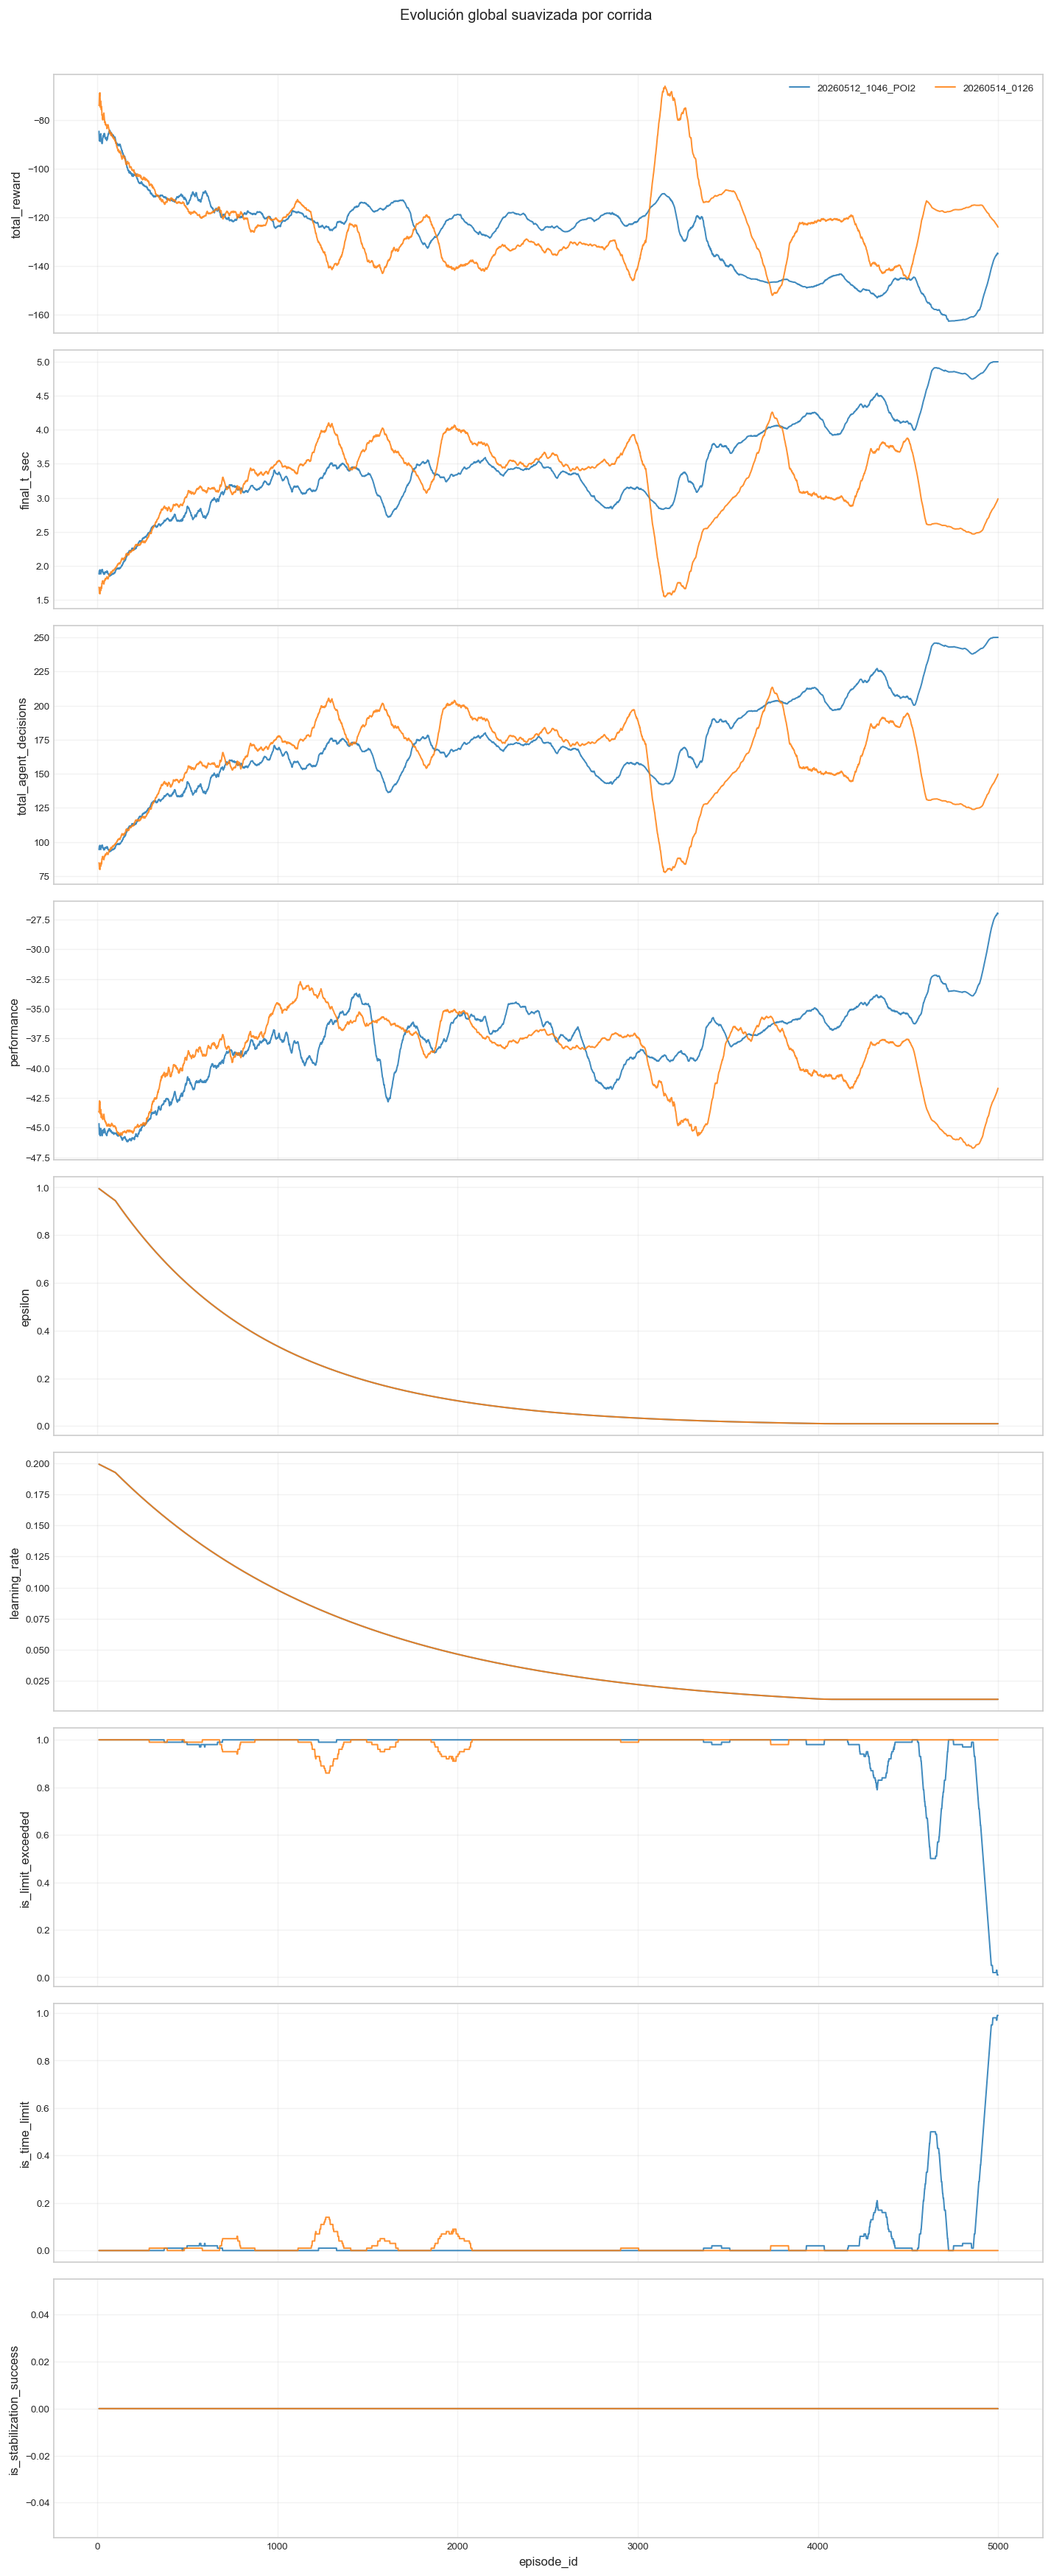

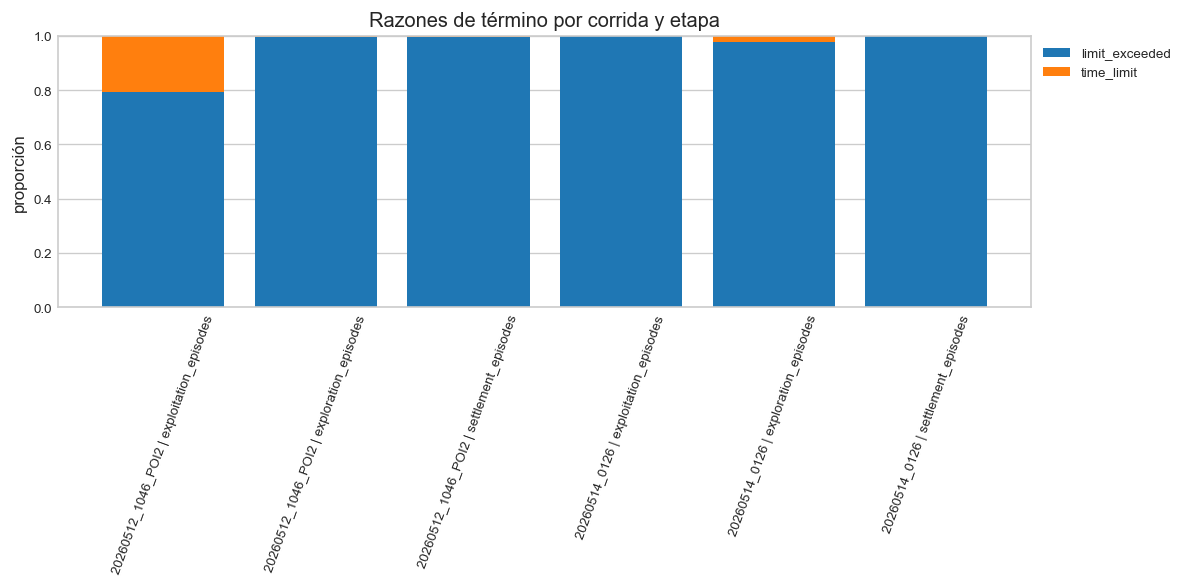

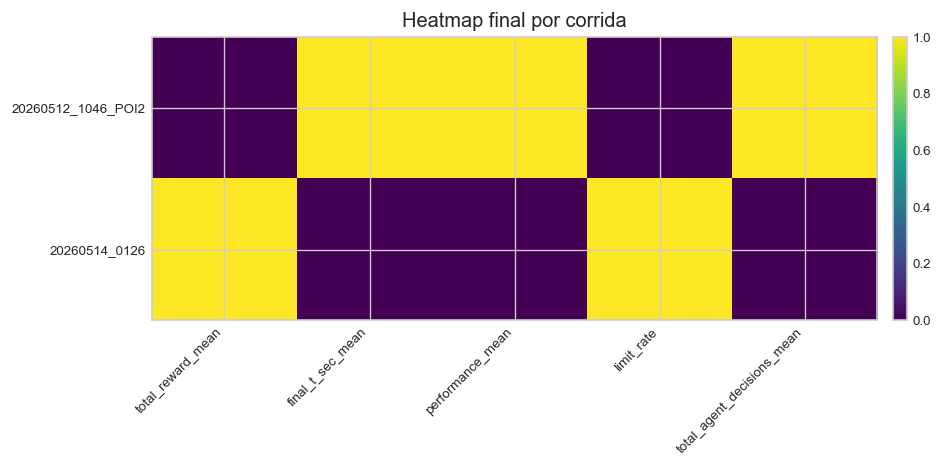

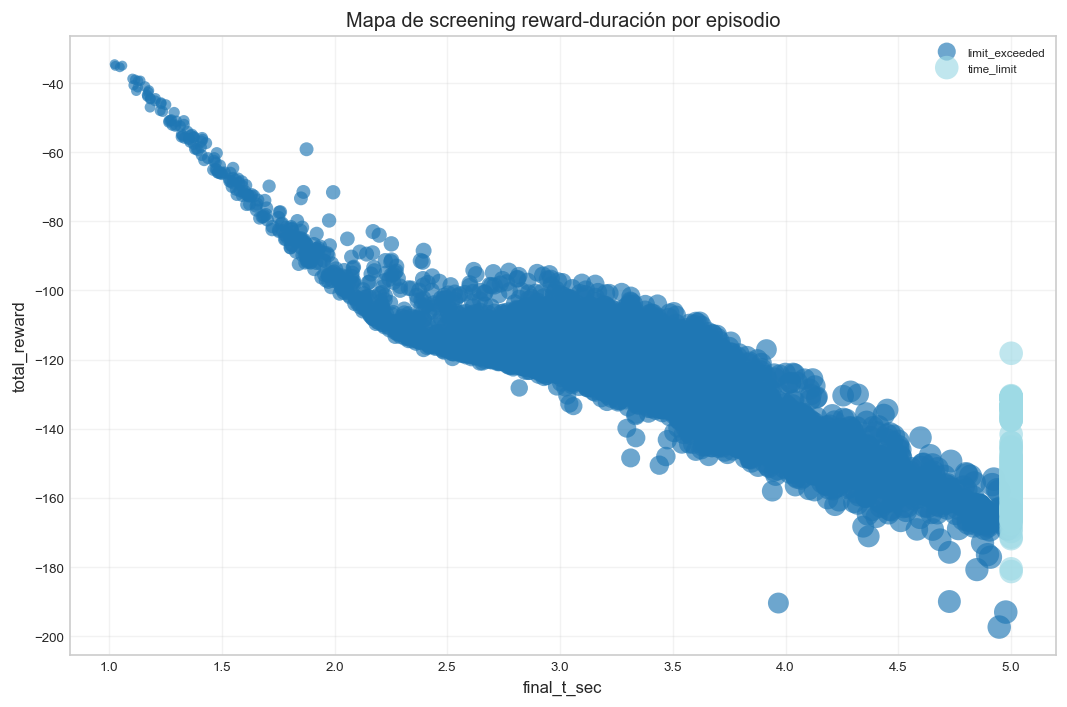

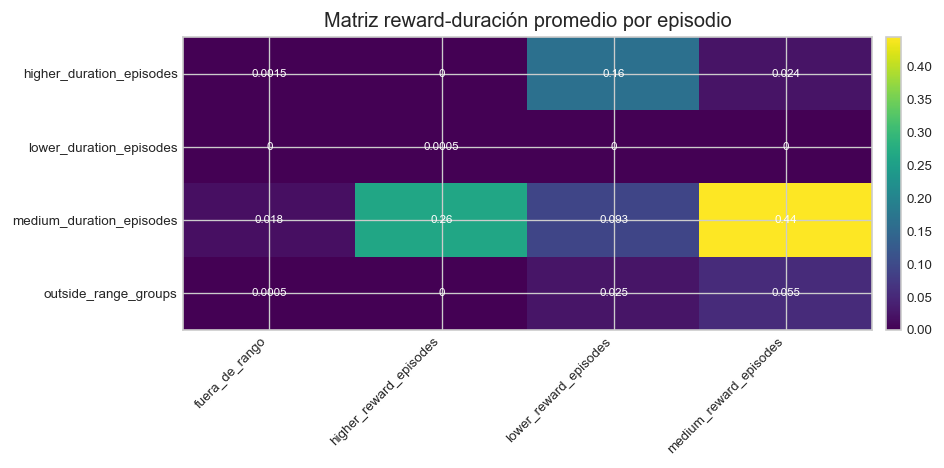

In [10]:
# 1. Graficar evolución suavizada
# 2. Graficar razones de término
# 3. Construir screening reward-duración

fig_global_evolution = plot_lines_by_run(
    analytic_df,
    x_col="episode_id",
    y_cols=GLOBAL_METRICS + GLOBAL_RATE_COLUMNS,
    smoothing_window=GLOBAL_SMOOTHING_WINDOW,
    title="Evolución global suavizada por corrida",
)
register_figure("global_training_evolution", fig_global_evolution, FIGURE_REGISTRY)
plt.show()

fig_global_termination = plot_stacked_bars(
    termination_stage_rate_df,
    group_cols=["run_id", "stage"],
    title="Razones de término por corrida y etapa",
)
register_figure("global_termination_stage_rates", fig_global_termination, FIGURE_REGISTRY)
plt.show()

heatmap_cols = [col for col in ["total_reward_mean", "final_t_sec_mean", "performance_mean", "limit_rate", "success_rate", "total_agent_decisions_mean"] if col in global_final_profile_df.columns]
fig_global_final_heatmap = plot_simple_heatmap(
    global_final_profile_df.set_index("run_id")[heatmap_cols] if heatmap_cols else pd.DataFrame(),
    title="Heatmap final por corrida",
    normalize=True,
    value_label=False,
)
register_figure("global_final_heatmap", fig_global_final_heatmap, FIGURE_REGISTRY)
plt.show()

fig_global_scatter = plot_scatter_with_size(
    analytic_df,
    x_col=DURATION_GROUP_SOURCE,
    y_col=REWARD_GROUP_SOURCE,
    color_col=TERMINATION_REASON_COL,
    size_col="total_agent_decisions",
    title="Mapa de screening reward-duración por episodio",
)
register_figure("global_reward_duration_screening", fig_global_scatter, FIGURE_REGISTRY)
plt.show()

matrix_for_plot = reward_duration_matrix_df.pivot_table(
    index="duration_group",
    columns="reward_group",
    values="proportion_within_run_stage",
    aggfunc="mean",
    fill_value=0,
)
fig_reward_duration_matrix = plot_simple_heatmap(
    matrix_for_plot,
    title="Matriz reward-duración promedio por episodio",
    normalize=False,
    value_label=True,
)
register_figure("reward_duration_case_matrix", fig_reward_duration_matrix, FIGURE_REGISTRY)
plt.show()


## 3. Radiografía física

**Propósito:** separar la mejora global de la mejora física real del sistema.
**Pregunta analítica:** ¿la mejora global corresponde a una mejora física real?
**Entradas:** `analytic_df`, `metric_catalog`, `summary_vars_disp_dict`.
**Decisiones locales:** variables físicas candidatas, errores físicos prioritarios y métricas de trade-off.
**Salidas:** `physical_error_summary`, `failure_driver_table`, `domain_tradeoff_map`, `physical_stage_distribution`, `physical_episode_shortlist`.
**Lectura esperada:** identificar si una configuración mejora el equilibrio global o desplaza el problema entre lazos físicos.


In [11]:
# 1. Seleccionar variables físicas disponibles
# 2. Priorizar errores de péndulo y carro
# 3. Exponer opciones auditables

PHYSICAL_COLUMNS = [
    col for col in analytic_df.columns
    if (
        str(col).endswith("_raw")
        or str(col).endswith("_norm")
        or str(col).startswith("final_")
        or str(col).startswith(("error_", "delta_error_", "derivative_error_", "integral_error_"))
    )
    and pd.api.types.is_numeric_dtype(analytic_df[col])
]

PHYSICAL_PRIORITY_CANDIDATES = [
    "error_pendulum_angle_rms_mean",
    "error_pendulum_angle_p75",
    "error_pendulum_angle_p50",
    "error_cart_position_rms_mean",
    "error_cart_position_p75",
    "error_cart_position_p50",
    "final_pendulum_angle_raw",
    "final_pendulum_velocity_raw",
    "final_cart_position_raw",
    "final_cart_velocity_raw",
]
PHYSICAL_SELECTED_COLUMNS = numeric_existing_columns(analytic_df, PHYSICAL_PRIORITY_CANDIDATES)
if not PHYSICAL_SELECTED_COLUMNS:
    PHYSICAL_SELECTED_COLUMNS = PHYSICAL_COLUMNS[:12]

PENDULUM_ERROR_COL = first_existing_column(analytic_df, ["error_pendulum_angle_rms_mean", "error_pendulum_angle_p75", "error_pendulum_angle_p50", "error_pendulum_angle_mean"])
CART_ERROR_COL = first_existing_column(analytic_df, ["error_cart_position_rms_mean", "error_cart_position_p75", "error_cart_position_p50", "error_cart_position_mean"])

physical_options_df = metric_catalog[metric_catalog["column"].isin(PHYSICAL_COLUMNS)]
display(physical_options_df[["family", "base_metric", "statistic", "column"]].head(160))
display(pd.DataFrame({"selected_physical_columns": PHYSICAL_SELECTED_COLUMNS}))


,family,base_metric,statistic,column
170,control,final_kd_cart_position,value,final_kd_cart_position
171,control,final_kd_pendulum_angle,value,final_kd_pendulum_angle
172,control,final_ki_cart_position,value,final_ki_cart_position
173,control,final_ki_pendulum_angle,value,final_ki_pendulum_angle
174,control,final_kp_cart_position,value,final_kp_cart_position
...,...,...,...,...
330,fisica,final_cart_position_raw,value,final_cart_position_raw
331,fisica,final_cart_velocity_raw,value,final_cart_velocity_raw
332,fisica,final_pendulum_angle_raw,value,final_pendulum_angle_raw
333,fisica,final_pendulum_velocity_raw,value,final_pendulum_velocity_raw


,selected_physical_columns
0,error_pendulum_angle_rms_mean
1,error_pendulum_angle_p75
2,error_pendulum_angle_p50
3,error_cart_position_rms_mean
4,error_cart_position_p75
5,error_cart_position_p50
6,final_pendulum_angle_raw
7,final_pendulum_velocity_raw
8,final_cart_position_raw
9,final_cart_velocity_raw


In [12]:
# 1. Resumir errores físicos por corrida y etapa
# 2. Estimar drivers de fallo por razón de término
# 3. Construir shortlist física para auditoría fina

physical_error_summary = summarize_by_run_stage(analytic_df, PHYSICAL_SELECTED_COLUMNS)
physical_stage_distribution = aggregate_numeric(analytic_df, ["stage"], PHYSICAL_SELECTED_COLUMNS)

failure_driver_metrics = numeric_existing_columns(analytic_df, [PENDULUM_ERROR_COL, CART_ERROR_COL, DURATION_GROUP_SOURCE, REWARD_GROUP_SOURCE])
failure_driver_table = aggregate_numeric(analytic_df, [TERMINATION_REASON_COL], failure_driver_metrics) if TERMINATION_REASON_COL is not None else pd.DataFrame()

domain_tradeoff_columns = ["run_id", "episode_id", "stage", TERMINATION_REASON_COL, REWARD_GROUP_SOURCE, DURATION_GROUP_SOURCE, PENDULUM_ERROR_COL, CART_ERROR_COL]
domain_tradeoff_columns = [col for col in domain_tradeoff_columns if col is not None and col in analytic_df.columns]
domain_tradeoff_map = analytic_df[domain_tradeoff_columns].copy()

physical_episode_shortlist = select_episode_shortlist(
    analytic_df,
    numeric_existing_columns(analytic_df, [PENDULUM_ERROR_COL, CART_ERROR_COL, REWARD_GROUP_SOURCE, DURATION_GROUP_SOURCE]),
    top_n=40,
    required_columns=[TERMINATION_REASON_COL, "reward_group", "duration_group"],
)

register_table("physical_error_summary", physical_error_summary, TABLE_REGISTRY)
register_table("failure_driver_table", failure_driver_table, TABLE_REGISTRY)
register_table("domain_tradeoff_map", domain_tradeoff_map, TABLE_REGISTRY)
register_table("physical_stage_distribution", physical_stage_distribution, TABLE_REGISTRY)
register_table("physical_episode_shortlist", physical_episode_shortlist, TABLE_REGISTRY)

display(physical_error_summary.head())
display(failure_driver_table.head())
display(physical_episode_shortlist.head(20))


,run_id,stage,error_pendulum_angle_rms_mean_mean,error_pendulum_angle_rms_mean_median,error_pendulum_angle_rms_mean_std,error_pendulum_angle_rms_mean_min,error_pendulum_angle_rms_mean_max,error_pendulum_angle_rms_mean_count,error_pendulum_angle_p75_mean,error_pendulum_angle_p75_median,...,final_cart_position_raw_std,final_cart_position_raw_min,final_cart_position_raw_max,final_cart_position_raw_count,final_cart_velocity_raw_mean,final_cart_velocity_raw_median,final_cart_velocity_raw_std,final_cart_velocity_raw_min,final_cart_velocity_raw_max,final_cart_velocity_raw_count
0,20260512_1046_POI2,exploitation_episodes,0.090724,0.088347,0.022437,0.036871,0.152129,1000,0.122551,0.124201,...,0.724574,2.107348,5.004559,1000,3.312342,3.408031,0.875615,0.646523,5.198050,1000
1,20260512_1046_POI2,exploration_episodes,0.162620,0.140271,0.085278,0.042432,0.441050,2000,0.206870,0.153437,...,0.672230,0.691780,5.006763,2000,3.858683,3.591139,1.217486,-0.237692,7.399258,2000
2,20260512_1046_POI2,settlement_episodes,0.122143,0.111466,0.043942,0.054487,0.453910,2000,0.161945,0.149797,...,0.169373,1.694773,5.006239,2000,3.736457,3.608602,0.834767,1.745026,7.700642,2000
3,20260514_0126,exploitation_episodes,0.182983,0.194862,0.060793,0.072175,0.349374,1000,0.242702,0.244192,...,0.340392,2.849119,5.006131,1000,4.722539,4.919230,0.902201,2.486902,6.626026,1000
4,20260514_0126,exploration_episodes,0.144032,0.110302,0.083091,0.033562,0.439839,2000,0.188003,0.149686,...,0.696025,0.351018,5.006259,2000,3.658491,3.447827,1.172533,0.217019,7.717862,2000


,end_termination_reason,error_pendulum_angle_rms_mean_mean,error_pendulum_angle_rms_mean_median,error_pendulum_angle_rms_mean_std,error_pendulum_angle_rms_mean_min,error_pendulum_angle_rms_mean_max,error_pendulum_angle_rms_mean_count,error_cart_position_rms_mean_mean,error_cart_position_rms_mean_median,error_cart_position_rms_mean_std,...,final_t_sec_std,final_t_sec_min,final_t_sec_max,final_t_sec_count,total_reward_mean,total_reward_median,total_reward_std,total_reward_min,total_reward_max,total_reward_count
0,limit_exceeded,0.145771,0.117368,0.075555,0.040336,0.453910,9738,0.334534,0.340218,0.058246,...,0.723765,0.971,5.0,9738,-125.056766,-122.688039,19.823523,-197.376884,-30.645939,9738
1,time_limit,0.061970,0.059086,0.015944,0.033562,0.163259,262,0.261523,0.258903,0.053359,...,0.000000,5.000,5.0,262,-147.897385,-148.679692,13.922547,-220.897252,-118.165406,262


,run_id,episode_id,stage,severity_score,reason_for_selection,end_termination_reason,reward_group,duration_group,error_pendulum_angle_rms_mean,error_cart_position_rms_mean,total_reward,final_t_sec
0,20260514_0126,3197,settlement_episodes,16.292324,error_pendulum_angle_rms_mean; error_cart_posi...,limit_exceeded,higher_reward_episodes,lower_duration_episodes,0.380697,0.018613,-30.645939,0.971
1,20260514_0126,3224,settlement_episodes,16.204110,error_pendulum_angle_rms_mean; error_cart_posi...,limit_exceeded,higher_reward_episodes,medium_duration_episodes,0.406304,0.026490,-35.022060,1.028
2,20260514_0126,3113,settlement_episodes,16.026396,error_pendulum_angle_rms_mean; error_cart_posi...,limit_exceeded,higher_reward_episodes,medium_duration_episodes,0.388580,0.026237,-34.167101,1.021
3,20260514_0126,3226,settlement_episodes,15.954878,error_pendulum_angle_rms_mean; error_cart_posi...,limit_exceeded,higher_reward_episodes,medium_duration_episodes,0.384462,0.027074,-33.939962,1.032
4,20260514_0126,3130,settlement_episodes,15.876059,error_pendulum_angle_rms_mean; error_cart_posi...,limit_exceeded,higher_reward_episodes,medium_duration_episodes,0.381132,0.027944,-34.528217,1.025
5,20260514_0126,3199,settlement_episodes,15.870242,error_pendulum_angle_rms_mean; error_cart_posi...,limit_exceeded,higher_reward_episodes,medium_duration_episodes,0.388103,0.029318,-35.419242,1.048
6,20260512_1046_POI2,54,exploration_episodes,15.776758,error_pendulum_angle_rms_mean; error_cart_posi...,limit_exceeded,higher_reward_episodes,medium_duration_episodes,0.421620,0.040916,-40.628549,1.109
7,20260514_0126,36,exploration_episodes,15.772959,error_pendulum_angle_rms_mean; error_cart_posi...,limit_exceeded,higher_reward_episodes,medium_duration_episodes,0.363858,0.026179,-32.624827,1.025
8,20260514_0126,3198,settlement_episodes,15.600556,error_pendulum_angle_rms_mean; error_cart_posi...,limit_exceeded,higher_reward_episodes,medium_duration_episodes,0.368069,0.030125,-34.965199,1.059
9,20260514_0126,3111,settlement_episodes,15.559194,error_pendulum_angle_rms_mean; error_cart_posi...,limit_exceeded,higher_reward_episodes,medium_duration_episodes,0.374259,0.032569,-36.104714,1.078


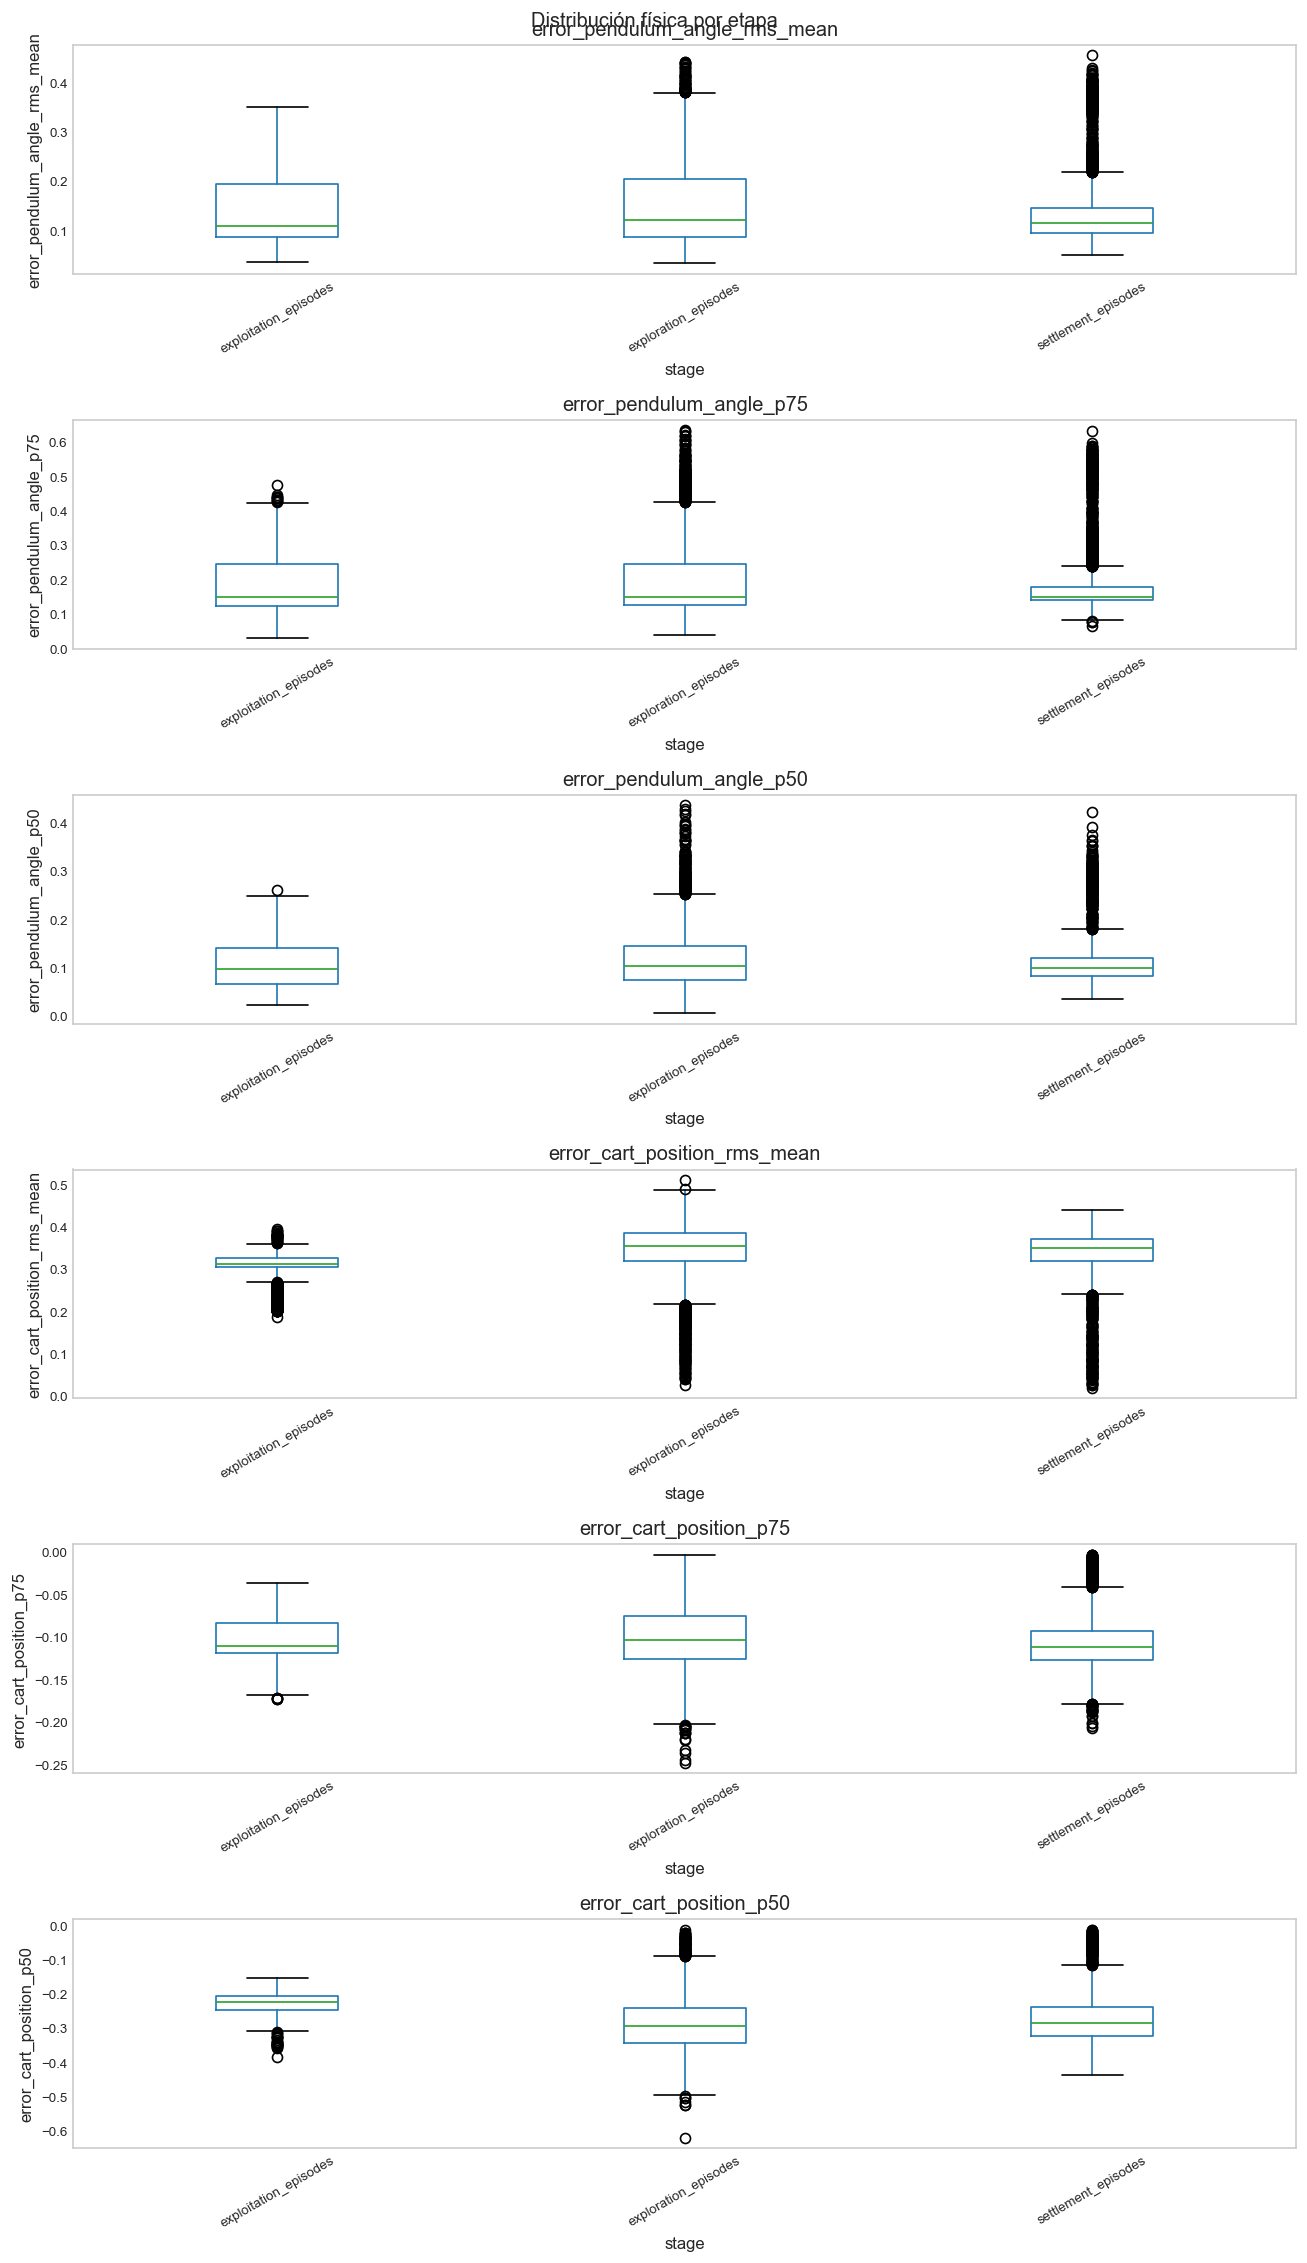

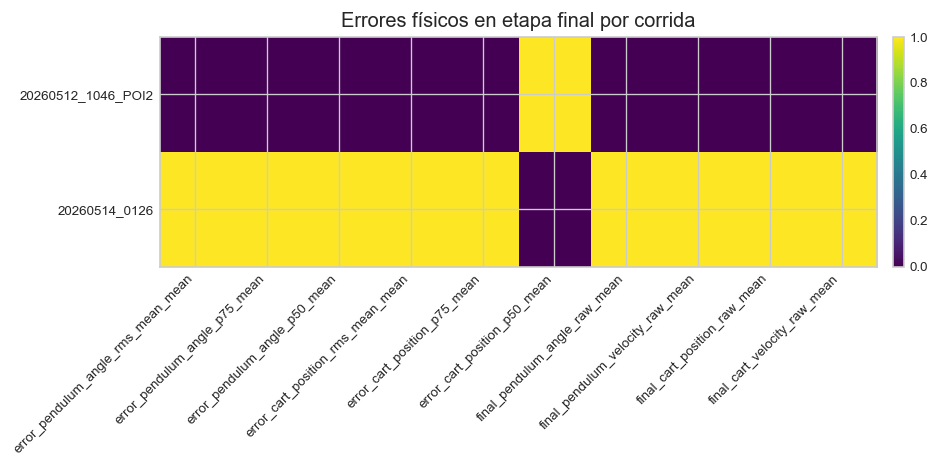

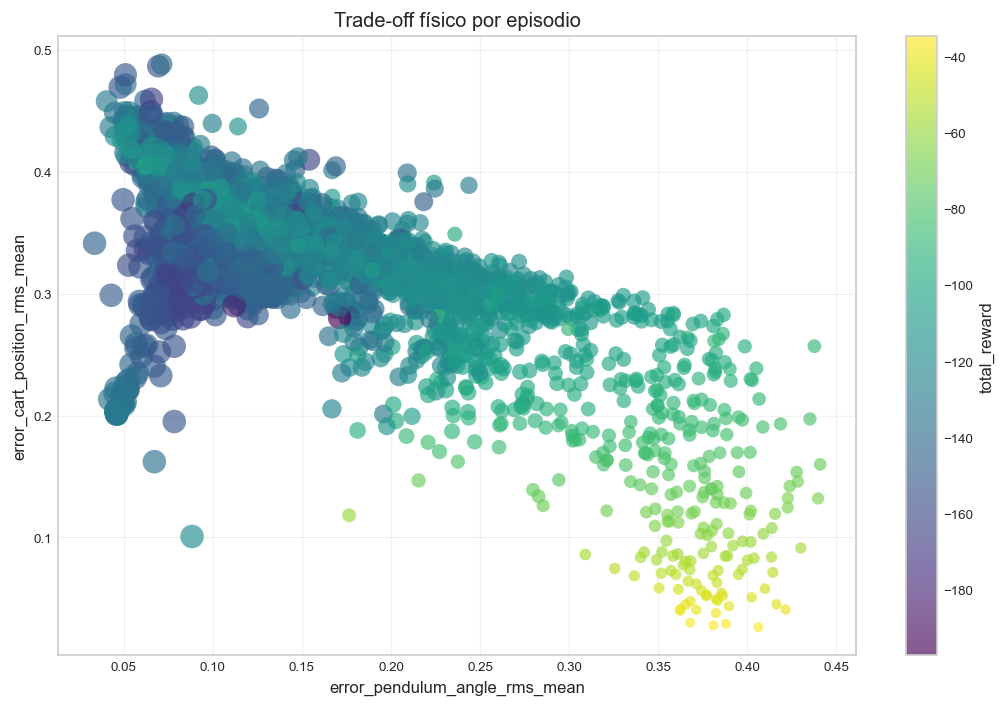

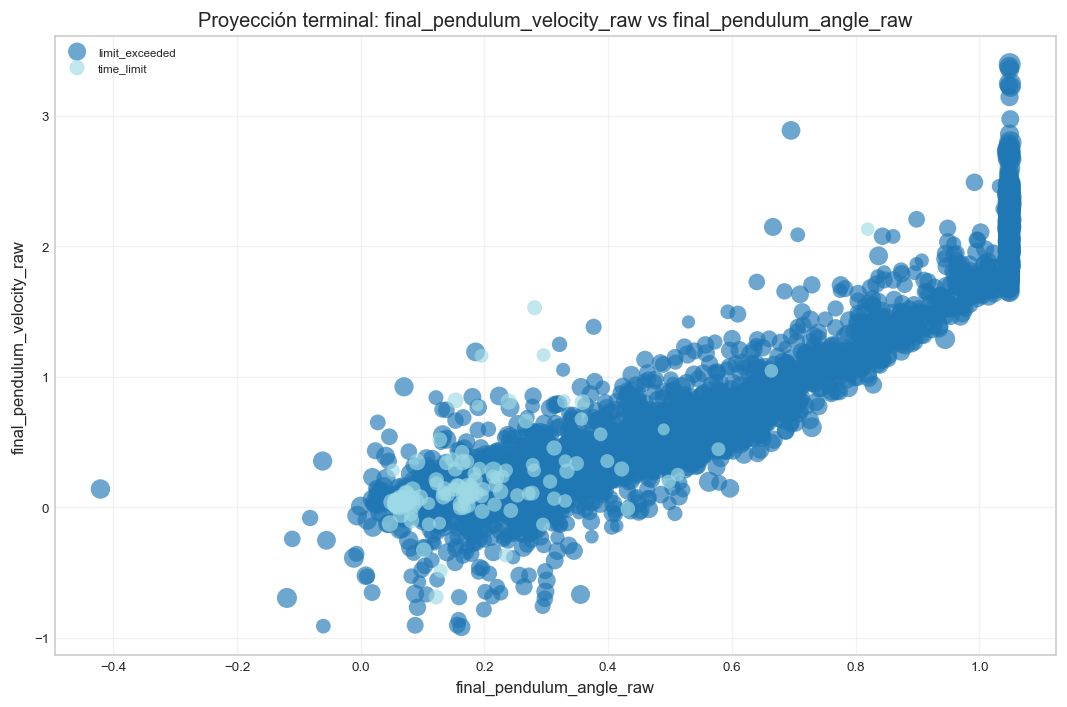

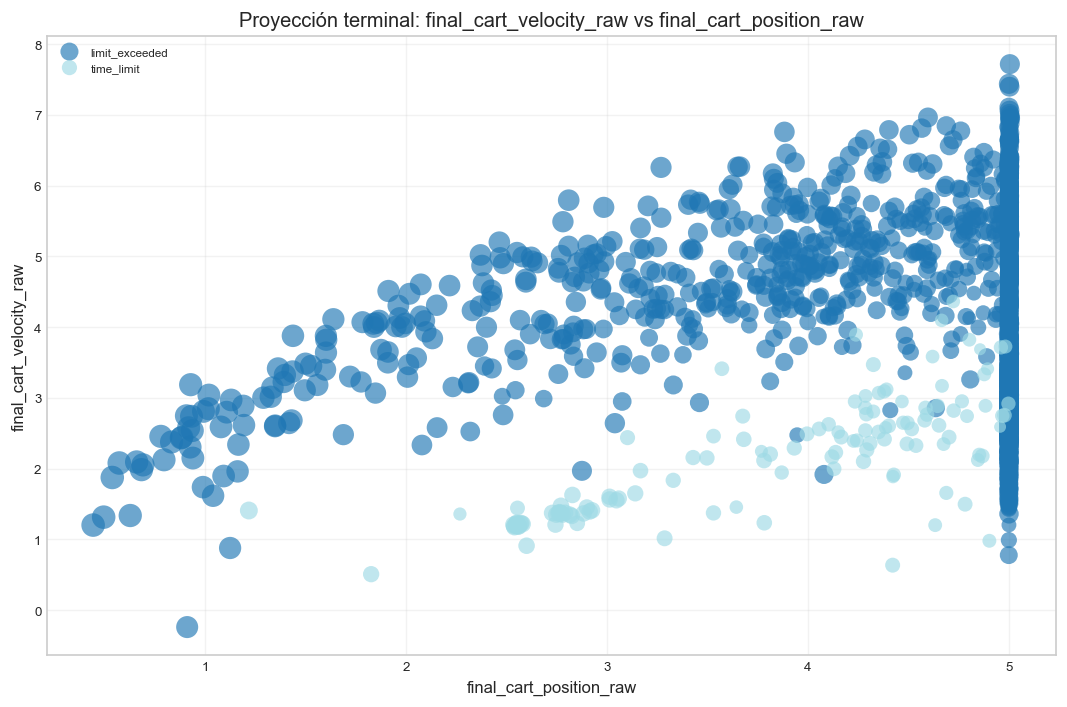

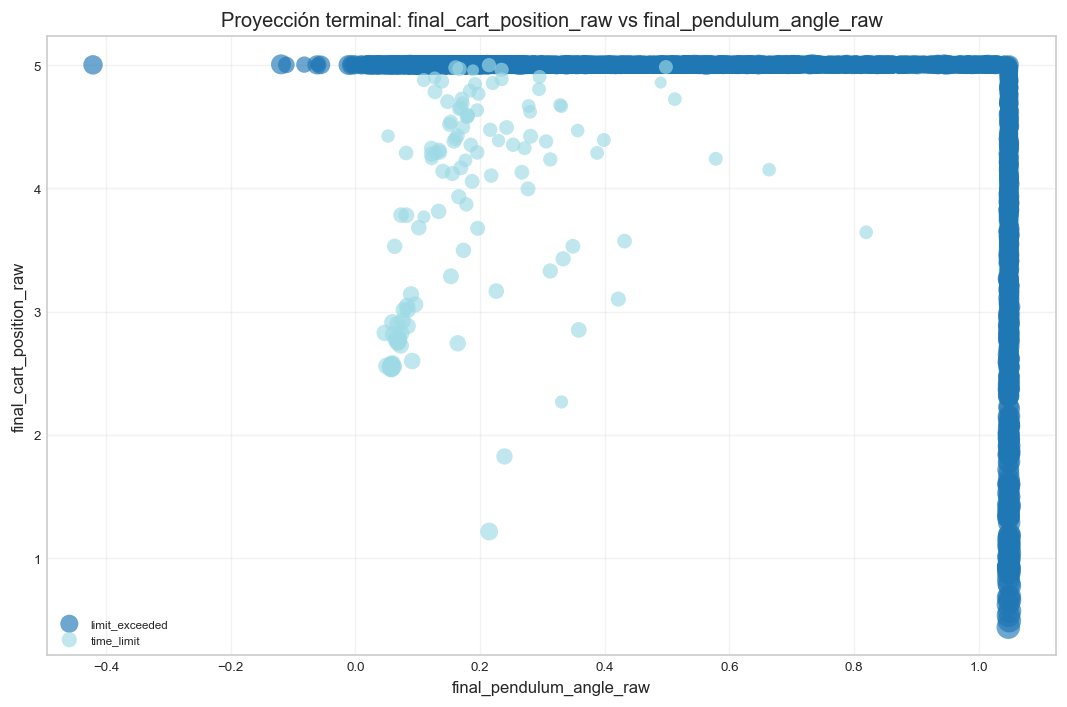

In [14]:
# 1. Distribución física por etapa
# 2. Trade-off péndulo-carro
# 3. Proyección terminal de estado

fig_physical_boxplot = plot_stage_boxplot(
    analytic_df,
    PHYSICAL_SELECTED_COLUMNS[:6],
    stage_col="stage",
    title="Distribución física por etapa",
)
register_figure("physical_stage_distribution", fig_physical_boxplot, FIGURE_REGISTRY)
plt.show()

final_physical_cols = [f"{col}_mean" for col in PHYSICAL_SELECTED_COLUMNS if f"{col}_mean" in physical_error_summary.columns]
final_physical_heatmap_data = physical_error_summary[physical_error_summary["stage"].eq("exploitation_episodes")]
if final_physical_cols:
    final_physical_heatmap_data = final_physical_heatmap_data.set_index("run_id")[final_physical_cols]
else:
    final_physical_heatmap_data = pd.DataFrame()

fig_physical_heatmap = plot_simple_heatmap(
    final_physical_heatmap_data,
    title="Errores físicos en etapa final por corrida",
    normalize=True,
)
register_figure("physical_final_error_heatmap", fig_physical_heatmap, FIGURE_REGISTRY)
plt.show()

fig_physical_tradeoff = plot_scatter_with_size(
    analytic_df,
    x_col=PENDULUM_ERROR_COL,
    y_col=CART_ERROR_COL,
    color_col=REWARD_GROUP_SOURCE,
    size_col=DURATION_GROUP_SOURCE,
    title="Trade-off físico por episodio",
)
register_figure("physical_domain_tradeoff", fig_physical_tradeoff, FIGURE_REGISTRY)
plt.show()

terminal_pairs = [
    ("final_pendulum_angle_raw", "final_pendulum_velocity_raw"),
    ("final_cart_position_raw", "final_cart_velocity_raw"),
    ("final_pendulum_angle_raw", "final_cart_position_raw")
]
for x_col, y_col in terminal_pairs:
    if x_col in analytic_df.columns and y_col in analytic_df.columns:
        fig_terminal = plot_scatter_with_size(
            analytic_df,
            x_col=x_col,
            y_col=y_col,
            color_col=TERMINATION_REASON_COL,
            size_col=REWARD_GROUP_SOURCE,
            title=f"Proyección terminal: {y_col} vs {x_col}",
        )
        register_figure(f"terminal_projection_{x_col}_vs_{y_col}", fig_terminal, FIGURE_REGISTRY)
        plt.show()


## 4. Auditoría de control y esfuerzo

**Propósito:** evaluar si la mejora física se obtiene con control razonable o mediante esfuerzo agresivo.
**Pregunta analítica:** ¿la mejora fue obtenida con control razonable o comprada con esfuerzo agresivo?
**Entradas:** `analytic_df`, variables de control, errores físicos prioritarios y razones de término.
**Decisiones locales:** patrones de control, métricas de ganancia, esfuerzo, saturación, asignación y conflicto.
**Salidas:** `control_effort_summary`, `gain_stability_table`, `saturation_profile`, `effort_vs_error_table`, `controller_tradeoff_summary`.
**Lectura esperada:** distinguir mejora estable de mejora sostenida por saturación o compensación agresiva entre lazos.


In [15]:
# 1. Seleccionar señales de control disponibles
# 2. Separar ganancias, esfuerzo, saturación y conflicto
# 3. Exponer variables candidatas

CONTROL_PATTERNS = [
    "kp_",
    "ki_",
    "kd_",
    "u_total",
    "u_total_raw",
    "u_total_saturated",
    "u_eff_",
    "u_alloc_",
    "u_conflict_",
    "control_action_",
    "delta_control_action_",
    "delta_u_",
    "saturation_proportion_",
    "is_saturated",
]

CONTROL_COLUMNS = select_columns_by_patterns(analytic_df.columns, CONTROL_PATTERNS, require_numeric_df=analytic_df)
GAIN_COLUMNS = select_columns_by_patterns(CONTROL_COLUMNS, ["final_kp", "final_ki", "final_kd", "kp_", "ki_", "kd_"])
EFFORT_COLUMNS = select_columns_by_patterns(CONTROL_COLUMNS, ["u_total", "u_eff_", "control_action_"])
SATURATION_COLUMNS = select_columns_by_patterns(CONTROL_COLUMNS, ["saturation", "is_saturated"])
CONFLICT_COLUMNS = select_columns_by_patterns(CONTROL_COLUMNS, ["u_alloc_", "u_conflict_", "delta_u_alloc_", "delta_u_conflict_"])

CONTROL_SELECTED_COLUMNS = list(dict.fromkeys(GAIN_COLUMNS[:8] + EFFORT_COLUMNS[:8] + SATURATION_COLUMNS[:8] + CONFLICT_COLUMNS[:8]))

display(metric_catalog[metric_catalog["column"].isin(CONTROL_COLUMNS)][["family", "base_metric", "statistic", "column"]].head(180))
display(pd.DataFrame({
    "group": ["gain", "effort", "saturation", "conflict"],
    "n_columns": [len(GAIN_COLUMNS), len(EFFORT_COLUMNS), len(SATURATION_COLUMNS), len(CONFLICT_COLUMNS)],
}))


,family,base_metric,statistic,column
2,aprendizaje,q_value_kd_cart_position,max,q_value_kd_cart_position_max
3,aprendizaje,q_value_kd_cart_position,mean,q_value_kd_cart_position_mean
4,aprendizaje,q_value_kd_cart_position,min,q_value_kd_cart_position_min
5,aprendizaje,q_value_kd_cart_position,p25,q_value_kd_cart_position_p25
6,aprendizaje,q_value_kd_cart_position,p50,q_value_kd_cart_position_p50
...,...,...,...,...
177,control,saturation_proportion_cart_position,mean,saturation_proportion_cart_position_mean
178,control,saturation_proportion_cart_position,min,saturation_proportion_cart_position_min
179,control,saturation_proportion_cart_position,p25,saturation_proportion_cart_position_p25
180,control,saturation_proportion_cart_position,p50,saturation_proportion_cart_position_p50


,group,n_columns
0,gain,132
1,effort,77
2,saturation,14
3,conflict,56


In [16]:
# 1. Resumir esfuerzo y ganancias
# 2. Construir perfil de saturación
# 3. Relacionar error físico y esfuerzo

control_effort_summary = summarize_by_run_stage(analytic_df, CONTROL_SELECTED_COLUMNS)
gain_stability_table = summarize_final_window(analytic_df, GAIN_COLUMNS[:18], FINAL_WINDOW_EPISODES, FINAL_WINDOW_FRACTION)
saturation_profile = summarize_by_run_stage(analytic_df, SATURATION_COLUMNS[:20])

EFFORT_PRIMARY_COL = first_existing_column(analytic_df, EFFORT_COLUMNS)
ERROR_PRIMARY_COL = first_existing_column(analytic_df, [PENDULUM_ERROR_COL, CART_ERROR_COL])

effort_vs_error_columns = ["run_id", "episode_id", "stage", REWARD_GROUP_SOURCE, DURATION_GROUP_SOURCE, ERROR_PRIMARY_COL, EFFORT_PRIMARY_COL]
effort_vs_error_columns = [col for col in effort_vs_error_columns if col is not None and col in analytic_df.columns]
effort_vs_error_table = analytic_df[effort_vs_error_columns].copy()

controller_tradeoff_summary = correlation_table(
    analytic_df,
    x_cols=[ERROR_PRIMARY_COL] if ERROR_PRIMARY_COL else [],
    y_cols=EFFORT_COLUMNS[:12] + SATURATION_COLUMNS[:12],
    group_cols=["run_id"],
)

register_table("control_effort_summary", control_effort_summary, TABLE_REGISTRY)
register_table("gain_stability_table", gain_stability_table, TABLE_REGISTRY)
register_table("saturation_profile", saturation_profile, TABLE_REGISTRY)
register_table("effort_vs_error_table", effort_vs_error_table, TABLE_REGISTRY)
register_table("controller_tradeoff_summary", controller_tradeoff_summary, TABLE_REGISTRY)

display(control_effort_summary.head())
display(gain_stability_table.head())
display(controller_tradeoff_summary.sort_values("correlation", key=lambda s: s.abs(), ascending=False).head(20))


,run_id,stage,final_kp_pendulum_angle_mean,final_kp_pendulum_angle_median,final_kp_pendulum_angle_std,final_kp_pendulum_angle_min,final_kp_pendulum_angle_max,final_kp_pendulum_angle_count,final_ki_pendulum_angle_mean,final_ki_pendulum_angle_median,...,u_alloc_pendulum_angle_max_std,u_alloc_pendulum_angle_max_min,u_alloc_pendulum_angle_max_max,u_alloc_pendulum_angle_max_count,delta_u_alloc_pendulum_angle_mean_mean,delta_u_alloc_pendulum_angle_mean_median,delta_u_alloc_pendulum_angle_mean_std,delta_u_alloc_pendulum_angle_mean_min,delta_u_alloc_pendulum_angle_mean_max,delta_u_alloc_pendulum_angle_mean_count
0,20260512_1046_POI2,exploitation_episodes,6.59325,6.50,0.259681,6.00,7.5,1000,8.630500,9.75,...,0.160938,0.476537,1.0,1000,0.000091,0.000086,0.000070,-1.537705e-19,0.000266,1000
1,20260512_1046_POI2,exploration_episodes,5.74200,5.50,1.846047,0.00,10.0,2000,6.069875,6.25,...,0.130991,0.473821,1.0,2000,0.000217,0.000191,0.000163,-1.034765e-19,0.000901,2000
2,20260512_1046_POI2,settlement_episodes,6.44800,6.00,1.399898,2.25,10.0,2000,5.634625,5.75,...,0.160622,0.325556,1.0,2000,0.000146,0.000127,0.000108,-2.819759e-19,0.000750,2000
3,20260514_0126,exploitation_episodes,5.58475,4.75,2.078238,0.00,10.0,1000,6.643000,7.50,...,0.147155,0.384397,1.0,1000,0.000255,0.000288,0.000125,-1.123992e-19,0.000497,1000
4,20260514_0126,exploration_episodes,5.34800,5.00,1.828662,0.00,10.0,2000,6.282000,6.25,...,0.130393,0.406625,1.0,2000,0.000183,0.000147,0.000161,-1.366821e-19,0.000865,2000


,run_id,final_kp_pendulum_angle_mean,final_kp_pendulum_angle_median,final_kp_pendulum_angle_std,final_kp_pendulum_angle_min,final_kp_pendulum_angle_max,final_kp_pendulum_angle_count,final_ki_pendulum_angle_mean,final_ki_pendulum_angle_median,final_ki_pendulum_angle_std,...,reward_ki_pendulum_angle_p25_std,reward_ki_pendulum_angle_p25_min,reward_ki_pendulum_angle_p25_max,reward_ki_pendulum_angle_p25_count,reward_ki_pendulum_angle_p50_mean,reward_ki_pendulum_angle_p50_median,reward_ki_pendulum_angle_p50_std,reward_ki_pendulum_angle_p50_min,reward_ki_pendulum_angle_p50_max,reward_ki_pendulum_angle_p50_count
0,20260512_1046_POI2,6.4065,6.5,0.161042,6.0,7.0,500,9.7045,10.0,0.856605,...,0.097090,-0.458681,-0.046211,500,-0.111322,-0.125439,0.043914,-0.269554,-0.017001,500
1,20260514_0126,6.1090,5.5,2.661821,0.0,10.0,500,6.9310,7.0,2.161442,...,0.044083,-0.645620,-0.391234,500,-0.397279,-0.390819,0.056670,-0.598539,-0.203583,500


,run_id,x,y,n_pairs,correlation,method
25,20260514_0126,error_pendulum_angle_rms_mean,control_action_pendulum_angle_std,5000,0.759679,spearman
0,20260512_1046_POI2,error_pendulum_angle_rms_mean,control_action_pendulum_angle_mean,5000,0.740368,spearman
30,20260514_0126,error_pendulum_angle_rms_mean,control_action_pendulum_angle_max,5000,0.727598,spearman
5,20260512_1046_POI2,error_pendulum_angle_rms_mean,control_action_pendulum_angle_p75,5000,0.710901,spearman
7,20260512_1046_POI2,error_pendulum_angle_rms_mean,u_eff_pendulum_angle_mean,5000,0.707467,spearman
1,20260512_1046_POI2,error_pendulum_angle_rms_mean,control_action_pendulum_angle_std,5000,0.705868,spearman
24,20260514_0126,error_pendulum_angle_rms_mean,control_action_pendulum_angle_mean,5000,0.705161,spearman
32,20260514_0126,error_pendulum_angle_rms_mean,u_eff_pendulum_angle_std,5000,0.700958,spearman
29,20260514_0126,error_pendulum_angle_rms_mean,control_action_pendulum_angle_p75,5000,0.695835,spearman
6,20260512_1046_POI2,error_pendulum_angle_rms_mean,control_action_pendulum_angle_max,5000,0.689083,spearman


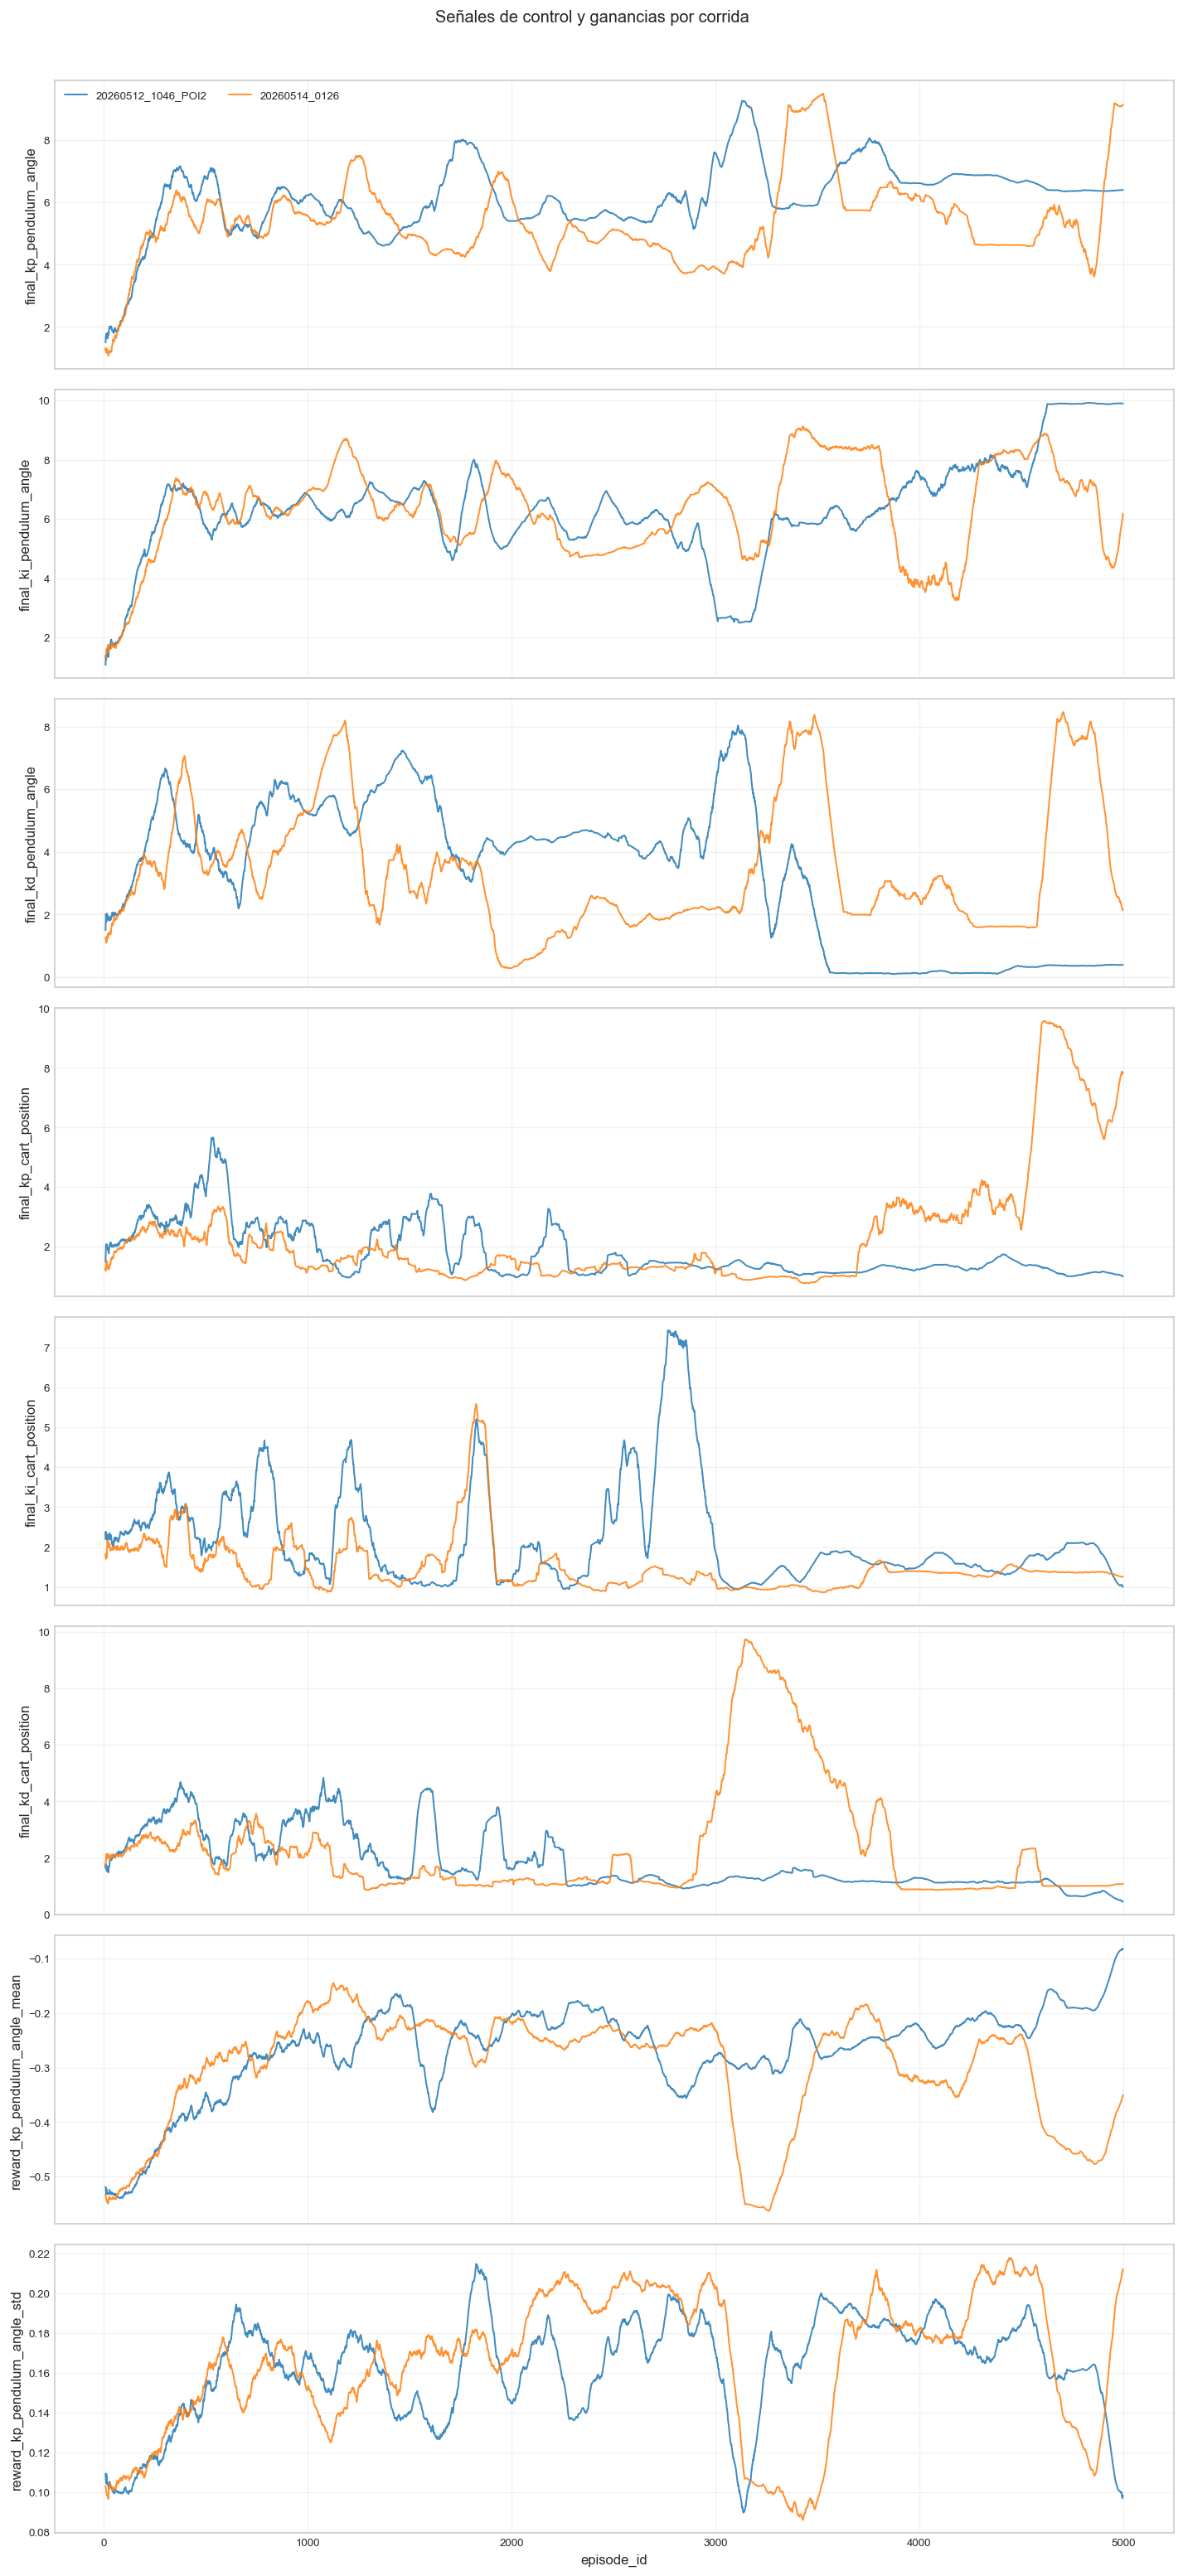

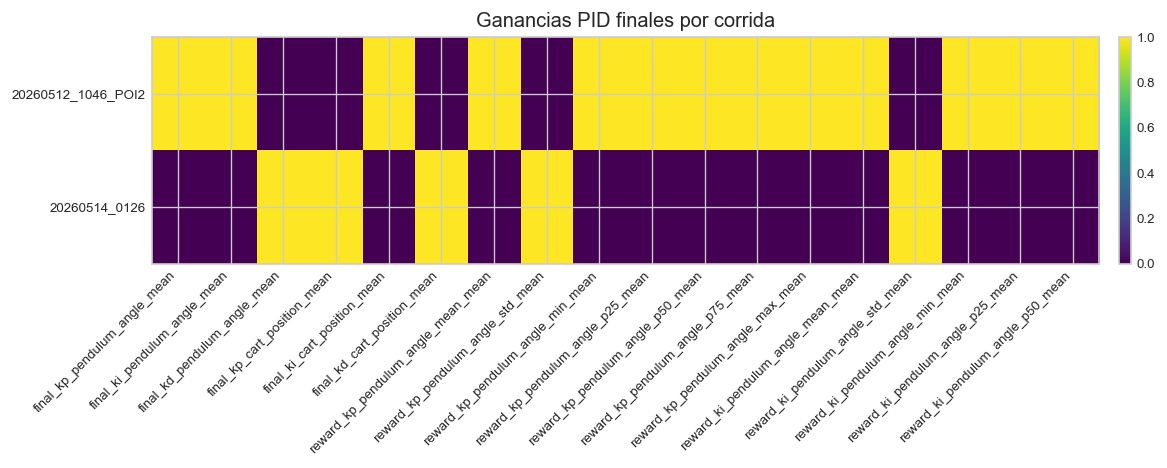

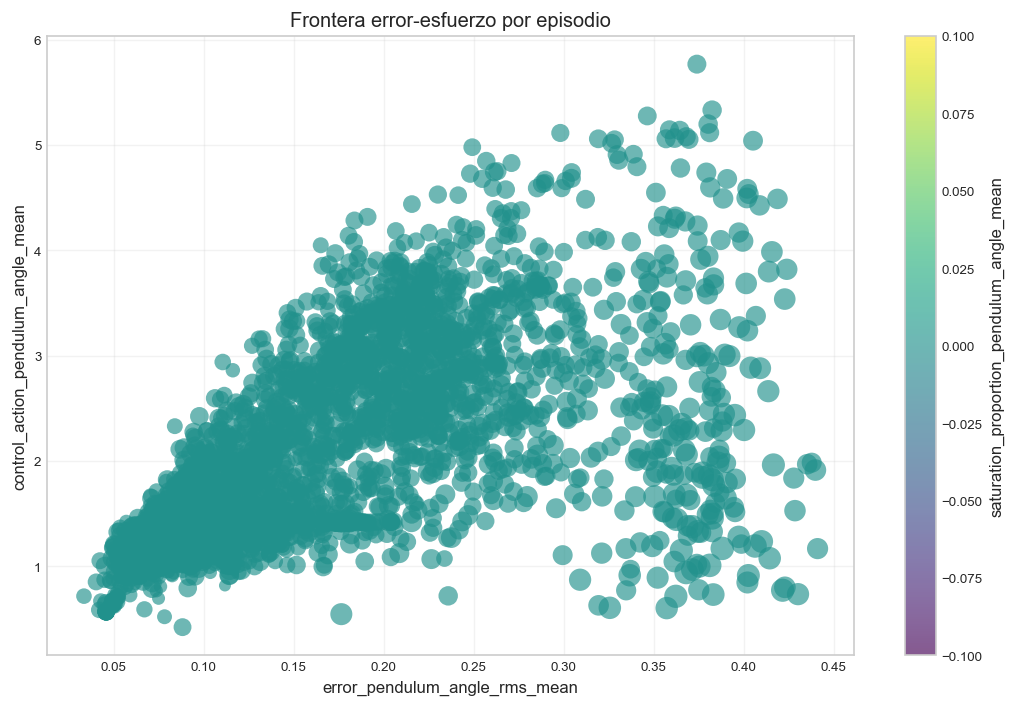

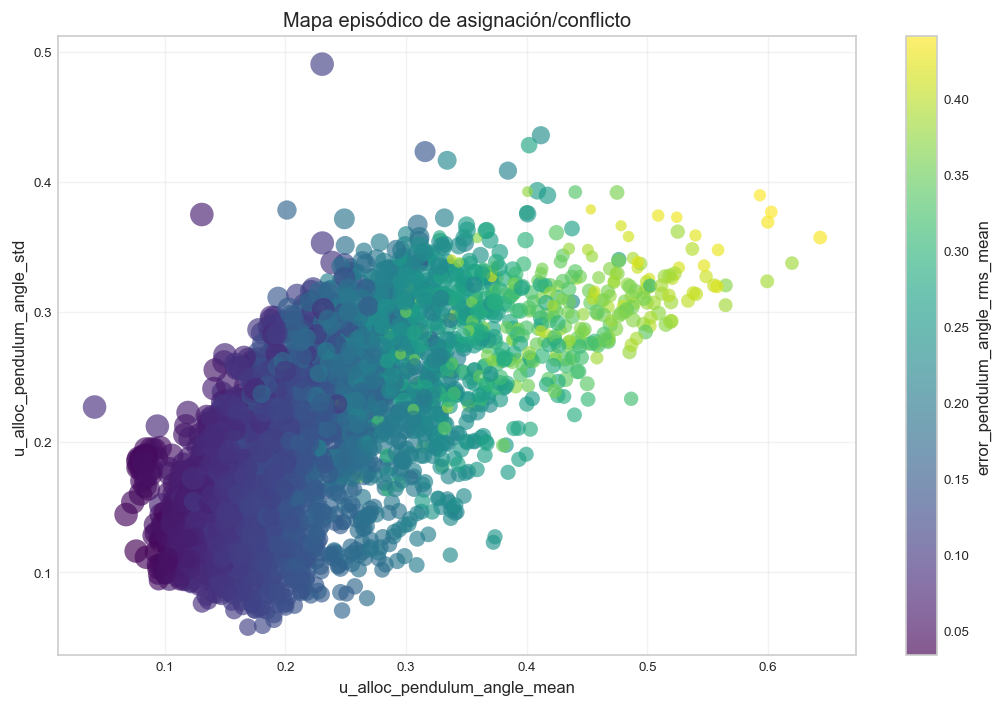

In [17]:
# 1. Trayectorias de ganancias y esfuerzo
# 2. Heatmap final de ganancias PID
# 3. Frontera error-esfuerzo

fig_control_lines = plot_lines_by_run(
    analytic_df,
    x_col="episode_id",
    y_cols=CONTROL_SELECTED_COLUMNS[:8],
    smoothing_window=GLOBAL_SMOOTHING_WINDOW,
    title="Señales de control y ganancias por corrida",
)
register_figure("control_effort_lines", fig_control_lines, FIGURE_REGISTRY)
plt.show()

gain_heatmap_cols = [col for col in gain_stability_table.columns if col.endswith("_mean")]
fig_gain_heatmap = plot_simple_heatmap(
    gain_stability_table.set_index("run_id")[gain_heatmap_cols] if gain_heatmap_cols else pd.DataFrame(),
    title="Ganancias PID finales por corrida",
    normalize=True,
)
register_figure("control_gain_final_heatmap", fig_gain_heatmap, FIGURE_REGISTRY)
plt.show()

fig_effort_error = plot_scatter_with_size(
    analytic_df,
    x_col=ERROR_PRIMARY_COL,
    y_col=EFFORT_PRIMARY_COL,
    color_col=first_existing_column(analytic_df, SATURATION_COLUMNS),
    size_col=REWARD_GROUP_SOURCE,
    title="Frontera error-esfuerzo por episodio",
)
register_figure("control_effort_error_frontier", fig_effort_error, FIGURE_REGISTRY)
plt.show()

if len(CONFLICT_COLUMNS) >= 2:
    fig_conflict = plot_scatter_with_size(
        analytic_df,
        x_col=CONFLICT_COLUMNS[0],
        y_col=CONFLICT_COLUMNS[1],
        color_col=ERROR_PRIMARY_COL,
        size_col=DURATION_GROUP_SOURCE,
        title="Mapa episódico de asignación/conflicto",
    )
    register_figure("control_allocation_conflict_map", fig_conflict, FIGURE_REGISTRY)
    plt.show()


## 5. Auditoría de normalización y rango útil

**Propósito:** evaluar si las transformaciones conservan variabilidad informativa para reward y aprendizaje.
**Pregunta analítica:** ¿las transformaciones permiten que la reward y el aprendizaje vean diferencias útiles?
**Entradas:** `analytic_df`, señales `_norm` y componentes `L_*`.
**Decisiones locales:** patrones de normalización, umbrales de baja variabilidad y saturación de rango.
**Salidas:** `normalization_audit_table`, `range_saturation_flags`, `l_component_distribution_summary`, `range_adjustment_candidates`, `signal_visibility_report`.
**Lectura esperada:** detectar rangos que aplastan la señal o componentes casi constantes que podrían impedir aprendizaje.


In [18]:
# 1. Seleccionar señales normalizadas y Lagrangianas
# 2. Construir auditoría de rango
# 3. Detectar señales invisibles o saturadas

NORMALIZATION_PATTERNS = [
    "_norm",
    "L_e_",
    "L_edot_",
    "L_I_",
    "L_u_",
    "L_delta_u_",
]

NORMALIZATION_COLUMNS = select_columns_by_patterns(analytic_df.columns, NORMALIZATION_PATTERNS, require_numeric_df=analytic_df)
L_COMPONENT_COLUMNS = select_columns_by_patterns(analytic_df.columns, ["L_e_", "L_edot_", "L_I_", "L_u_", "L_delta_u_"], require_numeric_df=analytic_df)

normalization_audit_table = audit_signal_ranges(analytic_df, NORMALIZATION_COLUMNS, group_cols=("run_id",))
range_saturation_flags = normalization_audit_table.query("bound_saturation_flag or low_variability_flag or high_missing_flag").copy()
l_component_distribution_summary = summarize_by_run_stage(analytic_df, L_COMPONENT_COLUMNS[:30])
range_adjustment_candidates = range_saturation_flags.sort_values(["bound_saturation_flag", "low_variability_flag", "missing_rate"], ascending=[False, False, False])

signal_visibility_report = (
    normalization_audit_table.groupby("signal", dropna=False)
    .agg(
        n_runs=("run_id", "nunique"),
        median_std=("std", "median"),
        max_near_lower_rate=("near_lower_rate", "max"),
        max_near_upper_rate=("near_upper_rate", "max"),
        low_variability_runs=("low_variability_flag", "sum"),
        saturated_runs=("bound_saturation_flag", "sum"),
    )
    .reset_index()
    .sort_values(["saturated_runs", "low_variability_runs", "median_std"], ascending=[False, False, True])
)

register_table("normalization_audit_table", normalization_audit_table, TABLE_REGISTRY)
register_table("range_saturation_flags", range_saturation_flags, TABLE_REGISTRY)
register_table("l_component_distribution_summary", l_component_distribution_summary, TABLE_REGISTRY)
register_table("range_adjustment_candidates", range_adjustment_candidates, TABLE_REGISTRY)
register_table("signal_visibility_report", signal_visibility_report, TABLE_REGISTRY)

display(signal_visibility_report.head(40))
display(range_adjustment_candidates.head(40))


,signal,n_runs,median_std,max_near_lower_rate,max_near_upper_rate,low_variability_runs,saturated_runs
30,L_u_cart_position_min,2,0.000000e+00,1.0000,0.0000,2,2
31,L_u_cart_position_p25,2,0.000000e+00,1.0000,0.0000,2,2
112,principal_gate_L_e_cart_position_max,2,0.000000e+00,0.0000,1.0000,2,2
113,principal_gate_L_e_cart_position_mean,2,0.000000e+00,0.0000,1.0000,2,2
114,principal_gate_L_e_cart_position_min,2,0.000000e+00,0.0000,1.0000,2,2
115,principal_gate_L_e_cart_position_p25,2,0.000000e+00,0.0000,1.0000,2,2
116,principal_gate_L_e_cart_position_p50,2,0.000000e+00,0.0000,1.0000,2,2
117,principal_gate_L_e_cart_position_p75,2,0.000000e+00,0.0000,1.0000,2,2
118,principal_gate_L_e_cart_position_std,2,0.000000e+00,1.0000,0.0000,2,2
119,principal_gate_L_e_pendulum_angle_max,2,0.000000e+00,0.0000,1.0000,2,2


,run_id,signal,n,missing_rate,mean,std,min,p01,p50,p99,max,n_unique,expected_lower,expected_upper,near_lower_rate,near_upper_rate,low_variability_flag,bound_saturation_flag,high_missing_flag
65,20260512_1046_POI2,L_u_cart_position_min,5000,0.0,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0,1,0.0,1.0,1.0,0.0000,True,True,False
66,20260512_1046_POI2,L_u_cart_position_p25,5000,0.0,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0,1,0.0,1.0,1.0,0.0000,True,True,False
70,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_mean,5000,0.0,1.000000,0.000000e+00,1.000000,1.000000,1.0,1.0,1.0,1,0.0,1.0,0.0,1.0000,True,True,False
71,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_std,5000,0.0,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0,1,0.0,1.0,1.0,0.0000,True,True,False
72,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_min,5000,0.0,1.000000,0.000000e+00,1.000000,1.000000,1.0,1.0,1.0,1,0.0,1.0,0.0,1.0000,True,True,False
73,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_p25,5000,0.0,1.000000,0.000000e+00,1.000000,1.000000,1.0,1.0,1.0,1,0.0,1.0,0.0,1.0000,True,True,False
74,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_p50,5000,0.0,1.000000,0.000000e+00,1.000000,1.000000,1.0,1.0,1.0,1,0.0,1.0,0.0,1.0000,True,True,False
75,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_p75,5000,0.0,1.000000,0.000000e+00,1.000000,1.000000,1.0,1.0,1.0,1,0.0,1.0,0.0,1.0000,True,True,False
76,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_max,5000,0.0,1.000000,0.000000e+00,1.000000,1.000000,1.0,1.0,1.0,1,0.0,1.0,0.0,1.0000,True,True,False
77,20260512_1046_POI2,principal_gate_L_e_cart_position_mean,5000,0.0,1.000000,0.000000e+00,1.000000,1.000000,1.0,1.0,1.0,1,0.0,1.0,0.0,1.0000,True,True,False


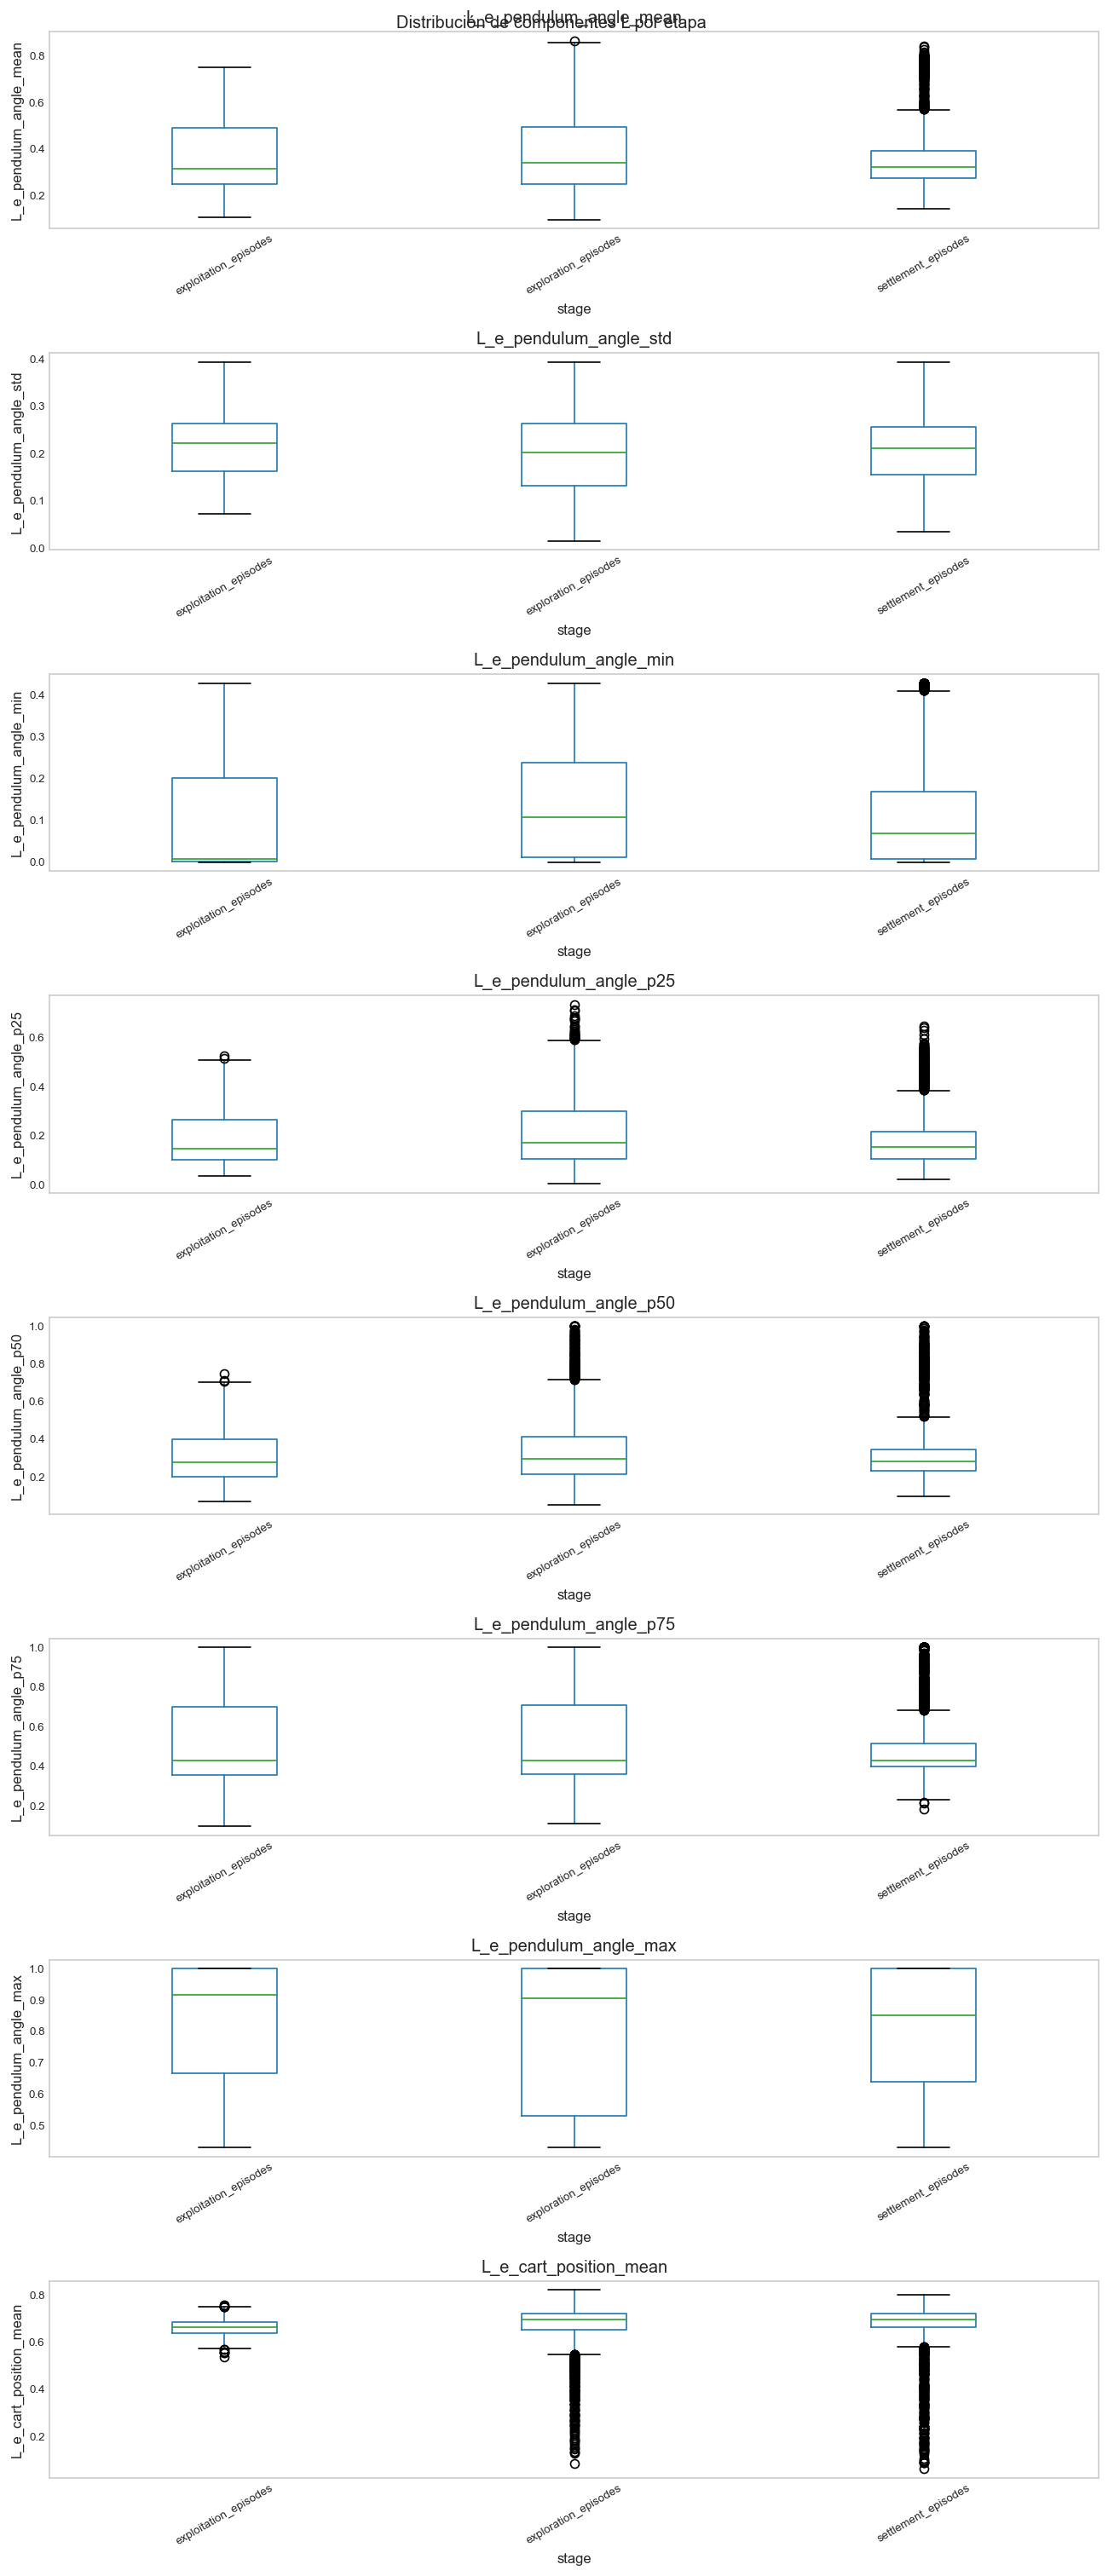

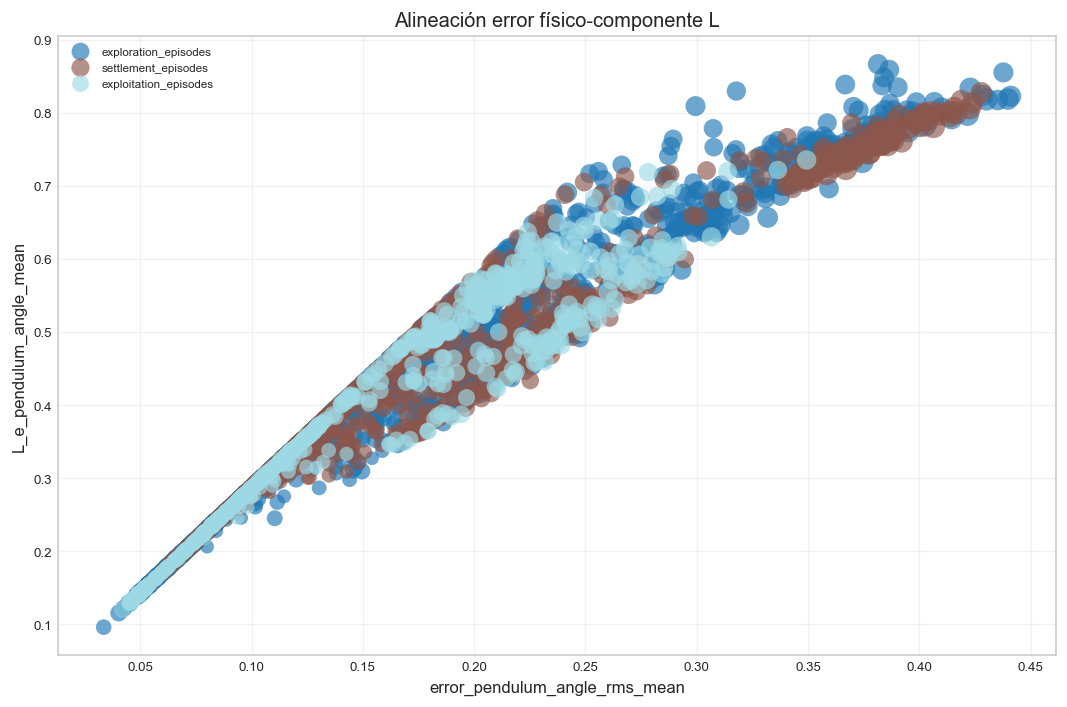

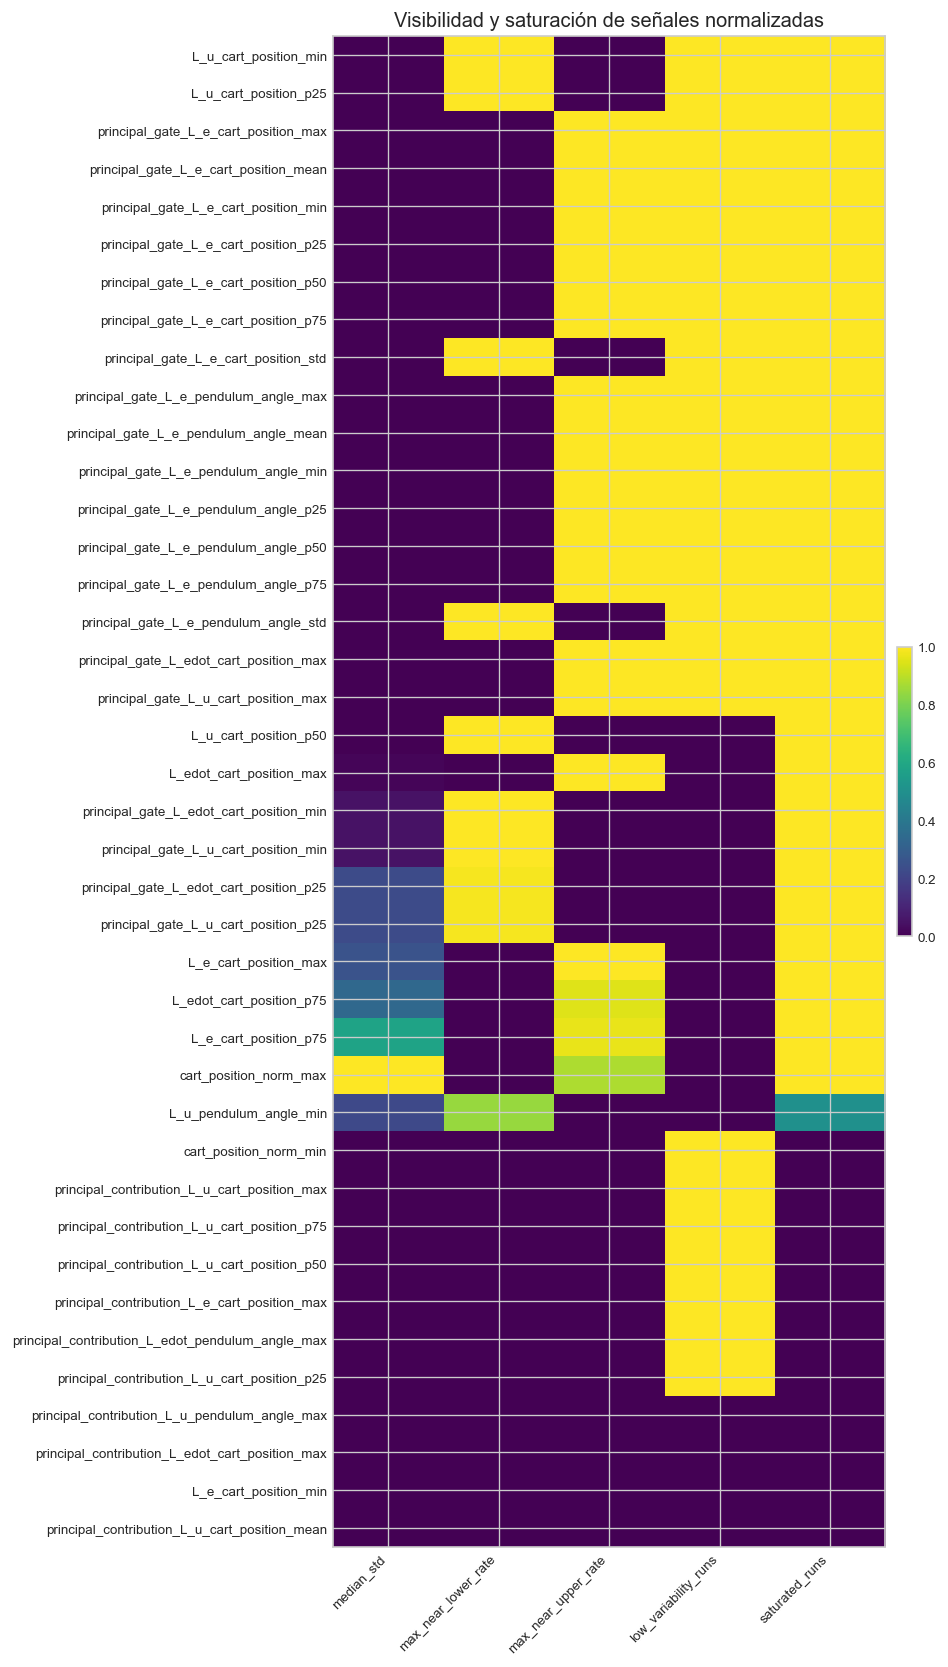

In [19]:
# 1. Graficar distribución de componentes L_*
# 2. Alinear error físico y componente L asociado cuando exista
# 3. Visualizar candidatos de saturación

fig_l_boxplot = plot_stage_boxplot(
    analytic_df,
    L_COMPONENT_COLUMNS[:8],
    stage_col="stage",
    title="Distribución de componentes L por etapa",
)
register_figure("normalization_l_component_distribution", fig_l_boxplot, FIGURE_REGISTRY)
plt.show()

L_ALIGNMENT_COL = first_existing_column(analytic_df, L_COMPONENT_COLUMNS)
ERROR_ALIGNMENT_COL = first_existing_column(analytic_df, [PENDULUM_ERROR_COL, CART_ERROR_COL])

fig_error_l_alignment = plot_scatter_with_size(
    analytic_df,
    x_col=ERROR_ALIGNMENT_COL,
    y_col=L_ALIGNMENT_COL,
    color_col="stage",
    size_col=REWARD_GROUP_SOURCE,
    title="Alineación error físico-componente L",
)
register_figure("normalization_error_l_alignment", fig_error_l_alignment, FIGURE_REGISTRY)
plt.show()

visibility_heatmap = signal_visibility_report.set_index("signal")[["median_std", "max_near_lower_rate", "max_near_upper_rate", "low_variability_runs", "saturated_runs"]].head(40)
fig_visibility_heatmap = plot_simple_heatmap(
    visibility_heatmap,
    title="Visibilidad y saturación de señales normalizadas",
    normalize=True,
)
register_figure("normalization_visibility_heatmap", fig_visibility_heatmap, FIGURE_REGISTRY)
plt.show()


## 6. Auditoría de recompensa, compuertas y coordinación

**Propósito:** separar composición global de reward, compuertas, extras, coordinación y distribución interna.
**Pregunta analítica:** ¿la recompensa representa la conducta física que se desea inducir?
**Entradas:** `analytic_df`, señales `reward_*`, `principal_*`, `extra_*`, `coordination_*`, `L_*` y errores físicos.
**Decisiones locales:** componentes de recompensa, gates, contribuciones, créditos y métricas de alineación física.
**Salidas:** `reward_component_summary`, `gate_behavior_table`, `reward_composition_df`, `credit_assignment_table`, `reward_physics_alignment_matrix`, `reward_design_audit`.
**Lectura esperada:** verificar si la reward ve lo mismo que la física y si está educando al agente correcto.


In [20]:
# 1. Seleccionar componentes de recompensa, compuertas y coordinación
# 2. Construir resúmenes y auditorías de composición
# 3. Estimar alineación reward-física

REWARD_PATTERNS = [
    "principal_reward",
    "global_interval_reward",
    "total_reward",
    "reward_",
    "extra_",
    "coordination_",
    "goal_bonus",
    "accumulated_band_bonus_",
    "principal_contribution_",
    "principal_gate_",
]

REWARD_COLUMNS = select_columns_by_patterns(analytic_df.columns, REWARD_PATTERNS, require_numeric_df=analytic_df)
GATE_COLUMNS = select_columns_by_patterns(REWARD_COLUMNS, ["gate"])
CONTRIBUTION_COLUMNS = select_columns_by_patterns(REWARD_COLUMNS, ["principal_contribution_", "reward_", "extra_", "coordination_reward"])
CREDIT_COLUMNS = select_columns_by_patterns(REWARD_COLUMNS, ["credit_share", "credit_raw"])

reward_component_summary = summarize_by_run_stage(analytic_df, REWARD_COLUMNS[:40])
gate_behavior_table = audit_signal_ranges(analytic_df, GATE_COLUMNS, group_cols=("run_id",)) if GATE_COLUMNS else pd.DataFrame()
credit_assignment_table = summarize_by_run_stage(analytic_df, CREDIT_COLUMNS[:24]) if CREDIT_COLUMNS else pd.DataFrame()

reward_composition_cols = ["run_id", "episode_id", "stage", *CONTRIBUTION_COLUMNS[:30]]
reward_composition_df = analytic_df[[col for col in reward_composition_cols if col in analytic_df.columns]].copy()

reward_physics_alignment_matrix = correlation_table(
    analytic_df,
    x_cols=REWARD_COLUMNS[:30],
    y_cols=PHYSICAL_SELECTED_COLUMNS[:20],
    group_cols=["run_id"],
)

reward_design_audit = pd.DataFrame({
    "audit_dimension": [
        "gate_variability",
        "reward_physics_alignment",
        "component_dominance",
        "coordination_credit_visibility",
    ],
    "evidence_table": [
        "gate_behavior_table",
        "reward_physics_alignment_matrix",
        "reward_composition_df",
        "credit_assignment_table",
    ],
    "risk_if_flagged": [
        "compuertas constantes no modulan severidad",
        "reward sube mientras error físico empeora",
        "un componente domina la recompensa total",
        "crédito coordinativo no distingue lazos",
    ],
})

register_table("reward_component_summary", reward_component_summary, TABLE_REGISTRY)
register_table("gate_behavior_table", gate_behavior_table, TABLE_REGISTRY)
register_table("reward_composition_df", reward_composition_df, TABLE_REGISTRY)
register_table("credit_assignment_table", credit_assignment_table, TABLE_REGISTRY)
register_table("reward_physics_alignment_matrix", reward_physics_alignment_matrix, TABLE_REGISTRY)
register_table("reward_design_audit", reward_design_audit, TABLE_REGISTRY)

display(metric_catalog[metric_catalog["column"].isin(REWARD_COLUMNS)][["family", "base_metric", "statistic", "column"]].head(200))
display(gate_behavior_table.head(40) if not gate_behavior_table.empty else pd.DataFrame({"message": ["No se encontraron compuertas principal_gate_*"]}))
display(reward_physics_alignment_matrix.sort_values("correlation", key=lambda s: s.abs(), ascending=False).head(30))


,family,base_metric,statistic,column
462,otros,principal_contribution_L_e_cart_position,max,principal_contribution_L_e_cart_position_max
463,otros,principal_contribution_L_e_cart_position,mean,principal_contribution_L_e_cart_position_mean
464,otros,principal_contribution_L_e_cart_position,min,principal_contribution_L_e_cart_position_min
465,otros,principal_contribution_L_e_cart_position,p25,principal_contribution_L_e_cart_position_p25
466,otros,principal_contribution_L_e_cart_position,p50,principal_contribution_L_e_cart_position_p50
...,...,...,...,...
665,reward,reward_kp_cart_position,std,reward_kp_cart_position_std
666,reward,reward_kp_pendulum_angle,max,reward_kp_pendulum_angle_max
667,reward,reward_kp_pendulum_angle,mean,reward_kp_pendulum_angle_mean
668,reward,reward_kp_pendulum_angle,min,reward_kp_pendulum_angle_min


,run_id,signal,n,missing_rate,mean,std,min,p01,p50,p99,max,n_unique,expected_lower,expected_upper,near_lower_rate,near_upper_rate,low_variability_flag,bound_saturation_flag,high_missing_flag
0,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_mean,5000,0.0,1.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1,0.0,1.0,0.0000,1.0000,True,True,False
1,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_std,5000,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1,0.0,1.0,1.0000,0.0000,True,True,False
2,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_min,5000,0.0,1.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1,0.0,1.0,0.0000,1.0000,True,True,False
3,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_p25,5000,0.0,1.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1,0.0,1.0,0.0000,1.0000,True,True,False
4,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_p50,5000,0.0,1.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1,0.0,1.0,0.0000,1.0000,True,True,False
5,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_p75,5000,0.0,1.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1,0.0,1.0,0.0000,1.0000,True,True,False
6,20260512_1046_POI2,principal_gate_L_e_pendulum_angle_max,5000,0.0,1.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1,0.0,1.0,0.0000,1.0000,True,True,False
7,20260512_1046_POI2,principal_gate_L_e_cart_position_mean,5000,0.0,1.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1,0.0,1.0,0.0000,1.0000,True,True,False
8,20260512_1046_POI2,principal_gate_L_e_cart_position_std,5000,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1,0.0,1.0,1.0000,0.0000,True,True,False
9,20260512_1046_POI2,principal_gate_L_e_cart_position_min,5000,0.0,1.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1,0.0,1.0,0.0000,1.0000,True,True,False


,run_id,x,y,n_pairs,correlation,method
251,20260512_1046_POI2,principal_gate_L_edot_pendulum_angle_p25,error_pendulum_angle_p75,5000,-0.999675,spearman
551,20260514_0126,principal_gate_L_edot_pendulum_angle_p25,error_pendulum_angle_p75,5000,-0.999145,spearman
562,20260514_0126,principal_gate_L_edot_pendulum_angle_p50,error_pendulum_angle_p50,5000,-0.997662,spearman
262,20260512_1046_POI2,principal_gate_L_edot_pendulum_angle_p50,error_pendulum_angle_p50,5000,-0.997142,spearman
36,20260512_1046_POI2,principal_reward_min,final_pendulum_angle_raw,5000,-0.979789,spearman
594,20260514_0126,principal_gate_L_edot_cart_position_mean,error_cart_position_p75,5000,0.978248,spearman
10,20260512_1046_POI2,principal_reward_mean,error_pendulum_angle_rms_mean,5000,-0.971841,spearman
222,20260512_1046_POI2,principal_gate_L_edot_pendulum_angle_mean,error_pendulum_angle_p50,5000,-0.967938,spearman
246,20260512_1046_POI2,principal_gate_L_edot_pendulum_angle_min,final_pendulum_angle_raw,5000,-0.962345,spearman
250,20260512_1046_POI2,principal_gate_L_edot_pendulum_angle_p25,error_pendulum_angle_rms_mean,5000,-0.957564,spearman


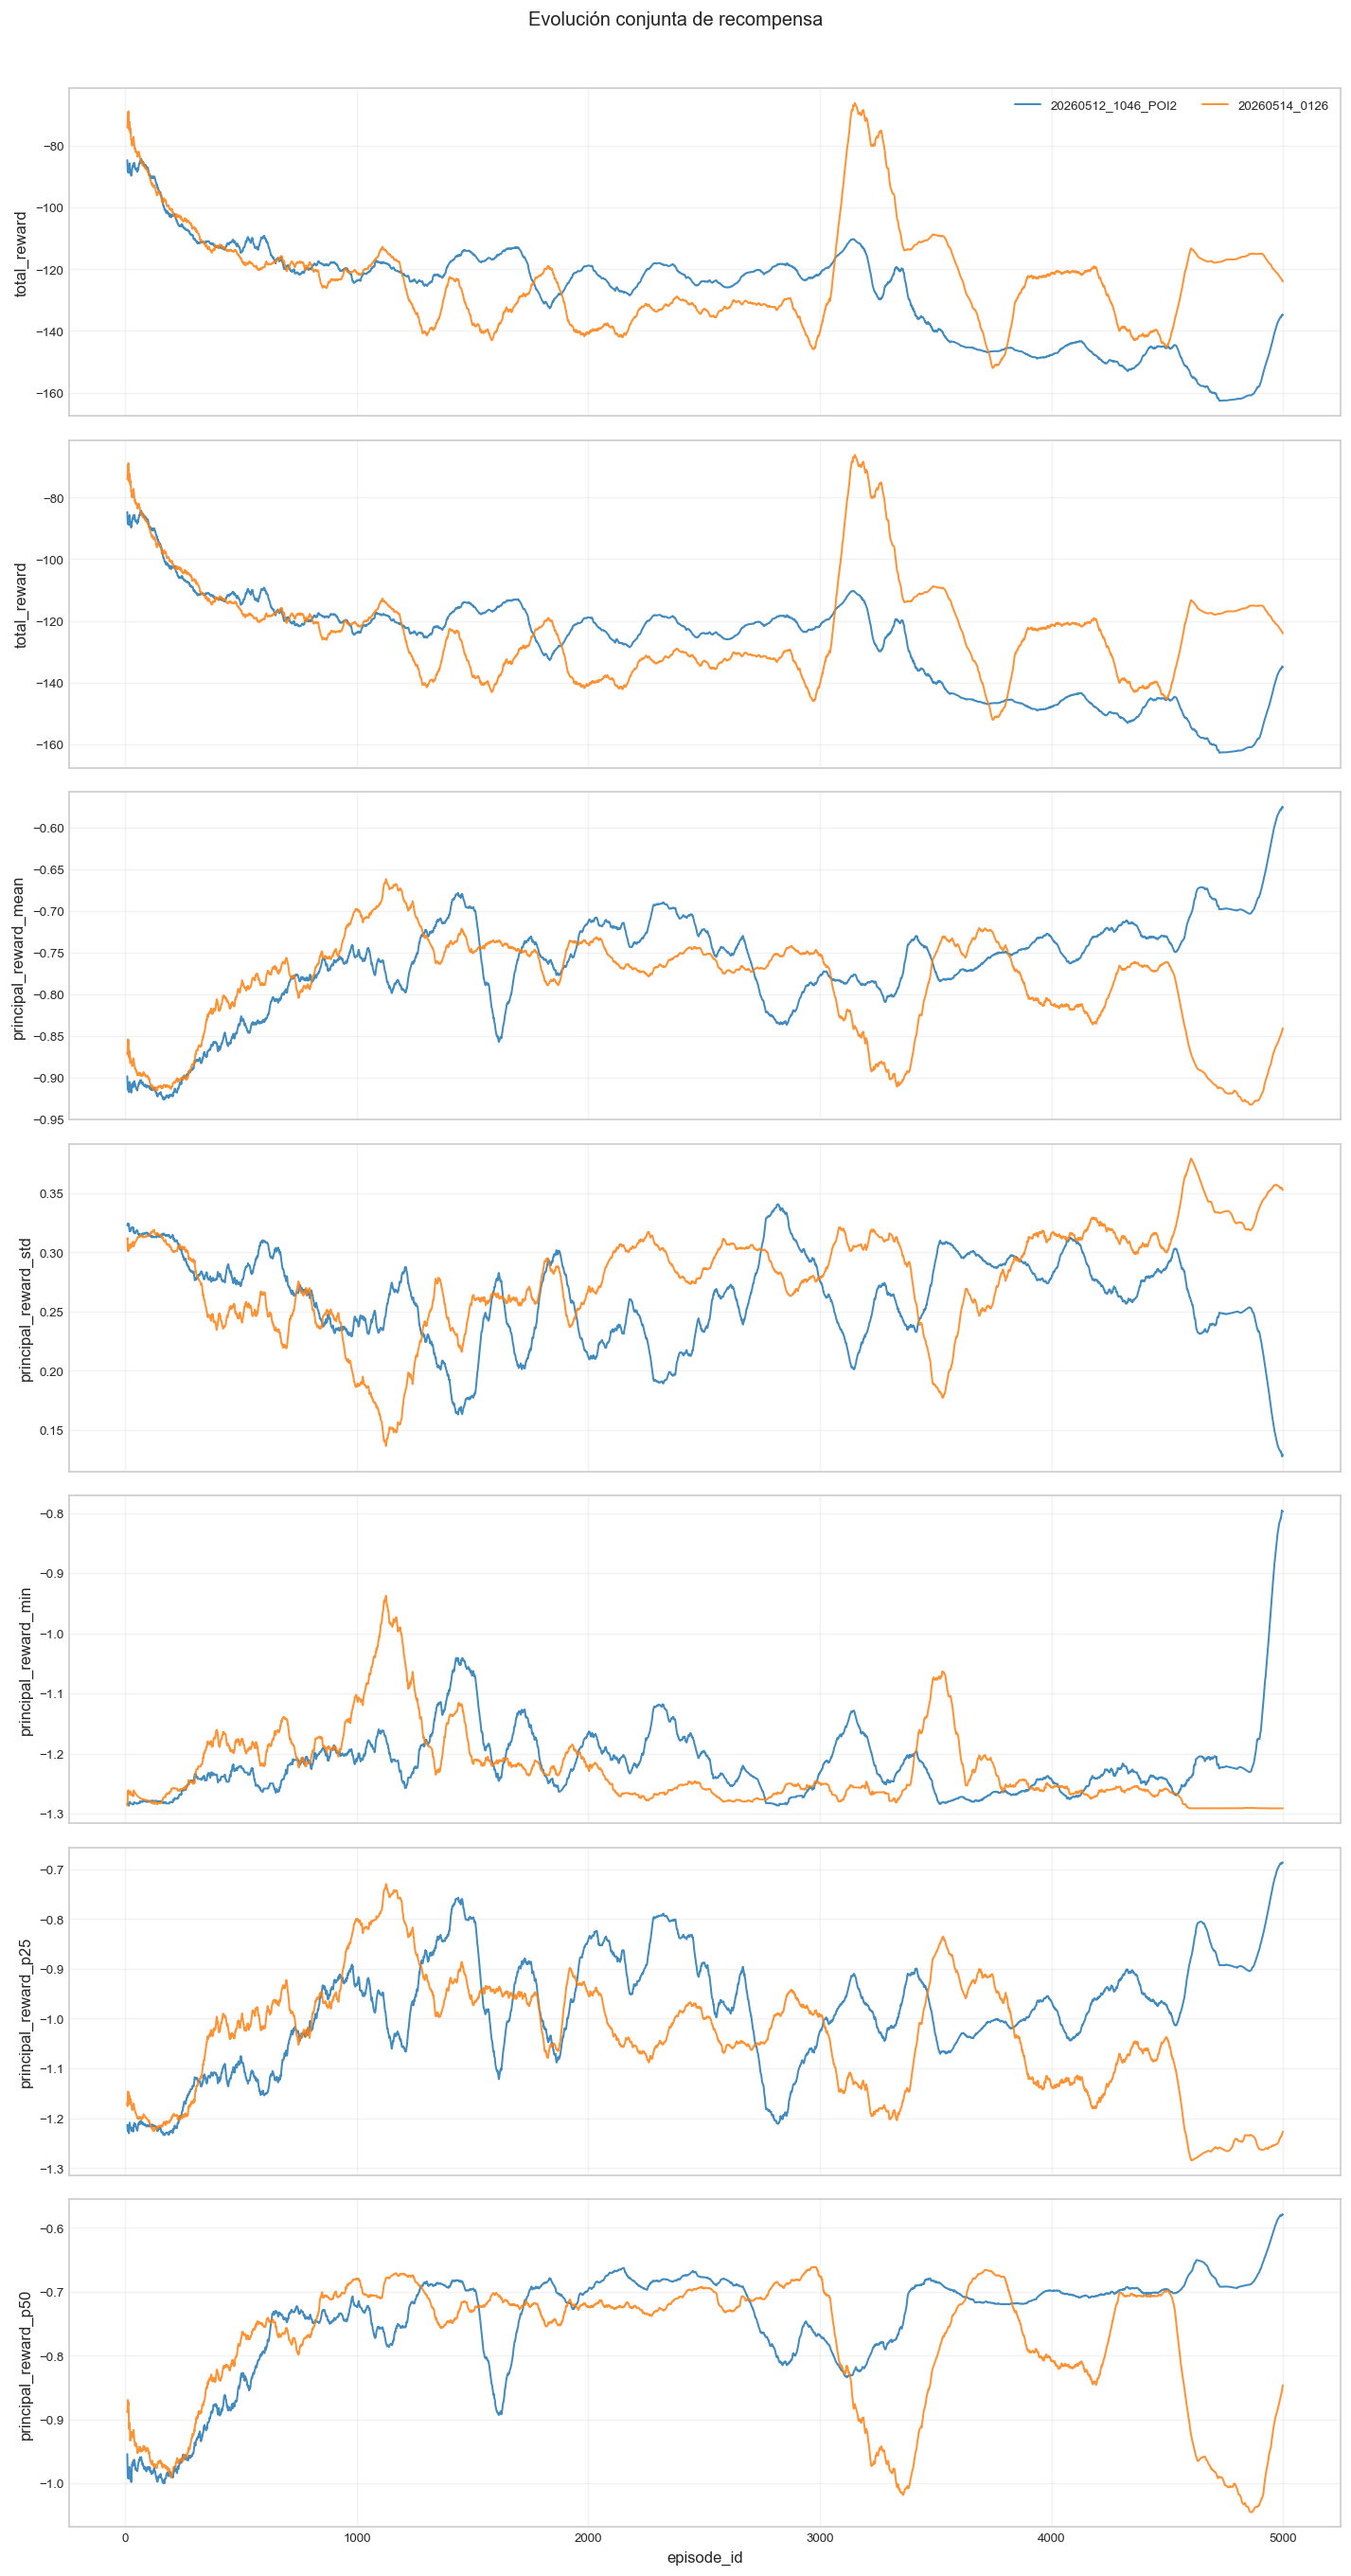

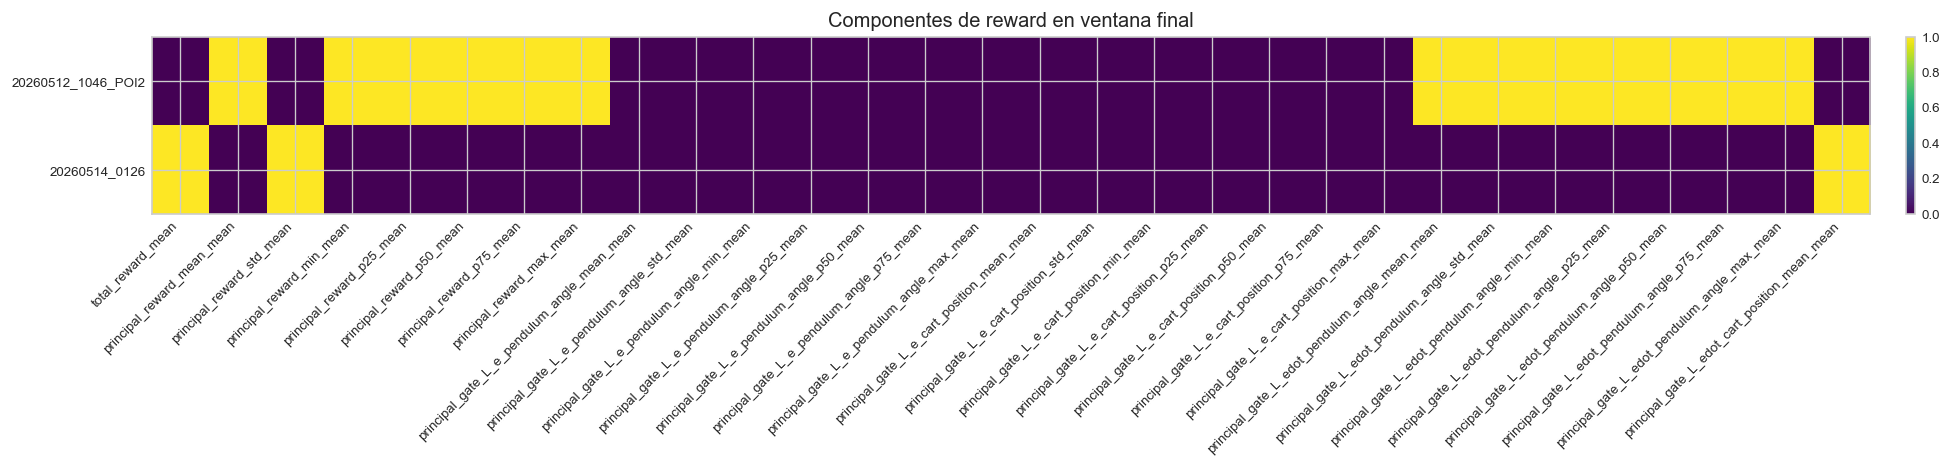

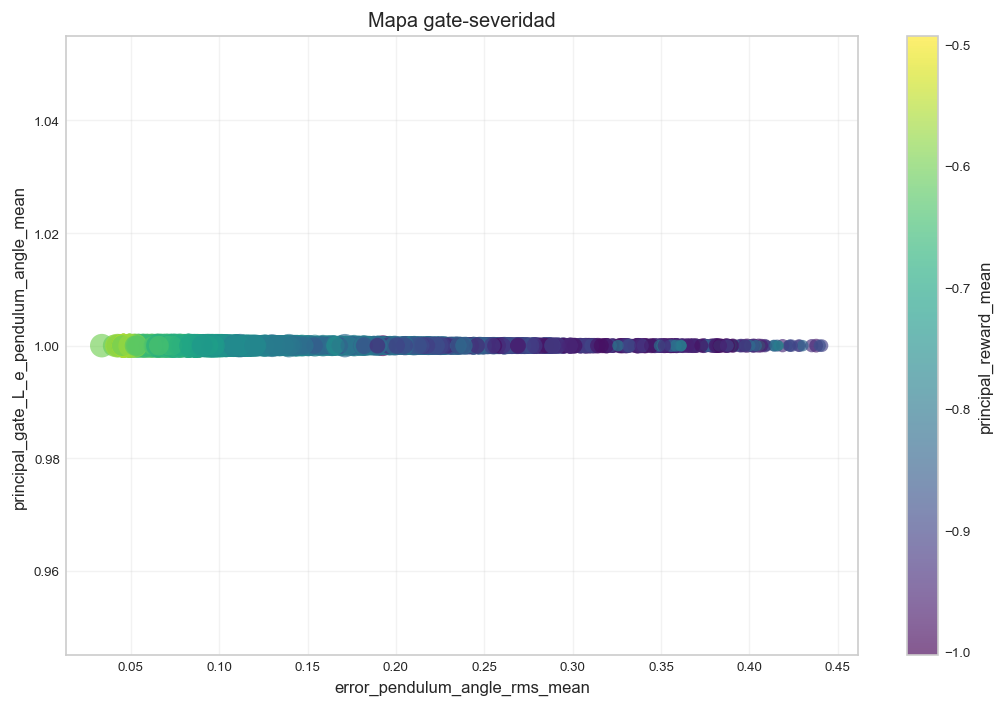

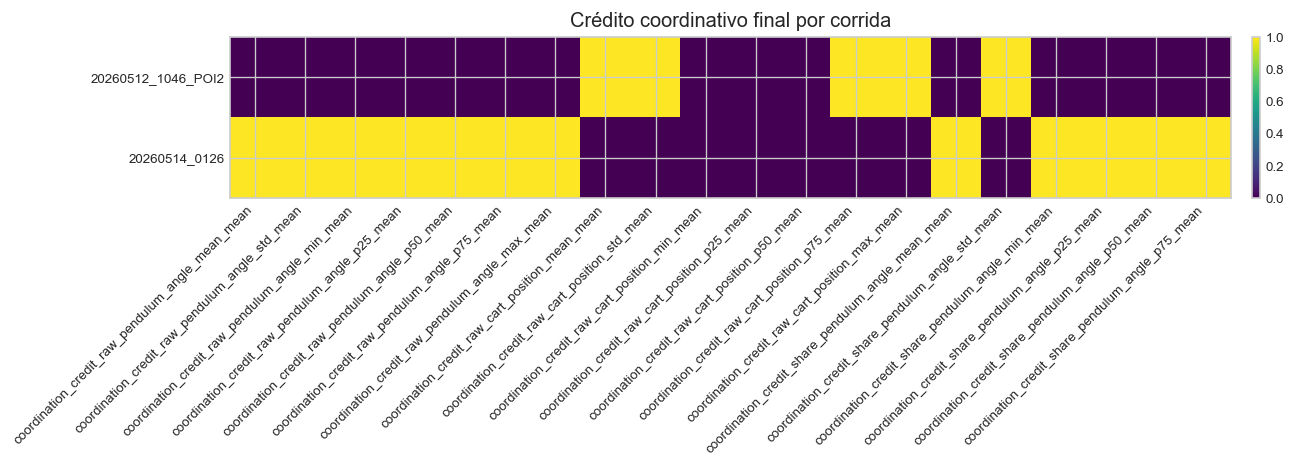

In [21]:
# 1. Evolución conjunta de recompensas
# 2. Heatmap de componentes finales
# 3. Gate-severidad y crédito coordinativo

reward_line_cols = numeric_existing_columns(analytic_df, ["principal_reward", "coordination_reward_total", "global_interval_reward", "total_reward"] + REWARD_COLUMNS[:6])
fig_reward_evolution = plot_lines_by_run(
    analytic_df,
    x_col="episode_id",
    y_cols=reward_line_cols[:8],
    smoothing_window=GLOBAL_SMOOTHING_WINDOW,
    title="Evolución conjunta de recompensa",
)
register_figure("reward_joint_evolution", fig_reward_evolution, FIGURE_REGISTRY)
plt.show()

reward_final_summary = summarize_final_window(analytic_df, REWARD_COLUMNS[:30], FINAL_WINDOW_EPISODES, FINAL_WINDOW_FRACTION)
reward_heatmap_cols = [col for col in reward_final_summary.columns if col.endswith("_mean")]
fig_reward_heatmap = plot_simple_heatmap(
    reward_final_summary.set_index("run_id")[reward_heatmap_cols[:30]] if reward_heatmap_cols else pd.DataFrame(),
    title="Componentes de reward en ventana final",
    normalize=True,
)
register_figure("reward_final_component_heatmap", fig_reward_heatmap, FIGURE_REGISTRY)
plt.show()

GATE_PRIMARY_COL = first_existing_column(analytic_df, GATE_COLUMNS)
CONTRIBUTION_PRIMARY_COL = first_existing_column(analytic_df, CONTRIBUTION_COLUMNS)

fig_gate_severity = plot_scatter_with_size(
    analytic_df,
    x_col=ERROR_ALIGNMENT_COL,
    y_col=GATE_PRIMARY_COL,
    color_col=CONTRIBUTION_PRIMARY_COL,
    size_col=DURATION_GROUP_SOURCE,
    title="Mapa gate-severidad",
)
register_figure("reward_gate_severity_map", fig_gate_severity, FIGURE_REGISTRY)
plt.show()

if CREDIT_COLUMNS:
    credit_final_summary = summarize_final_window(analytic_df, CREDIT_COLUMNS[:20], FINAL_WINDOW_EPISODES, FINAL_WINDOW_FRACTION)
    credit_heatmap_cols = [col for col in credit_final_summary.columns if col.endswith("_mean")]
    fig_credit_heatmap = plot_simple_heatmap(
        credit_final_summary.set_index("run_id")[credit_heatmap_cols] if credit_heatmap_cols else pd.DataFrame(),
        title="Crédito coordinativo final por corrida",
        normalize=True,
    )
    register_figure("reward_coordination_credit_heatmap", fig_credit_heatmap, FIGURE_REGISTRY)
    plt.show()


## 7. Señales de aprendizaje

**Propósito:** auditar si el agente aprendió, no aprendió o aprendió una conducta mal alineada.
**Pregunta analítica:** ¿el agente aprendió, no aprendió o aprendió una conducta equivocada?
**Entradas:** `analytic_df`, señales `epsilon`, `learning_rate`, `td_error_*`, `q_*`, `visits_*`, errores físicos y rewards por agente.
**Decisiones locales:** métricas de convergencia, estabilidad de Q-values, cobertura y relación aprendizaje-física.
**Salidas:** `learning_signal_summary`, `agent_convergence_table`, `td_error_physics_relation`, `q_value_stability_summary`, `coverage_warning_table`.
**Lectura esperada:** separar ausencia de aprendizaje de aprendizaje inducido por una reward mal formulada.


In [22]:
# 1. Seleccionar señales de aprendizaje disponibles
# 2. Comparar etapa inicial y final
# 3. Relacionar TD-error, Q-values, cobertura y física

LEARNING_PATTERNS = [
    "epsilon",
    "learning_rate",
    "td_error_",
    "q_value_",
    "q_mean_",
    "q_std_",
    "q_max_",
    "q_min_",
    "visits_total_",
    "visits_coverage_",
]

LEARNING_COLUMNS = select_columns_by_patterns(analytic_df.columns, LEARNING_PATTERNS, require_numeric_df=analytic_df)
TD_ERROR_COLUMNS = select_columns_by_patterns(LEARNING_COLUMNS, ["td_error_"])
Q_VALUE_COLUMNS = select_columns_by_patterns(LEARNING_COLUMNS, ["q_value_", "q_mean_", "q_std_", "q_max_", "q_min_"])
COVERAGE_COLUMNS = select_columns_by_patterns(LEARNING_COLUMNS, ["visits_coverage_", "visits_total_"])

learning_signal_summary = summarize_by_run_stage(analytic_df, LEARNING_COLUMNS[:40])
agent_convergence_table = compute_stage_delta(analytic_df, LEARNING_COLUMNS[:30], stage_order=list(DATA_GROUP["learning_groups"].keys()))
td_error_physics_relation = correlation_table(
    analytic_df,
    x_cols=TD_ERROR_COLUMNS[:20],
    y_cols=PHYSICAL_SELECTED_COLUMNS[:12],
    group_cols=["run_id"],
)
q_value_stability_summary = audit_signal_ranges(analytic_df, Q_VALUE_COLUMNS[:30], group_cols=("run_id",)) if Q_VALUE_COLUMNS else pd.DataFrame()
coverage_audit_table = audit_signal_ranges(analytic_df, COVERAGE_COLUMNS[:20], group_cols=("run_id",)) if COVERAGE_COLUMNS else pd.DataFrame()
coverage_warning_table = coverage_audit_table.query("low_variability_flag or high_missing_flag") if not coverage_audit_table.empty else pd.DataFrame()

register_table("learning_signal_summary", learning_signal_summary, TABLE_REGISTRY)
register_table("agent_convergence_table", agent_convergence_table, TABLE_REGISTRY)
register_table("td_error_physics_relation", td_error_physics_relation, TABLE_REGISTRY)
register_table("q_value_stability_summary", q_value_stability_summary, TABLE_REGISTRY)
register_table("coverage_warning_table", coverage_warning_table, TABLE_REGISTRY)

display(metric_catalog[metric_catalog["column"].isin(LEARNING_COLUMNS)][["family", "base_metric", "statistic", "column"]].head(160))
display(agent_convergence_table.head())
display(td_error_physics_relation.sort_values("correlation", key=lambda s: s.abs(), ascending=False).head(30))


,family,base_metric,statistic,column
0,aprendizaje,epsilon,value,epsilon
1,aprendizaje,learning,rate,learning_rate
2,aprendizaje,q_value_kd_cart_position,max,q_value_kd_cart_position_max
3,aprendizaje,q_value_kd_cart_position,mean,q_value_kd_cart_position_mean
4,aprendizaje,q_value_kd_cart_position,min,q_value_kd_cart_position_min
...,...,...,...,...
81,aprendizaje,td_error_kp_pendulum_angle,min,td_error_kp_pendulum_angle_min
82,aprendizaje,td_error_kp_pendulum_angle,p25,td_error_kp_pendulum_angle_p25
83,aprendizaje,td_error_kp_pendulum_angle,p50,td_error_kp_pendulum_angle_p50
84,aprendizaje,td_error_kp_pendulum_angle,p75,td_error_kp_pendulum_angle_p75


,run_id,baseline_stage,final_stage,epsilon_baseline,epsilon_final,epsilon_delta,learning_rate_baseline,learning_rate_final,learning_rate_delta,td_error_kp_pendulum_angle_mean_baseline,...,td_error_kp_cart_position_p25_delta,td_error_kp_cart_position_p50_baseline,td_error_kp_cart_position_p50_final,td_error_kp_cart_position_p50_delta,td_error_kp_cart_position_p75_baseline,td_error_kp_cart_position_p75_final,td_error_kp_cart_position_p75_delta,td_error_kp_cart_position_max_baseline,td_error_kp_cart_position_max_final,td_error_kp_cart_position_max_delta
0,20260512_1046_POI2,exploration_episodes,exploitation_episodes,0.390997,0.01,-0.380997,0.103599,0.01,-0.093599,-0.025316,...,0.068092,-0.155705,-0.136192,0.019512,0.117710,0.129416,0.011706,6.093959,6.634393,0.540434
1,20260514_0126,exploration_episodes,exploitation_episodes,0.390997,0.01,-0.380997,0.103599,0.01,-0.093599,-0.018219,...,0.001128,-0.126098,-0.167969,-0.041871,0.131085,0.124188,-0.006897,4.374081,4.591424,0.217343


,run_id,x,y,n_pairs,correlation,method
101,20260512_1046_POI2,td_error_ki_pendulum_angle_p25,error_pendulum_angle_p75,5000,-0.922405,spearman
31,20260512_1046_POI2,td_error_kp_pendulum_angle_p25,error_pendulum_angle_p75,5000,-0.919080,spearman
171,20260512_1046_POI2,td_error_kd_pendulum_angle_p25,error_pendulum_angle_p75,5000,-0.917742,spearman
301,20260514_0126,td_error_ki_pendulum_angle_p25,error_pendulum_angle_p75,5000,-0.908108,spearman
371,20260514_0126,td_error_kd_pendulum_angle_p25,error_pendulum_angle_p75,5000,-0.906772,spearman
231,20260514_0126,td_error_kp_pendulum_angle_p25,error_pendulum_angle_p75,5000,-0.901708,spearman
30,20260512_1046_POI2,td_error_kp_pendulum_angle_p25,error_pendulum_angle_rms_mean,5000,-0.895314,spearman
100,20260512_1046_POI2,td_error_ki_pendulum_angle_p25,error_pendulum_angle_rms_mean,5000,-0.894950,spearman
170,20260512_1046_POI2,td_error_kd_pendulum_angle_p25,error_pendulum_angle_rms_mean,5000,-0.890823,spearman
382,20260514_0126,td_error_kd_pendulum_angle_p50,error_pendulum_angle_p50,5000,-0.885200,spearman


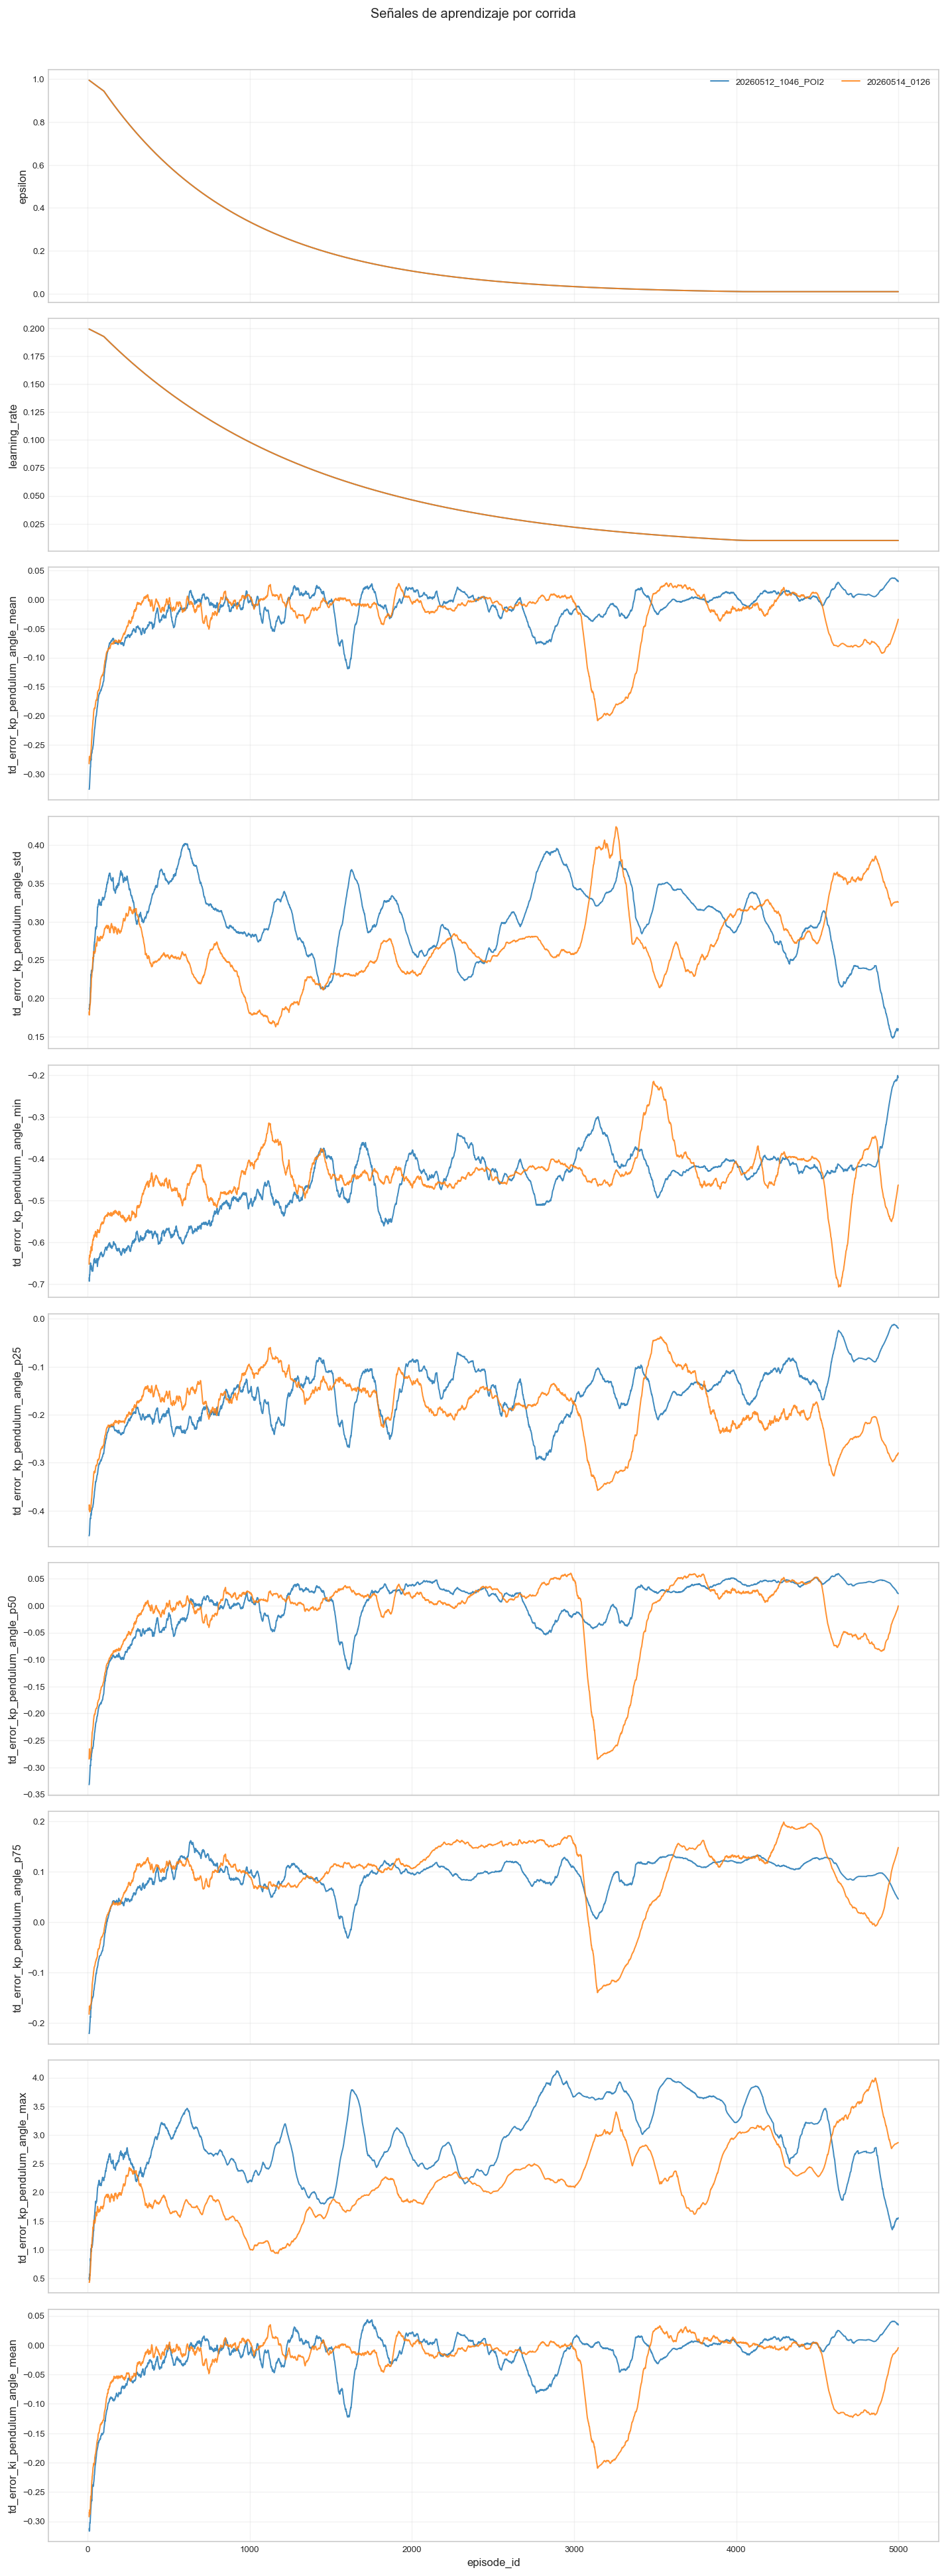

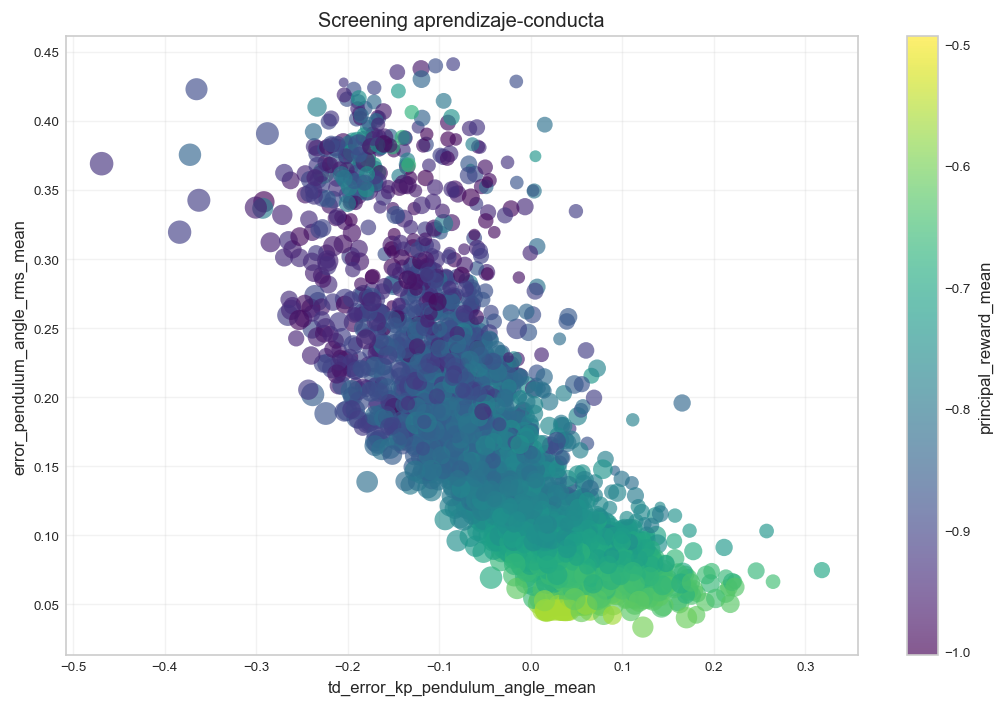

In [23]:
# 1. Evolución de epsilon, learning_rate y señales de aprendizaje
# 2. Screening aprendizaje-conducta
# 3. Cobertura y estabilidad

fig_learning_lines = plot_lines_by_run(
    analytic_df,
    x_col="episode_id",
    y_cols=LEARNING_COLUMNS[:10],
    smoothing_window=GLOBAL_SMOOTHING_WINDOW,
    title="Señales de aprendizaje por corrida",
)
register_figure("learning_signal_evolution", fig_learning_lines, FIGURE_REGISTRY)
plt.show()

TD_PRIMARY_COL = first_existing_column(analytic_df, TD_ERROR_COLUMNS)
Q_STD_PRIMARY_COL = first_existing_column(analytic_df, select_columns_by_patterns(Q_VALUE_COLUMNS, ["q_std_", "q_value_"]))
REWARD_AGENT_COL = first_existing_column(analytic_df, select_columns_by_patterns(REWARD_COLUMNS, ["reward_"]))

fig_learning_behavior = plot_scatter_with_size(
    analytic_df,
    x_col=TD_PRIMARY_COL,
    y_col=ERROR_ALIGNMENT_COL,
    color_col=REWARD_AGENT_COL,
    size_col=Q_STD_PRIMARY_COL,
    title="Screening aprendizaje-conducta",
)
register_figure("learning_behavior_screening", fig_learning_behavior, FIGURE_REGISTRY)
plt.show()

if not coverage_audit_table.empty:
    coverage_heatmap = coverage_audit_table.pivot_table(index="run_id", columns="signal", values="mean", aggfunc="mean")
    fig_coverage_heatmap = plot_simple_heatmap(
        coverage_heatmap,
        title="Cobertura media de visitas por agente",
        normalize=True,
    )
    register_figure("learning_coverage_heatmap", fig_coverage_heatmap, FIGURE_REGISTRY)
    plt.show()


## 8. Integración con metadata

**Propósito:** usar metadata como fuente de hipótesis de tuning, no como prueba causal.
**Pregunta analítica:** ¿qué parámetros cambiaron y qué evidencia observable sugieren?
**Entradas:** `run_metadata_df`, `metadata_variant_df`, `global_final_profile_df`, `reward`, `control`, `physical` y `learning` summaries.
**Decisiones locales:** familias de parámetros, métricas finales asociadas, mínimo de corridas para Spearman.
**Salidas:** `parameter_family_table`, `metadata_spearman_df`, `parameter_evidence_map`.
**Lectura esperada:** lenguaje exploratorio, sin ranking automático ni causalidad por correlación.


In [24]:
# 1. Clasificar parámetros variantes por familia
# 2. Asociar métricas finales observables
# 3. Calcular Spearman solo cuando hay soporte suficiente

METADATA_MIN_RUNS_FOR_SPEARMAN = 4
MAX_METADATA_PARAMETERS = 50

parameter_family_table = metadata_variant_df.copy()
parameter_family_table["parameter_family"] = parameter_family_table["parameter"].map(classify_metadata_parameter)

final_metric_sources = [global_final_profile_df]
if "reward_final_summary" in globals():
    final_metric_sources.append(reward_final_summary)
if "gain_stability_table" in globals():
    final_metric_sources.append(gain_stability_table)

run_metric_df = global_final_profile_df.copy()
for extra_metrics in final_metric_sources[1:]:
    extra_cols = [col for col in extra_metrics.columns if col == "run_id" or col.endswith("_mean")]
    run_metric_df = run_metric_df.merge(extra_metrics[extra_cols], on="run_id", how="left", suffixes=("", "_extra"))

variant_parameters = parameter_family_table.query("is_variant")["parameter"].head(MAX_METADATA_PARAMETERS).tolist()
candidate_metric_columns = [
    col for col in run_metric_df.columns
    if col != "run_id" and pd.api.types.is_numeric_dtype(run_metric_df[col])
]

metadata_spearman_df = build_metadata_spearman(
    run_metadata_df,
    run_metric_df,
    variant_parameters,
    candidate_metric_columns[:80],
    min_runs=METADATA_MIN_RUNS_FOR_SPEARMAN,
)
parameter_evidence_map = build_parameter_evidence_map(parameter_family_table, metadata_spearman_df, max_parameters=MAX_METADATA_PARAMETERS)

register_table("parameter_family_table", parameter_family_table, TABLE_REGISTRY)
register_table("metadata_spearman_df", metadata_spearman_df, TABLE_REGISTRY)
register_table("parameter_evidence_map", parameter_evidence_map, TABLE_REGISTRY)

display(parameter_family_table.head(80))
display(metadata_spearman_df.sort_values("spearman", key=lambda s: s.abs(), ascending=False).head(40) if not metadata_spearman_df.empty else pd.DataFrame({"message": ["No hay suficientes pares numéricos para Spearman."]}))
display(parameter_evidence_map.head(40))


,parameter,n_non_null,n_unique,is_variant,example_values,parameter_family
0,config_main.agent_base.params.discount_factor,2,2,True,0.95 | 0.925,agente
1,timestamp,2,2,True,20260512_1046 | 20260514_0126,simulacion
2,config_data_summary.data_summary.data_first_co...,2,1,False,episode_id,otros
3,config_data_summary.data_summary.data_first_co...,2,1,False,epsilon,otros
4,config_data_summary.data_summary.data_first_co...,2,1,False,final_ki_pendulum_angle,otros
...,...,...,...,...,...,...
75,config_data_summary.data_summary.data_stats.54,2,1,False,L_cart_position,otros
76,config_data_summary.data_summary.data_stats.55,2,1,False,principal_gate_L_e_pendulum_angle,otros
77,config_data_summary.data_summary.data_stats.56,2,1,False,principal_gate_L_e_cart_position,otros
78,config_data_summary.data_summary.data_stats.57,2,1,False,principal_gate_L_edot_pendulum_angle,otros


,message
0,No hay suficientes pares numéricos para Spearman.


,parameter,parameter_family,expected_signal,observed_metric,observed_direction,evidence_strength,interpretation,risk
0,config_main.agent_base.params.discount_factor,agente,hipótesis de tuning; no prueba causal,NaN,sin_evidencia_suficiente,insuficiente,"Hay variación en metadata, pero no suficientes...",No usar para ranking automático.
1,timestamp,simulacion,hipótesis de tuning; no prueba causal,NaN,sin_evidencia_suficiente,insuficiente,"Hay variación en metadata, pero no suficientes...",No usar para ranking automático.


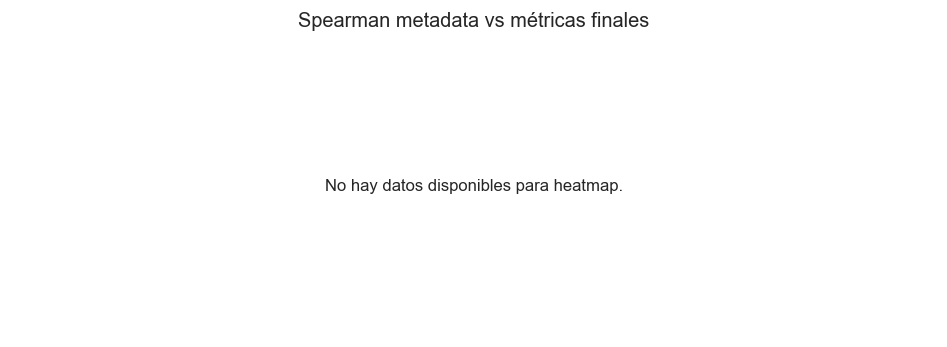

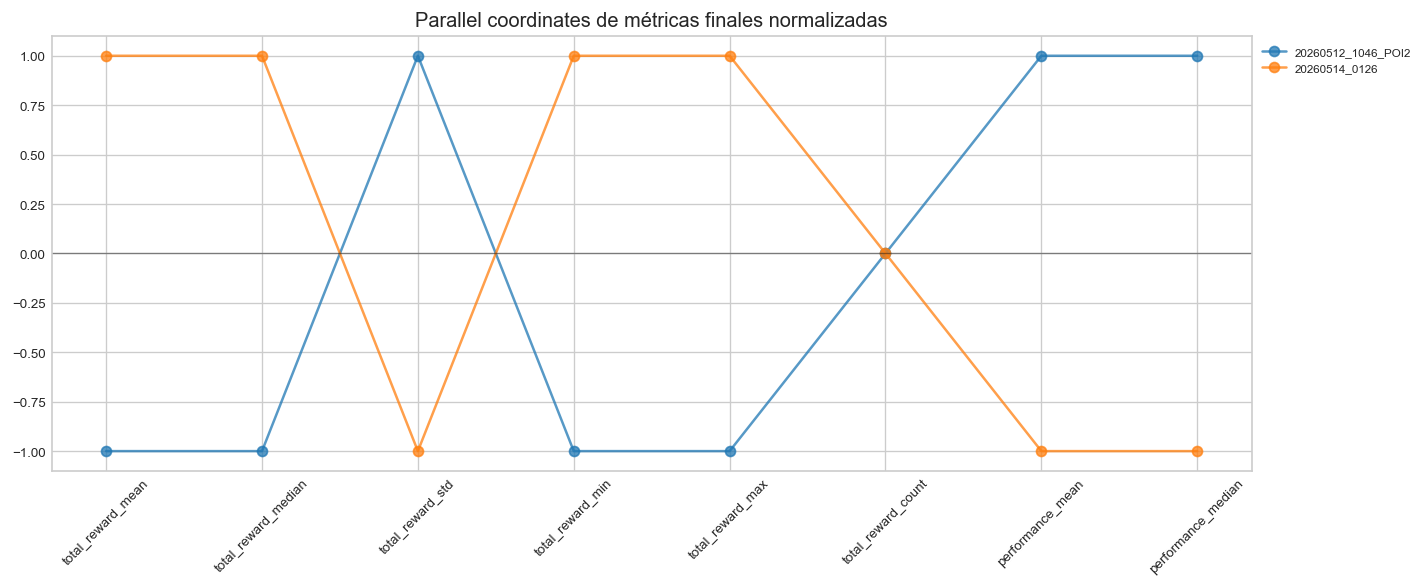

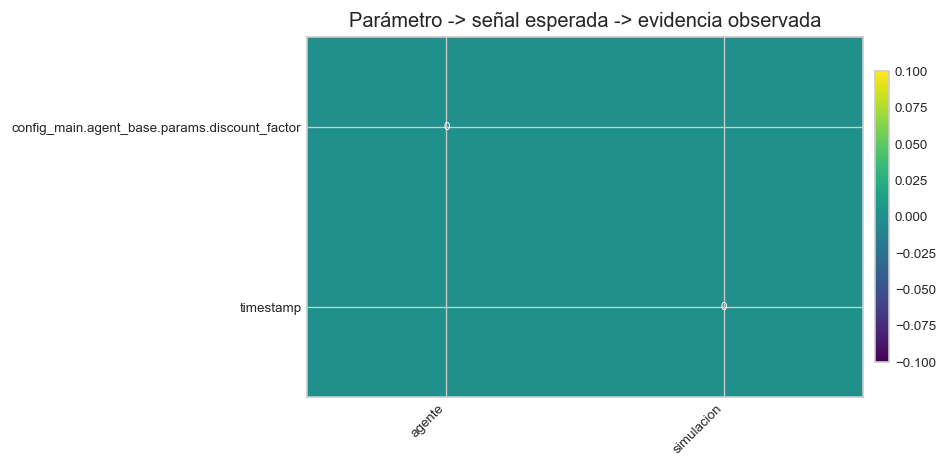

In [25]:
# 1. Heatmap Spearman metadata-métricas
# 2. Perfil paralelo de parámetros variantes y métricas finales
# 3. Matriz parámetro-señal-evidencia

if not metadata_spearman_df.empty:
    spearman_matrix = metadata_spearman_df.pivot_table(
        index="parameter",
        columns="observed_metric",
        values="spearman",
        aggfunc="mean",
    )
else:
    spearman_matrix = pd.DataFrame()

fig_metadata_spearman = plot_simple_heatmap(
    spearman_matrix.head(30).iloc[:, :30] if not spearman_matrix.empty else spearman_matrix,
    title="Spearman metadata vs métricas finales",
    normalize=False,
    cmap="coolwarm",
)
register_figure("metadata_spearman_heatmap", fig_metadata_spearman, FIGURE_REGISTRY)
plt.show()

parallel_cols = ["run_id"] + candidate_metric_columns[:8]
parallel_data = run_metric_df[parallel_cols].copy() if len(parallel_cols) > 1 else pd.DataFrame()
if not parallel_data.empty:
    numeric_cols = [col for col in parallel_data.columns if col != "run_id"]
    scaled = parallel_data.copy()
    for col in numeric_cols:
        scaled[col] = zscore(scaled[col])
    fig_parallel, ax = plt.subplots(figsize=(12, 5))
    for _, row in scaled.iterrows():
        ax.plot(numeric_cols, row[numeric_cols], marker="o", alpha=0.75, label=row["run_id"])
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title("Parallel coordinates de métricas finales normalizadas")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=7)
    fig_parallel.tight_layout()
else:
    fig_parallel = make_empty_figure("No hay métricas finales suficientes para parallel coordinates.", "Parallel coordinates")

register_figure("metadata_parallel_coordinates", fig_parallel, FIGURE_REGISTRY)
plt.show()

evidence_strength_codes = {
    "insuficiente": 0,
    "muy_debil_o_nula": 1,
    "debil_exploratoria": 2,
    "moderada_exploratoria": 3,
    "fuerte_exploratoria": 4,
}
evidence_matrix = parameter_evidence_map.assign(
    evidence_code=parameter_evidence_map["evidence_strength"].map(evidence_strength_codes)
).pivot_table(index="parameter", columns="parameter_family", values="evidence_code", aggfunc="max")

fig_parameter_evidence = plot_simple_heatmap(
    evidence_matrix.head(50) if not evidence_matrix.empty else pd.DataFrame(),
    title="Parámetro -> señal esperada -> evidencia observada",
    normalize=False,
    value_label=True,
)
register_figure("metadata_parameter_evidence_matrix", fig_parameter_evidence, FIGURE_REGISTRY)
plt.show()


## 9. Validación, robustez y sensibilidad

**Propósito:** probar si las conclusiones sobreviven a cambios razonables del análisis.
**Pregunta analítica:** ¿las conclusiones sobreviven a distintas ventanas finales, grupos y métricas alternativas?
**Entradas:** `analytic_df`, métricas globales, físicas, control y reward.
**Decisiones locales:** ventanas finales alternativas, métricas de ranking y criterio de fragilidad.
**Salidas:** `robustness_report`, `sensitivity_results_df`, `rank_stability_table`, `fragile_claims_register`, `validated_findings`.
**Lectura esperada:** las conclusiones fuertes deben sostenerse aquí; si no, bajan a exploratorias.


In [26]:
# 1. Definir escenarios de sensibilidad
# 2. Recalcular rankings por ventana final
# 3. Medir estabilidad de ranking

SENSITIVITY_WINDOWS = [
    {"final_window_episodes": 100, "window_fraction": 0.05},
    {"final_window_episodes": 250, "window_fraction": 0.05},
    {"final_window_episodes": 500, "window_fraction": 0.10},
    {"final_window_episodes": 1000, "window_fraction": 0.20},
]

RANK_METRICS = numeric_existing_columns(
    analytic_df,
    [REWARD_GROUP_SOURCE, DURATION_GROUP_SOURCE, "performance", ERROR_PRIMARY_COL, EFFORT_PRIMARY_COL],
)

sensitivity_rows = []
for scenario_id, scenario in enumerate(SENSITIVITY_WINDOWS, start=1):
    scenario_summary = summarize_final_window(
        analytic_df,
        RANK_METRICS,
        final_window_episodes=scenario["final_window_episodes"],
        window_fraction=scenario["window_fraction"],
    )
    for metric in RANK_METRICS:
        metric_mean = f"{metric}_mean"
        if metric_mean not in scenario_summary.columns:
            continue
        higher_is_better = not ("error" in metric.lower() or "saturation" in metric.lower() or "u_total" in metric.lower())
        ascending = not higher_is_better
        ranks = scenario_summary[["run_id", metric_mean]].copy()
        ranks["rank"] = ranks[metric_mean].rank(ascending=ascending, method="min")
        for row in ranks.itertuples(index=False):
            sensitivity_rows.append({
                "scenario_id": scenario_id,
                "final_window_episodes": scenario["final_window_episodes"],
                "window_fraction": scenario["window_fraction"],
                "metric": metric,
                "metric_mean": getattr(row, metric_mean),
                "run_id": row.run_id,
                "rank": row.rank,
                "higher_is_better": higher_is_better,
            })

sensitivity_results_df = pd.DataFrame(sensitivity_rows)
rank_stability_table = (
    sensitivity_results_df.groupby(["run_id", "metric"], dropna=False)
    .agg(
        mean_rank=("rank", "mean"),
        std_rank=("rank", "std"),
        best_rank=("rank", "min"),
        worst_rank=("rank", "max"),
        n_scenarios=("scenario_id", "nunique"),
    )
    .reset_index()
    if not sensitivity_results_df.empty else pd.DataFrame()
)

fragile_claims_register = rank_stability_table.query("std_rank >= 1.0 or (worst_rank - best_rank) >= 2").copy() if not rank_stability_table.empty else pd.DataFrame()
validated_findings = rank_stability_table.query("std_rank < 1.0 and best_rank <= 2").copy() if not rank_stability_table.empty else pd.DataFrame()

robustness_report = pd.DataFrame({
    "check": ["windows_tested", "metrics_tested", "fragile_claims", "validated_findings"],
    "value": [
        len(SENSITIVITY_WINDOWS),
        len(RANK_METRICS),
        len(fragile_claims_register),
        len(validated_findings),
    ],
    "interpretation": [
        "número de definiciones de ventana final probadas",
        "métricas incluidas en sensibilidad",
        "hallazgos que cambian demasiado de ranking",
        "hallazgos que mantienen ranking alto y estable",
    ],
})

register_table("sensitivity_results_df", sensitivity_results_df, TABLE_REGISTRY)
register_table("rank_stability_table", rank_stability_table, TABLE_REGISTRY)
register_table("fragile_claims_register", fragile_claims_register, TABLE_REGISTRY)
register_table("validated_findings", validated_findings, TABLE_REGISTRY)
register_table("robustness_report", robustness_report, TABLE_REGISTRY)

display(robustness_report)
display(rank_stability_table.sort_values(["metric", "mean_rank"]).head(60) if not rank_stability_table.empty else rank_stability_table)
display(fragile_claims_register.head(40))


,check,value,interpretation
0,windows_tested,4,número de definiciones de ventana final probadas
1,metrics_tested,5,métricas incluidas en sensibilidad
2,fragile_claims,0,hallazgos que cambian demasiado de ranking
3,validated_findings,10,hallazgos que mantienen ranking alto y estable


,run_id,metric,mean_rank,std_rank,best_rank,worst_rank,n_scenarios
5,20260514_0126,control_action_pendulum_angle_mean,1.0,0.0,1.0,1.0,4
0,20260512_1046_POI2,control_action_pendulum_angle_mean,2.0,0.0,2.0,2.0,4
1,20260512_1046_POI2,error_pendulum_angle_rms_mean,1.0,0.0,1.0,1.0,4
6,20260514_0126,error_pendulum_angle_rms_mean,2.0,0.0,2.0,2.0,4
2,20260512_1046_POI2,final_t_sec,1.0,0.0,1.0,1.0,4
7,20260514_0126,final_t_sec,2.0,0.0,2.0,2.0,4
3,20260512_1046_POI2,performance,1.0,0.0,1.0,1.0,4
8,20260514_0126,performance,2.0,0.0,2.0,2.0,4
9,20260514_0126,total_reward,1.0,0.0,1.0,1.0,4
4,20260512_1046_POI2,total_reward,2.0,0.0,2.0,2.0,4


,run_id,metric,mean_rank,std_rank,best_rank,worst_rank,n_scenarios


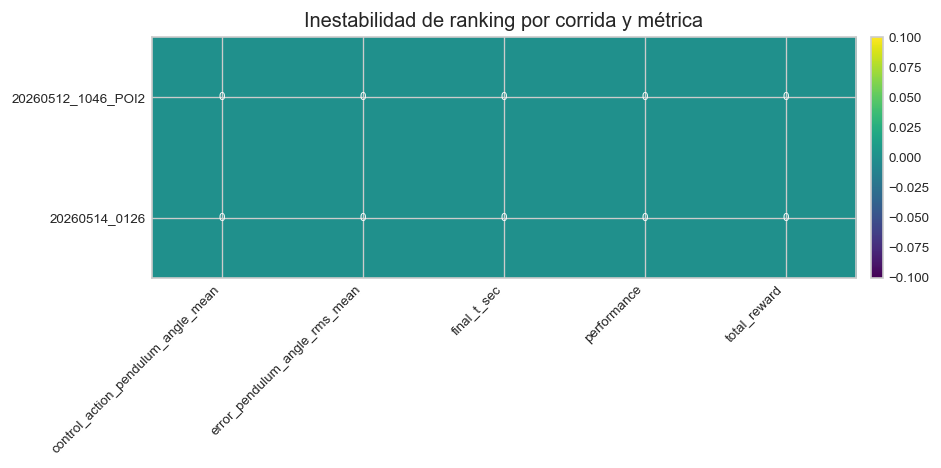

In [27]:
# 1. Visualizar estabilidad de ranking
# 2. Identificar métricas sensibles por corrida

if not rank_stability_table.empty:
    rank_matrix = rank_stability_table.pivot_table(index="run_id", columns="metric", values="std_rank", aggfunc="mean")
else:
    rank_matrix = pd.DataFrame()

fig_rank_stability = plot_simple_heatmap(
    rank_matrix,
    title="Inestabilidad de ranking por corrida y métrica",
    normalize=False,
    value_label=True,
)
register_figure("robustness_rank_stability", fig_rank_stability, FIGURE_REGISTRY)
plt.show()


## 10. Análisis de errores y episodios relevantes

**Propósito:** convertir errores, contradicciones y casos raros en evidencia sobre límites del sistema.
**Pregunta analítica:** ¿qué errores o contradicciones revelan los límites del sistema?
**Entradas:** `analytic_df`, métricas globales, físicas, control, reward y aprendizaje.
**Decisiones locales:** ventana de comparación local, criterios de contradicción y nivel sugerido de auditoría.
**Salidas:** `failure_mode_table`, `contradiction_register`, `episode_shortlist_for_deep_audit`, `case_study_candidates`, `error_interpretation_notes`.
**Lectura esperada:** los episodios seleccionados indican dónde conviene abrir interval/step data, no son ruido residual.


In [28]:
# 1. Construir deltas móviles de desempeño
# 2. Marcar contradicciones episodio a episodio
# 3. Priorizar casos para auditoría fina

ERROR_ANALYSIS_WINDOW = 100  # opciones: 50, 100, 250
ERROR_ANALYSIS_METRICS = numeric_existing_columns(
    analytic_df,
    [REWARD_GROUP_SOURCE, DURATION_GROUP_SOURCE, ERROR_PRIMARY_COL, EFFORT_PRIMARY_COL, TD_PRIMARY_COL],
)

episode_transition_df = build_transition_table(
    analytic_df,
    ERROR_ANALYSIS_METRICS,
    run_col="run_id",
    episode_col="episode_id",
    window=ERROR_ANALYSIS_WINDOW,
)

reward_delta = f"{REWARD_GROUP_SOURCE}_rolling_delta" if REWARD_GROUP_SOURCE is not None else None
duration_delta = f"{DURATION_GROUP_SOURCE}_rolling_delta" if DURATION_GROUP_SOURCE is not None else None
error_delta = f"{ERROR_PRIMARY_COL}_rolling_delta" if ERROR_PRIMARY_COL is not None else None
effort_delta = f"{EFFORT_PRIMARY_COL}_rolling_delta" if EFFORT_PRIMARY_COL is not None else None
td_delta = f"{TD_PRIMARY_COL}_rolling_delta" if TD_PRIMARY_COL is not None else None

contradiction_register = episode_transition_df[["run_id", "episode_id", "stage"]].copy()

if reward_delta in episode_transition_df.columns and duration_delta in episode_transition_df.columns:
    contradiction_register["duration_up_reward_down"] = ((episode_transition_df[duration_delta] > 0) & (episode_transition_df[reward_delta] < 0)).astype(int)
    contradiction_register["reward_up_duration_down"] = ((episode_transition_df[reward_delta] > 0) & (episode_transition_df[duration_delta] < 0)).astype(int)
else:
    contradiction_register["duration_up_reward_down"] = 0
    contradiction_register["reward_up_duration_down"] = 0

if reward_delta in episode_transition_df.columns and error_delta in episode_transition_df.columns:
    contradiction_register["reward_up_physics_worse"] = ((episode_transition_df[reward_delta] > 0) & (episode_transition_df[error_delta] > 0)).astype(int)
else:
    contradiction_register["reward_up_physics_worse"] = 0

if effort_delta in episode_transition_df.columns and error_delta in episode_transition_df.columns:
    contradiction_register["high_effort_low_physical_gain"] = ((episode_transition_df[effort_delta] > 0) & (episode_transition_df[error_delta] >= 0)).astype(int)
else:
    contradiction_register["high_effort_low_physical_gain"] = 0

if td_delta in episode_transition_df.columns and error_delta in episode_transition_df.columns:
    contradiction_register["learning_stable_behavior_poor"] = ((episode_transition_df[td_delta] <= 0) & (episode_transition_df[error_delta] > 0)).astype(int)
else:
    contradiction_register["learning_stable_behavior_poor"] = 0

contradiction_cols = [
    "duration_up_reward_down",
    "reward_up_duration_down",
    "reward_up_physics_worse",
    "high_effort_low_physical_gain",
    "learning_stable_behavior_poor",
]
contradiction_register["contradiction_severity"] = contradiction_register[contradiction_cols].sum(axis=1)

episode_shortlist_for_deep_audit = contradiction_register.query("contradiction_severity > 0").copy()
episode_shortlist_for_deep_audit["reason_for_selection"] = episode_shortlist_for_deep_audit[contradiction_cols].apply(
    lambda row: "; ".join([col for col, value in row.items() if value > 0]),
    axis=1,
)
episode_shortlist_for_deep_audit["evidence_metric"] = "contradiction_severity"
episode_shortlist_for_deep_audit["suggested_deep_audit_level"] = np.select(
    [
        episode_shortlist_for_deep_audit["contradiction_severity"] >= 3,
        episode_shortlist_for_deep_audit["contradiction_severity"] == 2,
    ],
    ["step", "interval"],
    default="summary",
)
episode_shortlist_for_deep_audit = episode_shortlist_for_deep_audit.sort_values(
    ["contradiction_severity", "run_id", "episode_id"],
    ascending=[False, True, True],
).head(80)

failure_mode_table = contradiction_register.groupby(["run_id", "stage"], dropna=False)[contradiction_cols + ["contradiction_severity"]].sum().reset_index()
case_study_candidates = episode_shortlist_for_deep_audit.head(20).copy()
error_interpretation_notes = pd.DataFrame({
    "criterion": contradiction_cols,
    "interpretation": [
        "sobrevive más pero con reward local deteriorada",
        "reward mejora mientras la supervivencia local cae",
        "reward mejora a pesar de empeorar error físico",
        "aumenta esfuerzo sin mejora física proporcional",
        "señal de aprendizaje parece estabilizarse pero conducta empeora",
    ],
    "audit_action": [
        "abrir interval data para revisar calidad de control",
        "revisar calibración de reward y bonus",
        "comparar componentes L y errores físicos",
        "revisar saturación, u_alloc y u_conflict",
        "revisar TD-error por agente y asignación de recompensa",
    ],
})

register_table("episode_transition_df", episode_transition_df, TABLE_REGISTRY)
register_table("failure_mode_table", failure_mode_table, TABLE_REGISTRY)
register_table("contradiction_register", contradiction_register, TABLE_REGISTRY)
register_table("episode_shortlist_for_deep_audit", episode_shortlist_for_deep_audit, TABLE_REGISTRY)
register_table("case_study_candidates", case_study_candidates, TABLE_REGISTRY)
register_table("error_interpretation_notes", error_interpretation_notes, TABLE_REGISTRY)

display(failure_mode_table.head(40))
display(episode_shortlist_for_deep_audit.head(30))
display(error_interpretation_notes)


,run_id,stage,duration_up_reward_down,reward_up_duration_down,reward_up_physics_worse,high_effort_low_physical_gain,learning_stable_behavior_poor,contradiction_severity
0,20260512_1046_POI2,exploitation_episodes,406,369,321,470,408,1974
1,20260512_1046_POI2,exploration_episodes,984,520,239,442,457,2642
2,20260512_1046_POI2,settlement_episodes,1020,589,409,807,818,3643
3,20260514_0126,exploitation_episodes,364,535,389,226,358,1872
4,20260514_0126,exploration_episodes,1099,477,342,383,519,2820
5,20260514_0126,settlement_episodes,870,805,656,743,827,3901


,run_id,episode_id,stage,duration_up_reward_down,reward_up_duration_down,reward_up_physics_worse,high_effort_low_physical_gain,learning_stable_behavior_poor,contradiction_severity,reason_for_selection,evidence_metric,suggested_deep_audit_level
597,20260512_1046_POI2,597,exploration_episodes,0,1,1,1,1,4,reward_up_duration_down; reward_up_physics_wor...,contradiction_severity,step
598,20260512_1046_POI2,598,exploration_episodes,0,1,1,1,1,4,reward_up_duration_down; reward_up_physics_wor...,contradiction_severity,step
599,20260512_1046_POI2,599,exploration_episodes,0,1,1,1,1,4,reward_up_duration_down; reward_up_physics_wor...,contradiction_severity,step
600,20260512_1046_POI2,600,exploration_episodes,0,1,1,1,1,4,reward_up_duration_down; reward_up_physics_wor...,contradiction_severity,step
601,20260512_1046_POI2,601,exploration_episodes,0,1,1,1,1,4,reward_up_duration_down; reward_up_physics_wor...,contradiction_severity,step
602,20260512_1046_POI2,602,exploration_episodes,0,1,1,1,1,4,reward_up_duration_down; reward_up_physics_wor...,contradiction_severity,step
603,20260512_1046_POI2,603,exploration_episodes,0,1,1,1,1,4,reward_up_duration_down; reward_up_physics_wor...,contradiction_severity,step
604,20260512_1046_POI2,604,exploration_episodes,0,1,1,1,1,4,reward_up_duration_down; reward_up_physics_wor...,contradiction_severity,step
605,20260512_1046_POI2,605,exploration_episodes,0,1,1,1,1,4,reward_up_duration_down; reward_up_physics_wor...,contradiction_severity,step
607,20260512_1046_POI2,607,exploration_episodes,0,1,1,1,1,4,reward_up_duration_down; reward_up_physics_wor...,contradiction_severity,step


,criterion,interpretation,audit_action
0,duration_up_reward_down,sobrevive más pero con reward local deteriorada,abrir interval data para revisar calidad de co...
1,reward_up_duration_down,reward mejora mientras la supervivencia local cae,revisar calibración de reward y bonus
2,reward_up_physics_worse,reward mejora a pesar de empeorar error físico,comparar componentes L y errores físicos
3,high_effort_low_physical_gain,aumenta esfuerzo sin mejora física proporcional,"revisar saturación, u_alloc y u_conflict"
4,learning_stable_behavior_poor,señal de aprendizaje parece estabilizarse pero...,revisar TD-error por agente y asignación de re...


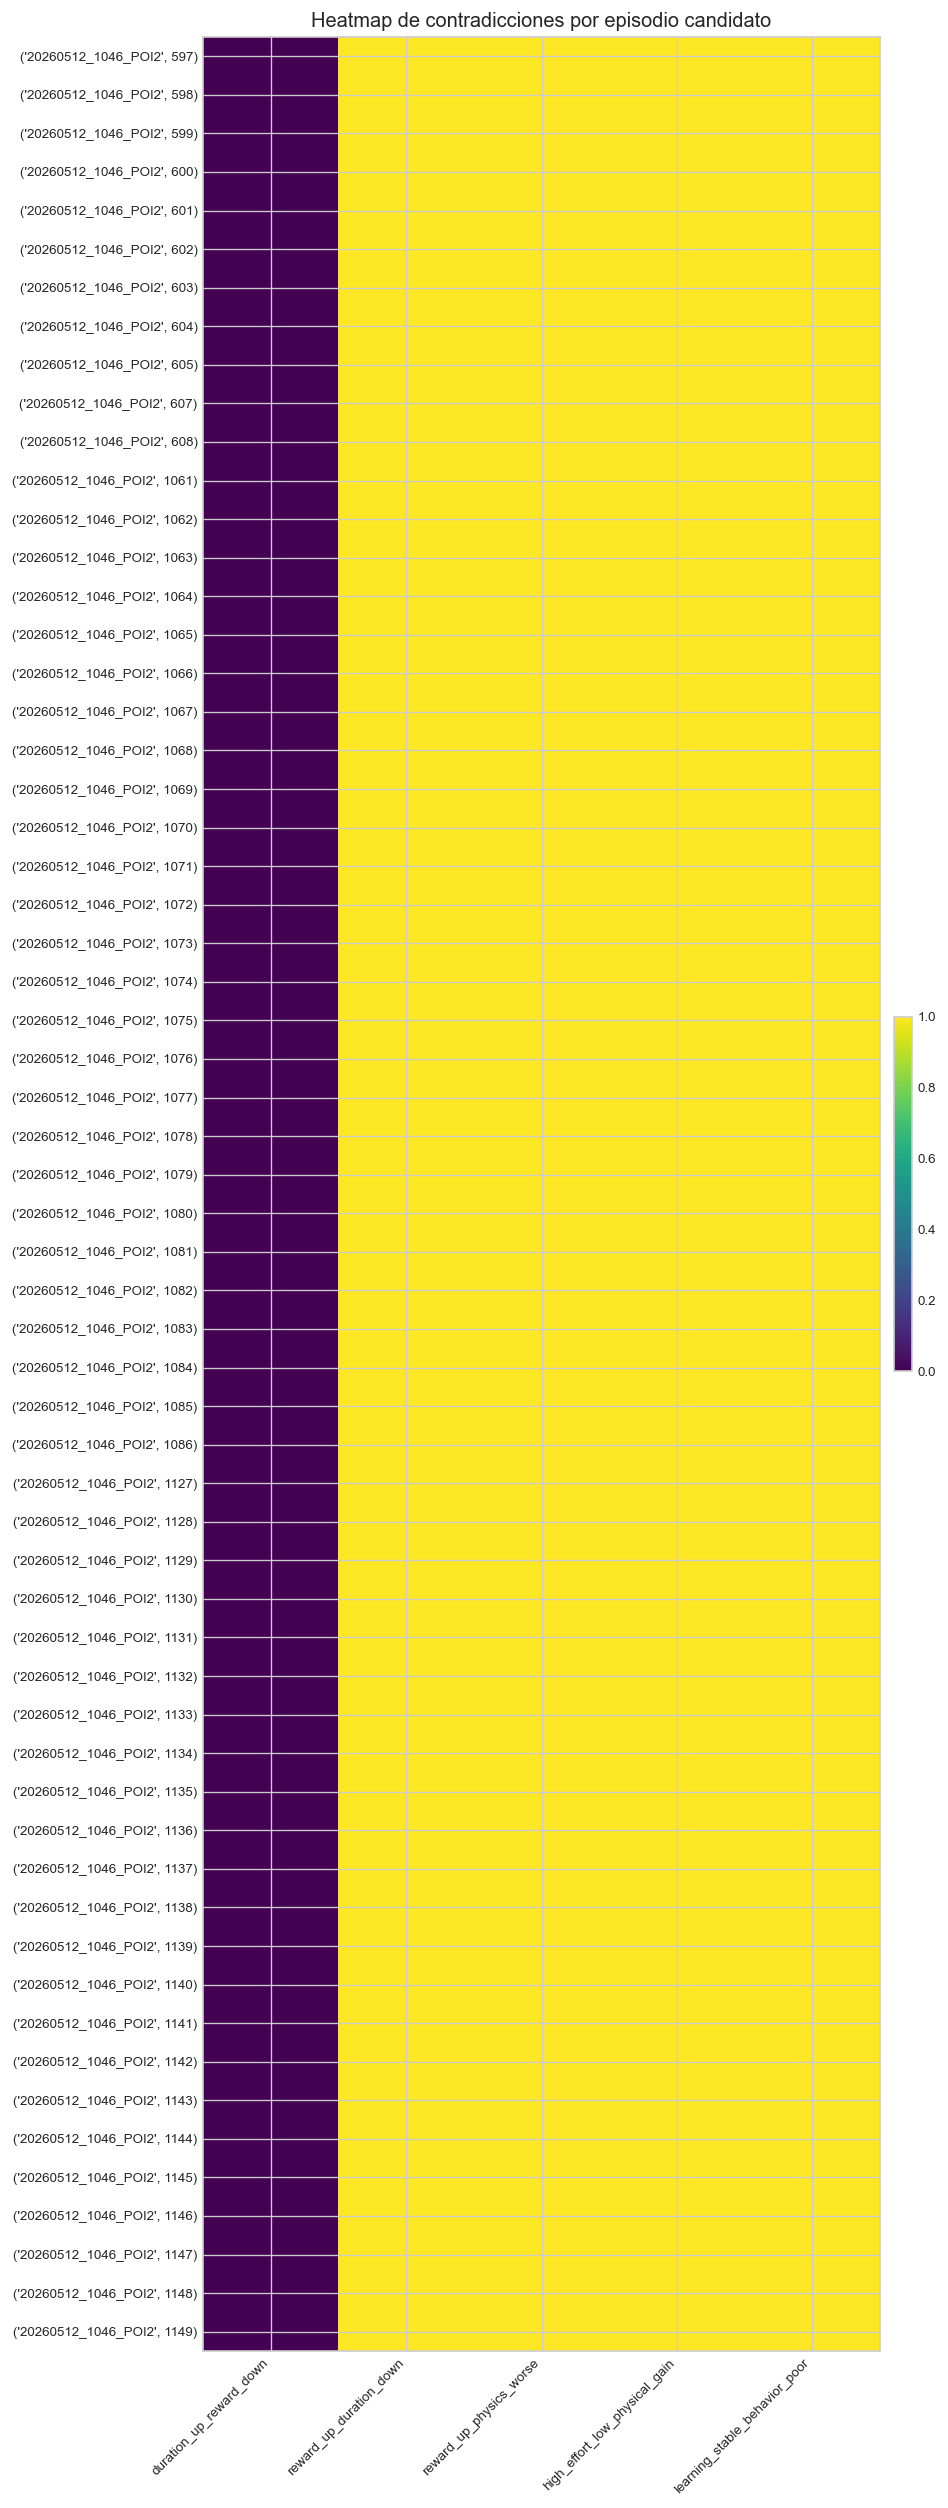

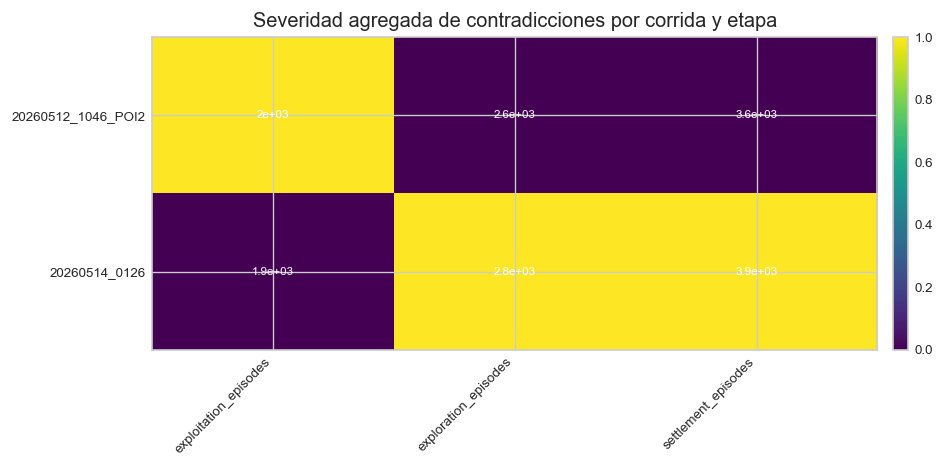

In [29]:
# 1. Heatmap de contradicciones por episodio candidato
# 2. Resumen de modos de fallo por corrida

contradiction_heatmap_data = episode_shortlist_for_deep_audit.set_index(["run_id", "episode_id"])[contradiction_cols].head(60) if not episode_shortlist_for_deep_audit.empty else pd.DataFrame()
fig_contradiction_heatmap = plot_simple_heatmap(
    contradiction_heatmap_data,
    title="Heatmap de contradicciones por episodio candidato",
    normalize=False,
    value_label=True,
)
register_figure("error_contradiction_heatmap", fig_contradiction_heatmap, FIGURE_REGISTRY)
plt.show()

failure_matrix = failure_mode_table.pivot_table(index="run_id", columns="stage", values="contradiction_severity", aggfunc="sum") if not failure_mode_table.empty else pd.DataFrame()
fig_failure_modes = plot_simple_heatmap(
    failure_matrix,
    title="Severidad agregada de contradicciones por corrida y etapa",
    normalize=True,
    value_label=True,
)
register_figure("error_failure_mode_summary", fig_failure_modes, FIGURE_REGISTRY)
plt.show()


## 11. Panel final de decisión

**Propósito:** consolidar el flujo completo en una decisión técnica argumentada.
**Pregunta analítica:** ¿qué configuración es más coherente y qué se debe modificar primero?
**Entradas:** perfiles finales, robustez, contradicciones, metadata y auditorías previas.
**Decisiones locales:** score de coherencia multi-métrica, nivel de confianza y riesgos declarados.
**Salidas:** `final_run_score_table`, `final_decision_table`.
**Lectura esperada:** la decisión integra evidencia positiva y contradictoria; no elige una corrida solo por mayor `total_reward`.


In [30]:
# 1. Construir score de coherencia multi-métrica
# 2. Integrar robustez y contradicciones
# 3. Redactar tabla final de decisión técnica

final_run_score_table = build_balanced_run_score(global_final_profile_df)

if not final_run_score_table.empty:
    best_run_id = final_run_score_table.iloc[0]["run_id"]
    best_score = final_run_score_table.iloc[0]["coherence_score"]
else:
    best_run_id = np.nan
    best_score = np.nan

contradiction_by_run = (
    contradiction_register.groupby("run_id")["contradiction_severity"].sum().reset_index(name="total_contradiction_severity")
    if not contradiction_register.empty else pd.DataFrame(columns=["run_id", "total_contradiction_severity"])
)
final_run_score_table = final_run_score_table.merge(contradiction_by_run, on="run_id", how="left") if not final_run_score_table.empty else final_run_score_table

n_runs = analytic_df["run_id"].nunique()
confidence_level = "media" if n_runs >= 6 and len(fragile_claims_register) <= len(validated_findings) else "baja_exploratoria"

primary_variant_parameter = (
    parameter_evidence_map.loc[parameter_evidence_map["evidence_strength"].ne("insuficiente"), "parameter"].head(1).iloc[0]
    if not parameter_evidence_map.empty and parameter_evidence_map["evidence_strength"].ne("insuficiente").any()
    else "requiere revisión manual de metadata variante"
)

final_decision_table = pd.DataFrame([
    {
        "finding": f"Corrida candidata con mayor coherencia integrada: {best_run_id}",
        "evidence": f"coherence_score={best_score:.3f}" if pd.notna(best_score) else "sin score calculable",
        "interpretation": "Candidata por balance entre reward, duración, fallos, física y esfuerzo; no por una sola métrica.",
        "candidate_parameter": primary_variant_parameter,
        "recommended_action": "replicar simulación controlando cambios simultáneos y abrir auditoría interval/step de episodios shortlist",
        "risk": "evidencia exploratoria si hay pocos runs, metadata simultánea o sensibilidad alta",
        "confidence_level": confidence_level,
        "requires_new_simulation": True,
    },
    {
        "finding": "Evidencia contradictoria relevante",
        "evidence": f"{len(episode_shortlist_for_deep_audit)} episodios candidatos para auditoría fina",
        "interpretation": "Las contradicciones indican límites de reward/control/aprendizaje que deben revisarse antes de afirmar superioridad.",
        "candidate_parameter": "reward, normalización, compuertas, saturación o aprendizaje según razón del episodio",
        "recommended_action": "priorizar episodios con suggested_deep_audit_level='step' y severidad alta",
        "risk": "una mejora agregada puede esconder errores físicos o esfuerzo excesivo",
        "confidence_level": "exploratoria",
        "requires_new_simulation": False,
    },
    {
        "finding": "Robustez de ranking",
        "evidence": f"{len(validated_findings)} hallazgos estables; {len(fragile_claims_register)} frágiles",
        "interpretation": "Los hallazgos frágiles no deben usarse como conclusiones fuertes.",
        "candidate_parameter": "definición de ventana final y métrica objetivo",
        "recommended_action": "reportar conclusiones fuertes solo si aparecen en validated_findings",
        "risk": "decisiones sensibles a ventana final o métrica alternativa",
        "confidence_level": confidence_level,
        "requires_new_simulation": False,
    },
])

register_table("final_run_score_table", final_run_score_table, TABLE_REGISTRY)
register_table("final_decision_table", final_decision_table, TABLE_REGISTRY)

display(final_run_score_table.head(20))
display(final_decision_table)


,run_id,total_reward_mean,total_reward_median,total_reward_std,total_reward_min,total_reward_max,total_reward_count,performance_mean,performance_median,performance_std,...,learning_rate_max,learning_rate_count,limit_rate,time_limit_rate,score_component__total_reward_mean,score_component__final_t_sec_mean,score_component__performance_mean,score_component__limit_rate,coherence_score,total_contradiction_severity
0,20260512_1046_POI2,-153.720006,-160.189263,11.769001,-170.857247,-127.833697,500,-32.054101,-33.442197,3.110134,...,0.01,500,0.632,0.368,-1.0,1.0,1.0,1.0,0.5,8259
1,20260514_0126,-117.581679,-117.260138,5.594382,-151.927024,-96.409081,500,-44.497104,-44.761231,2.309794,...,0.01,500,1.000,0.000,1.0,-1.0,-1.0,-1.0,-0.5,8593


,finding,evidence,interpretation,candidate_parameter,recommended_action,risk,confidence_level,requires_new_simulation
0,Corrida candidata con mayor coherencia integra...,coherence_score=0.500,"Candidata por balance entre reward, duración, ...",requiere revisión manual de metadata variante,replicar simulación controlando cambios simult...,"evidencia exploratoria si hay pocos runs, meta...",baja_exploratoria,True
1,Evidencia contradictoria relevante,80 episodios candidatos para auditoría fina,Las contradicciones indican límites de reward/...,"reward, normalización, compuertas, saturación ...",priorizar episodios con suggested_deep_audit_l...,una mejora agregada puede esconder errores fís...,exploratoria,False
2,Robustez de ranking,10 hallazgos estables; 0 frágiles,Los hallazgos frágiles no deben usarse como co...,definición de ventana final y métrica objetivo,reportar conclusiones fuertes solo si aparecen...,decisiones sensibles a ventana final o métrica...,baja_exploratoria,False


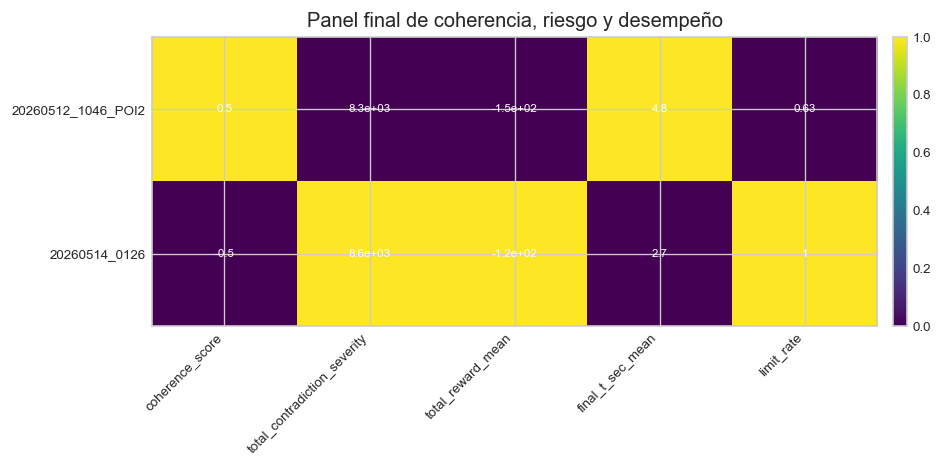

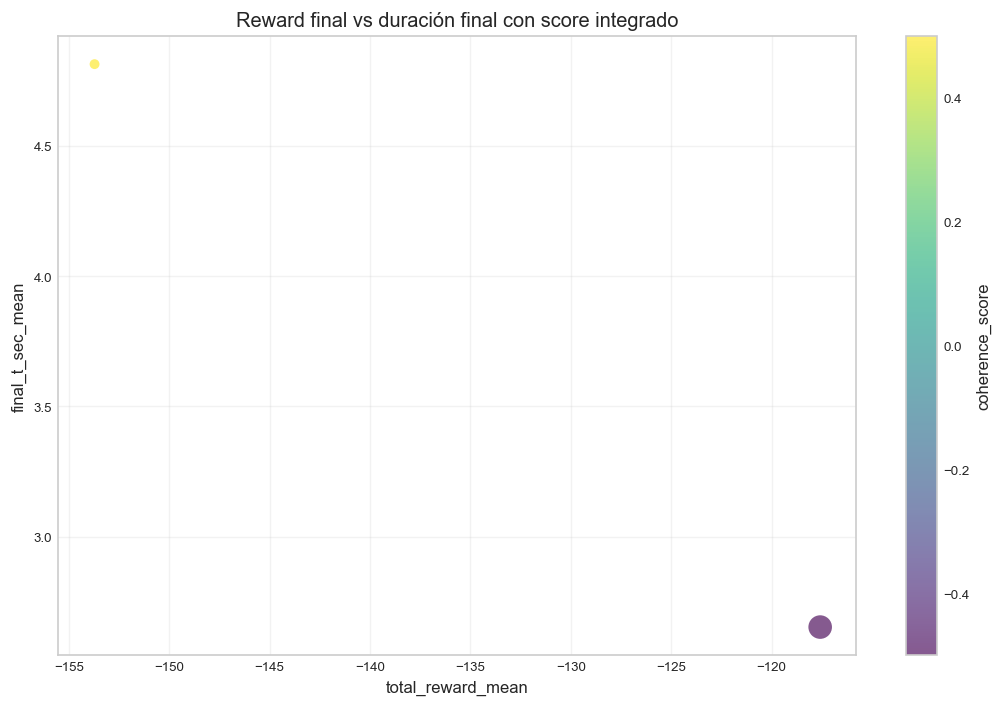

In [31]:
# 1. Panel global de decisión
# 2. Integrar evolución, física/control, reward y metadata

panel_cols = [col for col in ["coherence_score", "total_contradiction_severity", "total_reward_mean", "final_t_sec_mean", "limit_rate", "success_rate"] if col in final_run_score_table.columns]
fig_decision_score = plot_simple_heatmap(
    final_run_score_table.set_index("run_id")[panel_cols] if panel_cols else pd.DataFrame(),
    title="Panel final de coherencia, riesgo y desempeño",
    normalize=True,
    value_label=True,
)
register_figure("final_decision_score_panel", fig_decision_score, FIGURE_REGISTRY)
plt.show()

fig_decision_scatter = plot_scatter_with_size(
    final_run_score_table,
    x_col="total_reward_mean" if "total_reward_mean" in final_run_score_table.columns else None,
    y_col="final_t_sec_mean" if "final_t_sec_mean" in final_run_score_table.columns else None,
    color_col="coherence_score" if "coherence_score" in final_run_score_table.columns else None,
    size_col="total_contradiction_severity" if "total_contradiction_severity" in final_run_score_table.columns else None,
    title="Reward final vs duración final con score integrado",
)
register_figure("final_decision_reward_duration_scatter", fig_decision_scatter, FIGURE_REGISTRY)
plt.show()


## 12. Exportación y reproducibilidad

**Propósito:** guardar resultados limpios, tablas, figuras, manifiesto, supuestos y checklist de reproducción.
**Pregunta analítica:** ¿puede otro investigador ejecutar, auditar y reconstruir el análisis?
**Entradas:** `TABLE_REGISTRY`, `FIGURE_REGISTRY`, configuración local y objetos finales.
**Decisiones locales:** estructura de carpetas de exportación y contenido mínimo del manifiesto.
**Salidas:** `analysis_manifest`, `table_registry`, `figure_registry`, `exported_final_tables`, `exported_figures`, `assumptions_and_limitations`, `reproducibility_checklist`.
**Lectura esperada:** las exportaciones permiten revisar el flujo sin depender de explicaciones externas.


In [32]:
# 1. Construir manifiesto de análisis
# 2. Exportar tablas y figuras registradas
# 3. Guardar supuestos y checklist

tables_dir = OUTPUT_ANALYSIS_PATH / "tables"
figures_dir = OUTPUT_ANALYSIS_PATH / "figures"
reports_dir = OUTPUT_ANALYSIS_PATH / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

analysis_manifest = {
    "project_root": PROJECT_ROOT,
    "input_results_root": INPUT_RESULTS_ROOT,
    "output_analysis_path": OUTPUT_ANALYSIS_PATH,
    "summary_name": SUMMARY_NAME,
    "metadata_name": METADATA_NAME,
    "run_selection_mode": RUN_SELECTION_MODE,
    "n_run_selection": N_RUN_SELECTION,
    "explicit_run_ids": EXPLICIT_RUN_IDS,
    "selected_run_ids": selected_catalog_df["run_id"].tolist(),
    "reward_group_source": REWARD_GROUP_SOURCE,
    "duration_group_source": DURATION_GROUP_SOURCE,
    "final_window_episodes": FINAL_WINDOW_EPISODES,
    "final_window_fraction": FINAL_WINDOW_FRACTION,
    "n_tables_registered": len(TABLE_REGISTRY),
    "n_figures_registered": len(FIGURE_REGISTRY),
}

exported_final_tables = export_tables(TABLE_REGISTRY, tables_dir)
exported_figures = export_figures(FIGURE_REGISTRY, figures_dir)

assumptions_and_limitations = [
    "La metadata se interpreta como fuente de hipótesis de tuning, no como evidencia causal.",
    "Las asociaciones Spearman se calculan solo cuando hay suficientes corridas y variación numérica.",
    "La ventana final es sensible a su definición; las conclusiones fuertes deben pasar por la sección de robustez.",
    "Los gráficos desde summary.xlsx no reconstruyen trayectorias internas interval/step.",
    "Los episodios shortlist indican dónde abrir auditoría fina; no reemplazan esa auditoría.",
]

reproducibility_checklist = [
    "Ejecutar celdas en orden desde un entorno con pandas, numpy, matplotlib y openpyxl.",
    "Verificar que INPUT_RESULTS_ROOT contiene carpetas con summary.xlsx y metadata.json.",
    "Registrar RUN_SELECTION_MODE y lista de corridas seleccionadas.",
    "Guardar tablas, figuras y manifest.json junto a la versión del notebook.",
    "Reportar cambios manuales de grupos, ventanas o métricas locales.",
]

(reports_dir / "assumptions_and_limitations.md").write_text(
    "# Supuestos y limitaciones\n\n" + "\n".join([f"- {item}" for item in assumptions_and_limitations]),
    encoding="utf-8",
)
(reports_dir / "reproducibility_checklist.md").write_text(
    "# Checklist de reproducibilidad\n\n" + "\n".join([f"- {item}" for item in reproducibility_checklist]),
    encoding="utf-8",
)
(OUTPUT_ANALYSIS_PATH / "manifest.json").write_text(
    json.dumps(make_json_safe(analysis_manifest), indent=2, ensure_ascii=False),
    encoding="utf-8",
)

table_registry = pd.DataFrame({"name": list(TABLE_REGISTRY.keys())})
figure_registry = pd.DataFrame({"name": list(FIGURE_REGISTRY.keys())})

display(pd.DataFrame([analysis_manifest]))
display(exported_final_tables)
display(exported_figures)
display(pd.DataFrame({"assumptions_and_limitations": assumptions_and_limitations}))
display(pd.DataFrame({"reproducibility_checklist": reproducibility_checklist}))


,project_root,input_results_root,output_analysis_path,summary_name,metadata_name,run_selection_mode,n_run_selection,explicit_run_ids,selected_run_ids,reward_group_source,duration_group_source,final_window_episodes,final_window_fraction,n_tables_registered,n_figures_registered
0,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,summary.xlsx,metadata.json,last_n,2,"[20260511_1756_POI, 20260512_1046_POI2]","[20260512_1046_POI2, 20260514_0126]",total_reward,final_t_sec,500,0.1,61,32


,name,path
0,run_catalog_df,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
1,selected_catalog_df,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
2,runs_df,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
3,summary_df,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
4,run_metadata_df,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
...,...,...
56,episode_shortlist_for_deep_audit,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
57,case_study_candidates,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
58,error_interpretation_notes,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
59,final_run_score_table,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...


,name,path
0,global_training_evolution,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
1,global_termination_stage_rates,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
2,global_final_heatmap,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
3,global_reward_duration_screening,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
4,reward_duration_case_matrix,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
5,physical_stage_distribution,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
6,physical_final_error_heatmap,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
7,physical_domain_tradeoff,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
8,terminal_projection_final_pendulum_angle_raw_v...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
9,terminal_projection_final_cart_position_raw_vs...,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...


,assumptions_and_limitations
0,La metadata se interpreta como fuente de hipót...
1,Las asociaciones Spearman se calculan solo cua...
2,La ventana final es sensible a su definición; ...
3,Los gráficos desde summary.xlsx no reconstruye...
4,Los episodios shortlist indican dónde abrir au...


,reproducibility_checklist
0,Ejecutar celdas en orden desde un entorno con ...
1,Verificar que INPUT_RESULTS_ROOT contiene carp...
2,Registrar RUN_SELECTION_MODE y lista de corrid...
3,"Guardar tablas, figuras y manifest.json junto ..."
4,"Reportar cambios manuales de grupos, ventanas ..."


## Cierre metodológico

El notebook no declara una corrida como “mejor” por maximizar `total_reward`. La decisión final debe leerse como una afirmación técnica condicionada: una corrida es más coherente si aumenta duración, reduce fallos por límite, mejora errores físicos, mantiene esfuerzo razonable, presenta reward alineada con componentes físicos, conserva señales de aprendizaje interpretables y resiste sensibilidad de ventana/métrica. Si cualquiera de esas piezas falla, la conclusión se degrada a exploratoria y debe abrirse auditoría fina.
